# Setup Paths

In [1]:
import sys
import os

target_folder_name = "SymbolicDensityEstimation"
# 1. Get the current directory of the notebook.
current_dir = os.getcwd()

# # 2. Join it with '..' to get the parent directory.
parent_dir = os.path.join(current_dir, '..')

# # 3. change directory
current_folder_name = os.path.basename(current_dir)
is_match = current_folder_name == target_folder_name
if not is_match:
    os.chdir(parent_dir)

# # Get the current working directory as a string
current_directory = os.getcwd()

print("The current working directory is:")
print(current_directory)

The current working directory is:
/home/angel/WIP/Research/SymbolicDensityEstimation


# Imports

In [2]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
%config InlineBackend.figure_format = 'retina'  # better quality in notebook

import numpy as np
from sklearn.neighbors import KernelDensity
import scipy
from scipy.stats import gaussian_kde
import pandas as pd
from tqdm import tqdm
from config_management.data_config_dijet import DataConfig
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
from matplotlib import cm  # For colormap
from KDEpy import FFTKDE
from scipy.stats import multivariate_normal
from scipy.interpolate import RegularGridInterpolator
import sympy as sp
from sympy.parsing.sympy_parser import parse_expr
import gc
import dill
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault) 
plt.rcParams['font.family'] = 'Times New Roman'

# Data Exploration

In [3]:
file_path = './data/Dijets.csv'
df = pd.read_csv(file_path)
print(df.head())
columns = ['mjj', 'HT']
samples = df[columns].to_numpy()
# Extract m13^2 and m23^2 columns
x1 = df["mjj"]
x2 = df["HT"]

        # R         mjj          HT      eta1      eta2      phi1      phi2
0  3.806679  136.146906   83.247403  0.877576  3.027273 -2.840138  0.301454
1  4.415298  275.114546  111.625207  0.581774  3.684234  0.984612 -2.156981
2  3.251374   53.375240   49.012233 -1.133021 -0.295270 -0.018955  3.122637
3  4.691516  165.761831   56.334651  2.688435 -0.795919  0.926908 -2.214684
4  3.451928   67.476058   53.262190  0.491303  1.921758  2.827438 -0.314155


## Scatter Plot

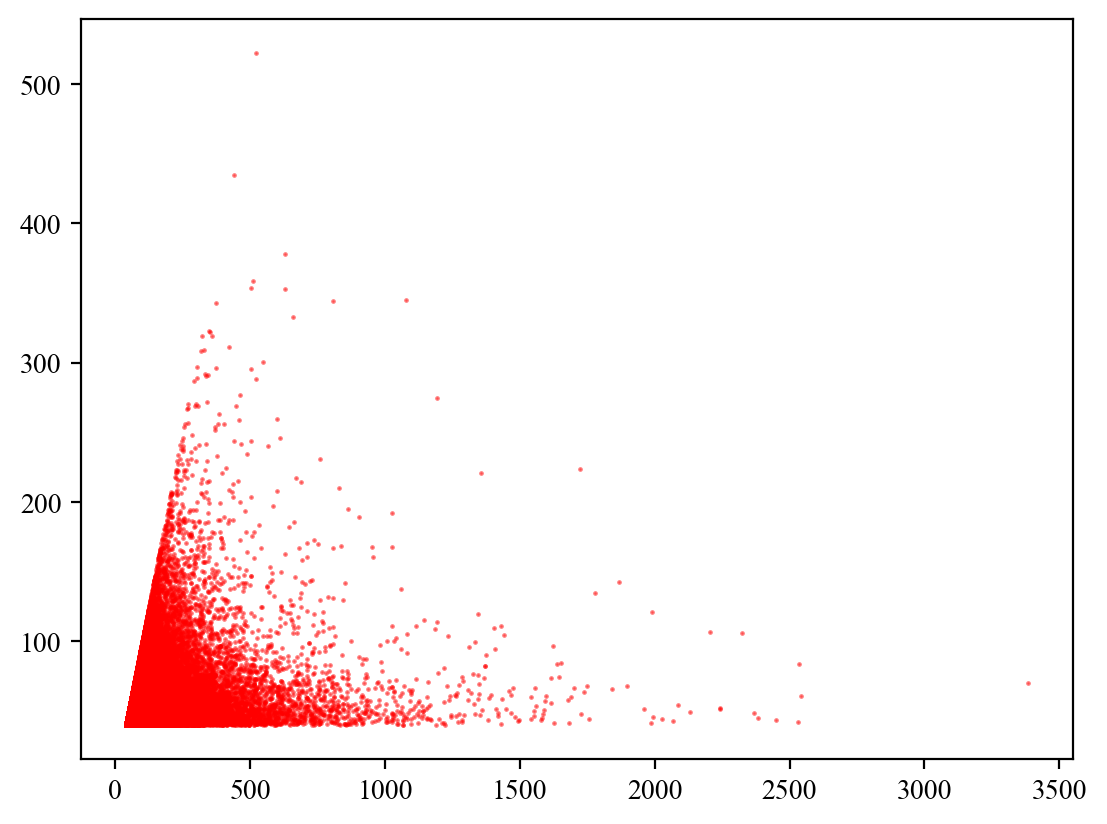

3147

In [4]:
plt.scatter(x1, x2, s=0.5, alpha=0.5, label='Data Points', color='red')
plt.show()
plt.close() 
gc.collect()

In [5]:
if DataConfig.slices is None:
    xmin, xmax = x1.min()-DataConfig.grid_tolerance, x1.max()+DataConfig.grid_tolerance
    ymin, ymax = x2.min()-DataConfig.grid_tolerance, x2.max()+DataConfig.grid_tolerance
    grids = np.mgrid[xmin:xmax:DataConfig.jxbins, ymin:ymax:DataConfig.jxbins]
else:
    slices = DataConfig.slices
    grids = np.mgrid[tuple(slices)]

grid_coordinates = np.vstack([grids[0].ravel(), grids[1].ravel()])
grid_coordinates = grid_coordinates.T

In [6]:
with open(f"models/dijet_kde_wrapped.pkl", "rb") as f:
    wrapper_model = dill.load(f)
kde_predicted_density = wrapper_model.evaluate(grid_coordinates).reshape(grids[0].shape)

In [7]:
# import torch
# import normflows as nf

# # Save original torch.load
# _original_torch_load = torch.load

# def cpu_only_load(*args, **kwargs):
#     kwargs["map_location"] = torch.device("cpu")
#     return _original_torch_load(*args, **kwargs)

# # Monkey-patch
# torch.load = cpu_only_load

# with open("models/dijet_neural.pkl", "rb") as f:
#     neural_model = dill.load(f)

# # Restore torch.load
# torch.load = _original_torch_load

# param = next(neural_model.parameters())
# grid_coordinates_tensor = torch.from_numpy(grid_coordinates).to(
#     dtype=param.dtype,
#     device=param.device
# )
# print(grid_coordinates_tensor.shape)
# batch_size = 20000
# neural_density_list = []
# neural_model.eval()
# with torch.no_grad():
#     for batch_id, batch in enumerate(torch.split(grid_coordinates_tensor, batch_size)):
#         neural_density_list.append(torch.exp(neural_model.log_prob(batch)))
#         print(f"Percentage: {batch_id / len(torch.split(grid_coordinates_tensor, batch_size)) * 100} %")
# neural_predicted_density_on_grid_coords = torch.cat(neural_density_list, dim=0).numpy()

# neural_predicted_density = neural_predicted_density_on_grid_coords.reshape(grids[0].shape)

In [8]:
# del neural_density_list
# del neural_model

# with open("./models/neural_predicted_density_on_grid_coords.dat", 'wb') as file:
#     dill.dump(neural_predicted_density_on_grid_coords, file)

# with open("./models/neural_predicted_density.dat", 'wb') as file:
#     dill.dump(neural_predicted_density, file)

In [9]:
# del neural_density_list
# del neural_model

In [10]:
with open("models/neural_predicted_density_on_grid_coords.dat", "rb") as f:
    neural_predicted_density_on_grid_coords = dill.load(f)

with open("models/neural_predicted_density.dat", "rb") as f:
    neural_predicted_density = dill.load(f)


In [11]:
neural_predicted_density_unmasked = neural_predicted_density_on_grid_coords
neural_predicted_density_unmasked = neural_predicted_density_unmasked.reshape(grids[0].shape)

In [12]:
mask = np.zeros(grid_coordinates.shape[0], dtype=bool)
reflection_lines = DataConfig.reflection_lines
for i in range(reflection_lines.shape[0]):
    m = reflection_lines[i, 0]  # slope
    b = reflection_lines[i, 1]  # intercept
    gt_or_lt = reflection_lines[i, 2]  # 1 for greater than (valid above), 0 for less than (valid below)
    mask = mask | ((grid_coordinates[:, 1] < m * grid_coordinates[:, 0] + b) if gt_or_lt == 1 else (grid_coordinates[:, 1] > m * grid_coordinates[:, 0] + b))
neural_predicted_density = neural_predicted_density_on_grid_coords
neural_predicted_density[mask] = 0
neural_predicted_density = neural_predicted_density.reshape(grids[0].shape)

## KDE Heatmap

In [13]:
xlims = (-0.1, 1.1)
ylims = (-0.1, 1.1)
color_level_min, color_level_max = 0.0, 0.1

In [14]:
# levels = np.linspace(color_level_min, 50, 100)  # for 30 intervals

# plt.figure(figsize=(8, 6))
# cf = plt.contourf(
#     grids[0],
#     grids[1],
#     neural_predicted_density,
#     levels=levels,
#     cmap="viridis",
#     extend="max"
# )
# cbar = plt.colorbar(cf, format="%.2f", ticks=np.linspace(0, 50, 11), extend="max")
# cbar.set_label("Density Estimate")
# plt.xlabel(r"$x_1$")
# plt.ylabel(r"$x_2$")
# plt.xlim([-0.1, 0.6])
# plt.ylim([-0.1, 0.6])
# plt.title("Heatmap of Dijet Neural Density Estimate")
# plt.show()
# # Explicitly close the figure object
# plt.close() 
# # Force the Python garbage collector to clean up memory
# gc.collect()

In [15]:
density_scale_factor = np.loadtxt("data/processed_data/dijet_neural_scale_factor.txt")
print(f"scale factor: {density_scale_factor}")
print(f"max neural density: {np.max(neural_predicted_density)}, min neural density: {np.min(neural_predicted_density)}")
neural_predicted_density_scaled = neural_predicted_density * density_scale_factor
print(f"max scaled neural density: {np.max(neural_predicted_density_scaled)}, min scaled neural density: {np.min(neural_predicted_density_scaled)}")
data_in_pipeline = np.loadtxt('data/processed_data/dijet_neural_joint_data_in_pipeline.csv', delimiter=',', skiprows=1)
print(f"max data in pipeline: {np.max(data_in_pipeline[:,2])}, min data in pipeline: {np.min(data_in_pipeline[:,2])}")


scale factor: 1.0
max neural density: 4315.9443359375, min neural density: 0.0
max scaled neural density: 4315.9443359375, min scaled neural density: 0.0
max data in pipeline: 1423.8203125, min data in pipeline: 1.3525809361425445e-09


# Results

In [16]:
pow2 = lambda x: x ** 2
pow3 = lambda x: x ** 3
pow4 = lambda x: x ** 4
pow5 = lambda x: x ** 5

In [102]:
file_path = "data/pareto_results/dijet_hybrid_hardpenalty_neural_results.py"
exec(open(file_path).read())

Original at complexity 1: 0.8801137496157823
function_ready: 0.8801137496157823
Processed: 0.880000000000000
LaTeX: 0.88

Original at complexity 2: exp(x2)
function_ready: np.exp(x2)
Processed: exp(x2)
LaTeX: e^{x_{2}}

Original at complexity 3: 2.525150154854746 / x1
function_ready: 2.525150154854746 / x1
Processed: 2.5/x1
LaTeX: \frac{2.5}{x_{1}}

Original at complexity 4: exp(0.9237334047853073) / x1
function_ready: np.exp(0.9237334047853073) / x1
Processed: 2.5/x1
LaTeX: \frac{2.5}{x_{1}}

Original at complexity 5: -7.598547703615941 - (-2.9225261550635713 / x1)
function_ready: -7.598547703615941 - (-2.9225261550635713 / x1)
Processed: -7.6 + 2.9/x1
LaTeX: -7.6 + \frac{2.9}{x_{1}}

Original at complexity 6: pow3(0.14924726836343927 / (x1 + 0.00836235811800397))
function_ready: pow3(0.14924726836343927 / (x1 + 0.00836235811800397))
Processed: pow3(0.15/(x1 + 0.0084))
LaTeX: \frac{0.0034}{\left(x_{1} + 0.0084\right)^{3}}

Original at complexity 8: exp((0.34363270518580363 - x2) / (0.

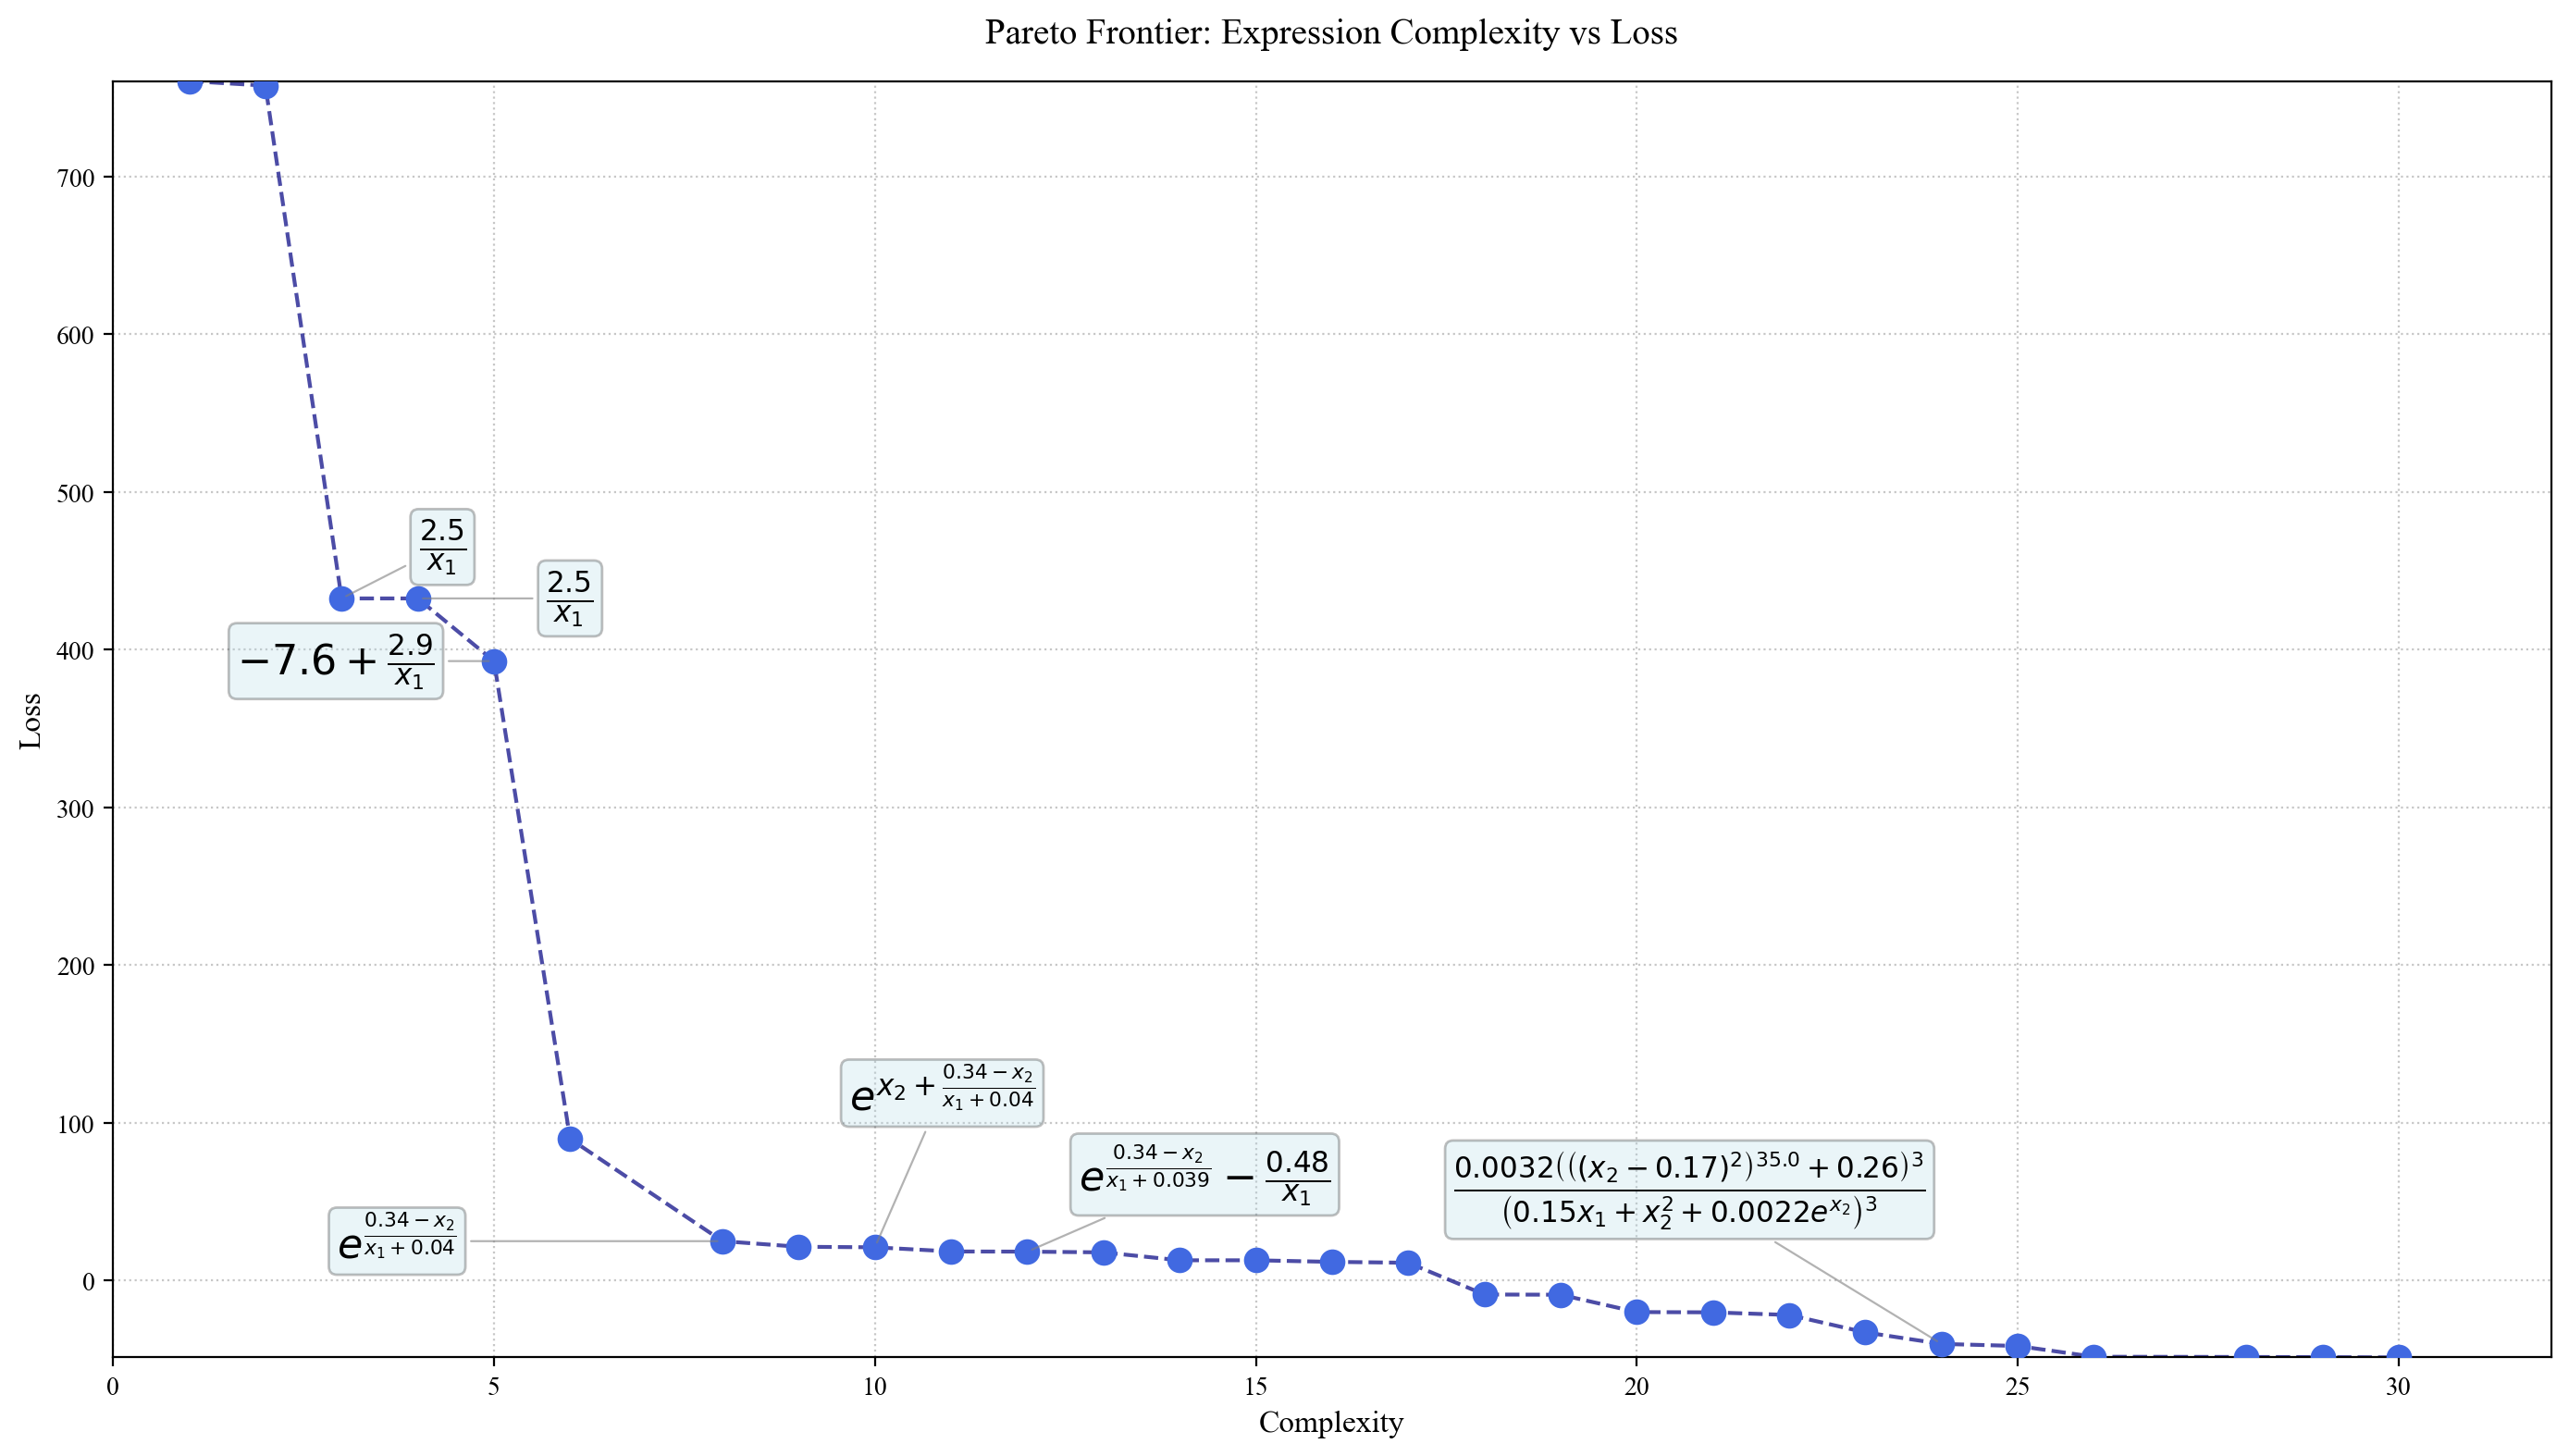

11926

In [101]:
range_of_interest = (1, 48)
indices_of_interest = [i for i, c in enumerate(complexity) if range_of_interest[0] <= c <= range_of_interest[1]]
complexity = [complexity[i] for i in indices_of_interest]
loss = [loss[i] for i in indices_of_interest]
raw_equations = [raw_equations[i] for i in indices_of_interest]

# 2) Sympy setup
x1, x2 = sp.symbols('x1 x2')

# 3) Custom function to round constants only (not function arguments)
def round_constants(expr, ndigits=1):
    """
    Round every bare Float in `expr` so that, when printed,
    it has exactly `ndigits` digits after the decimal point
    in scientific notation (i.e. nd+1 significant figures).
    """
    def _is_leaf_float(e):
        return e.is_Float and not e.args

    def _round_sci(e):
        f = float(e)
        # format with `ndigits` places after the decimal in the mantissa:
        sci_str = f"{f:.{ndigits}e}"
        return sp.Float(sci_str)

    return expr.replace(_is_leaf_float, _round_sci)

# 4) Function to convert pow2 to squared form without evaluation
def convert_pow2(expr):
    # Find all pow2 calls
    if expr.func.__name__ == 'pow2':
        return sp.Pow(convert_pow2(expr.args[0]), 2, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow2(arg) for arg in expr.args]) if expr.args else expr

def convert_pow3(expr):
    # Find all pow3 calls
    if expr.func.__name__ == 'pow3':
        return sp.Pow(convert_pow3(expr.args[0]), 3, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow3(arg) for arg in expr.args]) if expr.args else expr

def convert_pow4(expr):
    # Find all pow4 calls
    if expr.func.__name__ == 'pow4':
        return sp.Pow(convert_pow4(expr.args[0]), 4, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow4(arg) for arg in expr.args]) if expr.args else expr

def convert_pow5(expr):
    # Find all pow5 calls
    if expr.func.__name__ == 'pow5':
        return sp.Pow(convert_pow5(expr.args[0]), 5, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow5(arg) for arg in expr.args]) if expr.args else expr

# 4) Function to convert pow_int without evaluation
def convert_pow_int(expr):
    # Find all pow_int calls
    if expr.func.__name__ == 'pow_int':
        base, exp = expr.args
        # If exp is literally an integer, convert to a Python int
        if exp.is_integer and exp.is_number:
            exp = int(exp)
        # Otherwise leave exp symbolic
        return sp.Pow(convert_pow_int(base), convert_pow_int(exp), evaluate=False)

    # Recursively descend into all other function applications
    if expr.args:
        return expr.func(*[convert_pow_int(arg) for arg in expr.args])
    else:
        return expr
    
def replace_pow_functions_recursive(expr: sp.Expr) -> sp.Expr:
    """
    Recursively replaces custom functions like powN(x) with standard power notation x**N.
    E.g. pow3(x + pow2(y)) → (x + y**2)**3
    """
    # First, apply recursively to all arguments (bottom-up),
    # so that nested pow-functions inside arguments get replaced too.
    expr = expr.xreplace({})  # no-op; just ensures expr is a Basic (not strictly needed)

    # Define replacement function
    def _repl(f):
        # check it's a function call
        if not isinstance(f, sp.Function):
            return f

        name = f.func.__name__
        if not name.startswith("pow"):
            return f

        # parse N from “powN”
        try:
            N = int(name[len("pow"):])
        except ValueError:
            return f

        if len(f.args) != 1:
            # unexpected arity, leave unchanged
            return f

        base = f.args[0]
        # Recursively transform the base
        new_base = replace_pow_functions_recursive(base)
        return new_base ** N

    # Use replace with map=False (so it returns an Expr)
    new_expr = expr.replace(
        lambda x: isinstance(x, sp.Function) and x.func.__name__.startswith("pow"),
        _repl,
        map=False
    )
    return new_expr

# 5) Build MathText labels
latex_labels = []
exprs_final = []
function_ready = []
for id, s in enumerate(raw_equations):
    try:
        # Pre-process pow2 -> custom function
        s_processed = s.replace('pow2', 'pow2_func')
        s_processed = s.replace('pow3', 'pow3_func')
        s_processed = s.replace('pow4', 'pow4_func')
        s_processed = s.replace('pow5', 'pow5_func')
        s_processed = s_processed.replace('pow_int', 'pow_int_func')
        
        # Define custom functions
        locals_dict = {
            'x1': x1,
            'x2': x2,
            'pow2_func': sp.Function('pow2'),
            'pow3_func': sp.Function('pow3'),
            'pow4_func': sp.Function('pow4'),
            'pow5_func': sp.Function('pow5'),
            'pow_int_func': sp.Function('pow_int'),
            'asin': sp.asin,
            'atan': sp.atan,
            'tan': sp.tan,
            'exp': sp.exp,
        }
        
        # Parse while preserving structure
        expr = parse_expr(s_processed, evaluate=False, local_dict=locals_dict)
        
        # Convert pow2_func to squared form
        expr_converted_pow2 = convert_pow2(expr)
        expr_converted_pow3 = convert_pow3(expr)
        expr_converted_pow4 = convert_pow4(expr)
        expr_converted_pow5 = convert_pow5(expr)
        expr_converted = convert_pow_int(expr_converted_pow5)
        
        # Round constants (only standalone floats)
        expr_converted_int1 = round_constants(expr_converted)
        expr_converted_int2 = round_constants(expr_converted_int1)
        expr_final = round_constants(expr_converted_int2)
        # expr_final = expr_final.simplify()
        # expr_final = expr_final.expand()
        exprs_final.append(expr_final)

        # Get MathText-friendly LaTeX
        mt = replace_pow_functions_recursive(expr_final)
        expr_converted_int1 = round_constants(mt)
        expr_converted_int2 = round_constants(expr_converted_int1)
        mt = round_constants(expr_converted_int2)
        mt = sp.latex(mt)
        latex_labels.append(f"${mt}$")
        
        # Replace 'exp' with 'np.exp'
        modified_expression = s.replace('exp', 'np.exp')
    
        # Replace 'log' with 'np.log'
        modified_expression = modified_expression.replace('log', 'np.log')
        function_ready.append(modified_expression)
        # Debug print
        print(f"Original at complexity {complexity[id]}: {s}")
        print(f"function_ready: {modified_expression}")
        print(f"Processed: {expr_final}")
        print(f"LaTeX: {mt}\n")
    except Exception as e:
        print(f"Error processing expression: {s}\n{e}")
        latex_labels.append(f"Error: {s}")

# 6) Manual offsets for clarity
offsets = [
    (0, 0), (0, 0), (30, 20), (50, 0), (-100, 0),
    (0, 0), (-150, 0), (0, 0), (-10, 60), (0, 0),
    (20, 30), (0, 0), (0, 0), (0, 0), (0, 0),
    (0, 0), (0, 0), (0, 0), (0, 0), (0, 0),
    (0, 0), (0, 0), (-190, 60), (0, 0), (0, 0),
]

# 7) Plot
fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(complexity, loss, s=80, zorder=3, color='royalblue')
ax.plot(complexity, loss, linestyle='--', alpha=0.7, zorder=2, color='navy')

# Set axis limits
ax.set_xlim(min(complexity) - 1, max(complexity) + 2)
ax.set_ylim(min(loss) - 0.0005, max(loss))
fig.subplots_adjust(right=0.75)


skip_indices = []
keep_indices = [3-1, 4-1, 5-1, 7-1, 9-1, 11-1, 23-1]
# Annotate with MathText labels
for i, (x, y, lbl, (dx, dy)) in enumerate(zip(complexity, loss, latex_labels, offsets)):
    if i in skip_indices or (i not in keep_indices):
        continue
    ax.annotate(
        lbl,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=16,
        bbox=dict(boxstyle='round,pad=0.2', alpha=0.25, fc='lightblue'),
        arrowprops=dict(arrowstyle='-', lw=0.8, alpha=0.6, color='gray')
    )

ax.set_title("Pareto Frontier: Expression Complexity vs Loss", fontsize=14, pad=15)
ax.set_xlabel("Complexity", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)
ax.tick_params(axis='both', which='major', labelsize=10)
# ax.grid(True)

plt.tight_layout()
plt.show()
# Explicitly close the figure object
plt.close() 
# Force the Python garbage collector to clean up memory
gc.collect()

# Residuals: Prediction - Ground Truth

In [19]:
level_min = 0
level_max = 200
level_min_delta = -20
level_max_delta = 20

In [20]:
predicted_functions = [eval(f'lambda x1, x2: {str_func}', {'np':np, 'pow2':pow2, 'pow3':pow3, 'pow4':pow4, 'pow5':pow5}) for str_func in function_ready]
masked_functions = [
    (lambda f: lambda x1, x2, mask: np.where(mask, 0, f(x1, x2)))(f)
    for f in predicted_functions
]
mask = (grids[1] > 7 * grids[0]) | (grids[1] < 0)

In [21]:
# 2. Interpolate the reflected function at the original grid points
# Prepare the interpolator for the original function
interp_kde_at_samples = RegularGridInterpolator(
    (grids[0][:,0], grids[1][0,:]),  # axes of the grid
    kde_predicted_density,            # function values
    bounds_error=False,
    fill_value=0
)

interp_neural_at_samples = RegularGridInterpolator(
    (grids[0][:,0], grids[1][0,:]),  # axes of the grid
    neural_predicted_density,            # function values
    bounds_error=False,
    fill_value=0
)


# Load the test set for the Gaussian mixture
test_samples = np.loadtxt("./data/processed_data/dijet_test_samples.csv", delimiter=",")

# For each original grid point, get the value of the reflected functions at that location
kde_eval_at_samples = interp_kde_at_samples(test_samples)
neural_eval_at_samples = interp_neural_at_samples(test_samples)
likelihood_score = np.sum(np.log(kde_eval_at_samples+1e-12))/np.shape(test_samples)[0]
likelihood_score_neural = np.sum(np.log(neural_eval_at_samples))/np.shape(test_samples)[0]
print(f"Likelihood score of the corrected KDE: {likelihood_score:,}")
print(f"Likelihood score of the neural spline: {likelihood_score_neural:,}")

Likelihood score of the corrected KDE: 4.722576214899591
Likelihood score of the neural spline: 5.792892715958686


## Normalize each function

In [22]:
clipped_masked_functions = [
    (lambda f: lambda x1, x2: np.maximum(1e-9, f(x1, x2, mask)))(f)
    for f in masked_functions
]

In [23]:
# 1. Calculate grid spacing
dx = grids[0][1, 0] - grids[0][0, 0]
dy = grids[1][0, 1] - grids[1][0, 0]
cell_area = dx * dy

integrals = []
integrals_unclipped = []
bad_counts = []

for i, func in enumerate(clipped_masked_functions):
    # Suppress warnings so the console doesn't flood during the loop
    # with np.errstate(all='ignore'):
    values = func(grids[0], grids[1])
        
    # 2. Count non-finite points (NaN or Inf)
    # np.isfinite returns False for both NaN and Inf
    bad_mask = ~np.isfinite(values)
    num_bad = np.sum(bad_mask)
    bad_counts.append(num_bad)
        
    # 3. Compute the integral
    # Note: If num_bad > 0, total_integral will likely be NaN or Inf
    total_integral = np.sum(values) * cell_area
    integrals.append(total_integral)
        
    if num_bad > 0:
        print(f"Function {i}: {num_bad:,} bad coordinates found.")

for i, func in enumerate(masked_functions):
    # Suppress warnings so the console doesn't flood during the loop
    # with np.errstate(all='ignore'):
    values = func(grids[0], grids[1], mask)
        
    # 2. Count non-finite points (NaN or Inf)
    # np.isfinite returns False for both NaN and Inf
    bad_mask = ~np.isfinite(values)
    num_bad = np.sum(bad_mask)
    bad_counts.append(num_bad)
        
    # 3. Compute the integral
    # Note: If num_bad > 0, total_integral will likely be NaN or Inf
    total_integral = np.sum(values) * cell_area
    integrals_unclipped.append(total_integral)
        
    if num_bad > 0:
        print(f"Function {i}: {num_bad:,} bad coordinates found.")

<string>:1: RuntimeWarning: overflow encountered in exp
<string>:1: RuntimeWarning: overflow encountered in exp
<string>:1: RuntimeWarning: overflow encountered in exp
<string>:1: RuntimeWarning: overflow encountered in exp
<string>:1: RuntimeWarning: overflow encountered in exp
<string>:1: RuntimeWarning: overflow encountered in exp
<string>:1: RuntimeWarning: overflow encountered in exp
<string>:1: RuntimeWarning: overflow encountered in exp
<string>:1: RuntimeWarning: overflow encountered in multiply
<string>:1: RuntimeWarning: overflow encountered in exp
<string>:1: RuntimeWarning: overflow encountered in exp
<string>:1: RuntimeWarning: overflow encountered in multiply
<string>:1: RuntimeWarning: invalid value encountered in log
<string>:1: RuntimeWarning: invalid value encountered in log
<string>:1: RuntimeWarning: invalid value encountered in log
<string>:1: RuntimeWarning: invalid value encountered in log
<string>:1: RuntimeWarning: invalid value encountered in log


In [24]:
# plt.plot(integrals, marker = 'x', label='with clipping')
# plt.plot(integrals_unclipped, marker='o', markerfacecolor='none', label='no clipping')
# plt.plot([0, 25], [1,1])
# plt.ylabel('integrals of the returned expressios')
# plt.xlabel('expression complexity')
# plt.xlim([0,25])
# plt.legend()
# plt.grid(True)
# plt.show()


Likelihood score of the corrected KDE: 4.722576214899293

Function at complexity 1: Likelihood score = -0.12770411893633332
Function at complexity 2: Likelihood score = 0.02835055295439198
Function at complexity 3: Likelihood score = 5.545817466539071
Function at complexity 4: Likelihood score = 5.5432503430959565
Function at complexity 5: Likelihood score = 5.631986396048728
Function at complexity 6: Likelihood score = 5.80285653906266
Function at complexity 8: Likelihood score = 5.944746160125734
Function at complexity 9: Likelihood score = 5.999571790928316
Function at complexity 10: Likelihood score = 5.973096713080127
Function at complexity 11: Likelihood score = 5.88679208256342
Function at complexity 12: Likelihood score = 5.783357705837297
Function at complexity 13: Likelihood score = 5.834787242144616
Function at complexity 14: Likelihood score = 5.789940476546212
Function at complexity 15: Likelihood score = 5.789940476546211
Function at complexity 16: Likelihood score = 5.79

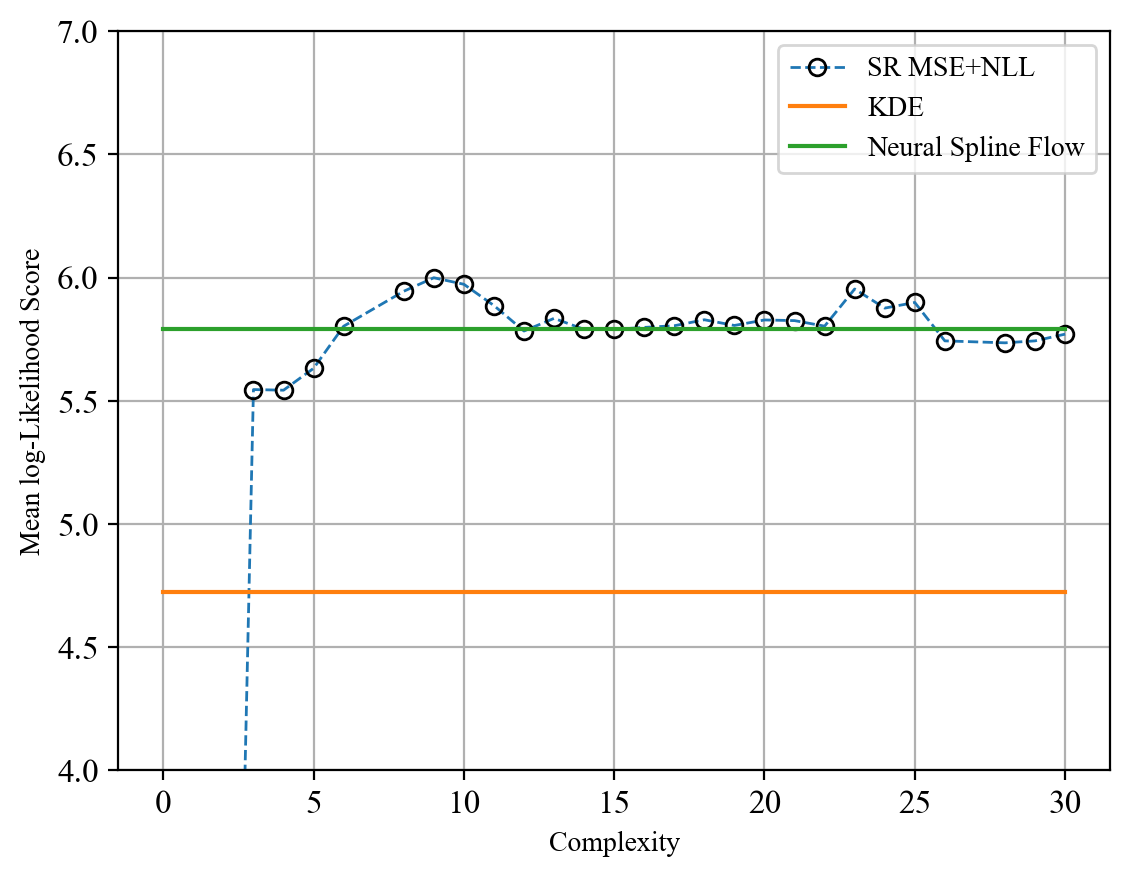

In [25]:
kde_eval_at_samples = interp_kde_at_samples(test_samples)
likelihood_score = np.sum(np.log(kde_eval_at_samples+1e-130))/np.shape(test_samples)[0]
print(f"Likelihood score of the corrected KDE: {likelihood_score:,}\n")

log_likelihood_scores = []
for idx, func in enumerate(predicted_functions):
    # Compute likelihood scores
    prediction_eval_at_samples = func(test_samples[:, 0], test_samples[:, 1])
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples[prediction_eval_at_samples>1e-12]/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores.append(likelihood_score_pred)
    print(f"Function at complexity {complexity[idx]}: Likelihood score = {likelihood_score_pred:,}")

# plt.plot(complexityold, log_likelihood_scoresold, marker="x", markeredgecolor="black", linestyle="--", linewidth=1, label="SR MSE")
plt.plot(complexity, log_likelihood_scores, marker="o", markeredgecolor="black", markerfacecolor='none', linestyle="--", linewidth=1, label="SR MSE+NLL")
plt.plot([0, max(complexity)], [likelihood_score, likelihood_score], label="KDE")
plt.plot([0, max(complexity)], [likelihood_score_neural, likelihood_score_neural], label="Neural Spline Flow")
plt.xlabel("Complexity", fontname='Times New Roman')
plt.ylabel("Mean log-Likelihood Score", fontname='Times New Roman')
# plt.title("Mean log-Likelihood Score vs. Complexity")
plt.ylim([4, 7])
plt.grid(True)
plt.legend()
plt.legend(prop={'family': 'Times New Roman'})  # size optional
plt.xticks(fontname='Times New Roman', fontsize=12)
plt.yticks(fontname='Times New Roman', fontsize=12)
plt.show()

In [26]:
# # Iterate over the masked_functions list
# for i, current_function in enumerate(masked_functions):
#     # Skip if the function is not defined or you only want to plot specific ones
#     # if i not in [2, 5]:  # Example: plot only indices 2 and 5
#     #     continue

#     # Get the title for the current function
#     title = latex_labels[i]

#     # Create a new figure for each iteration
#     fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
#     # --- Plot 1: Original Function Plot (current_function) ---
#     ax1 = axes[0]
    
#     # Calculate the function output
#     function_output = current_function(grids[0], grids[1], mask)
#     if np.shape(function_output) == (1,1):
#         function_output = function_output*np.ones(grids[0].shape)

#     # Set levels based on your required range
#     levels_original = np.linspace(level_min, level_max, 200)
    
#     contour1 = ax1.contourf(
#         grids[0], grids[1],
#         function_output,
#         levels=levels_original,
#         cmap='viridis',
#         extend='max'
#     )
#     # The colorbar needs to be updated for each plot
#     fig.colorbar(contour1, ax=ax1, label="Density", ticks=np.linspace(level_min, level_max, 11))
    
#     ax1.set_xlabel(r"$m_{jj}$ scaled")
#     ax1.set_ylabel(r"$HT$ scaled")
#     ax1.set_title(f"Original complexity {complexity[i]}: {title}")
#     ax1.set_xlim(-0.1, 0.4)
#     ax1.set_ylim(-0.1, 0.4)

#     # --- Plot 2: Residual Plot (current_function - sum_grid) ---
#     ax2 = axes[1]
    
#     # Calculate the residual
#     residual_output = function_output - neural_predicted_density
    
#     # Set levels for the residual plot (should be symmetric around zero)
#     levels_residual = np.linspace(level_min_delta, level_max_delta, 200)
    
#     contour2 = ax2.contourf(
#         grids[0], grids[1],
#         residual_output,
#         levels=levels_residual,
#         cmap='seismic', # 'seismic' is good for residuals (zero in the middle)
#         extend='both'
#     )
#     # The colorbar needs to be updated for each plot
#     fig.colorbar(contour2, ax=ax2, label="Residual Density", ticks=np.linspace(level_min_delta, level_max_delta, 11))
    
#     ax2.set_xlabel(r"$m_{jj}$ scaled")
#     ax2.set_ylabel(r"$HT$ scaled")
#     ax2.set_title(f"Residual for complexity {complexity[i]}: {title} - KDE Estimate")
#     ax2.set_xlim(-0.1, 0.4)
#     ax2.set_ylim(-0.1, 0.4)

#     # Final adjustments and saving
#     plt.tight_layout()
#     plt.show()
#     plt.close(fig) 
    
#     # 3. Force the Python garbage collector to clean up memory
#     gc.collect()
#     prediction_eval_at_samples = current_function(test_samples[:,0], test_samples[:,1], np.zeros_like(test_samples[:,0]))
#     likelihood_score_of_prediction = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))
#     print(f"Complexity {complexity[i]}: Likelihood score: {likelihood_score_of_prediction:,}")
#     print(f"complexity {complexity[i]} :: min predict: {np.min(current_function(grids[0], grids[1], mask)):.2f}, max predict: {np.max(current_function(grids[0], grids[1], mask)):.2f}")
#     neural_predicted_density[mask] = 0
#     min_residual = np.min(current_function(grids[0], grids[1], mask) - neural_predicted_density)
#     max_residual = np.max(current_function(grids[0], grids[1], mask) - neural_predicted_density)
#     print(f"complexity {complexity[i]} :: min residual: {min_residual:.2f}, max residual: {max_residual:.2f}")
#     mse_error = np.mean((residual_output)**2)
#     print(f"Complexity {complexity[i]}: MSE error: {mse_error:.6e}")
#     # Explicitly delete large arrays and clear memory before the next loop iteration
#     del prediction_eval_at_samples
#     del residual_output
#     gc.collect()


# # Note: plt.show() is typically outside the loop if you want to see all plots
# # or not used at all if you are just saving the files.
# print(f"Finished generating and saving plots for {len(predicted_functions)} functions.")


## Clipping comparison

In [27]:
# complexity = complexity_hybrid

Likelihood score of the corrected KDE: 4.722576214899293

Function at complexity 1: Likelihood score = -0.11721424532362049
Function at complexity 2: Likelihood score = -0.6750707579245574
Function at complexity 3: Likelihood score = 3.4427712046656582
Function at complexity 4: Likelihood score = 3.442771204664491
Function at complexity 5: Likelihood score = 4.368529229752549
Function at complexity 6: Likelihood score = 5.519429159330513
Function at complexity 8: Likelihood score = 5.263827579695394
Function at complexity 9: Likelihood score = 5.077270968050485
Function at complexity 10: Likelihood score = 5.056913741875431
Function at complexity 11: Likelihood score = 5.742769180023169
Function at complexity 12: Likelihood score = 5.69091827539134
Function at complexity 13: Likelihood score = 5.838370817033228
Function at complexity 14: Likelihood score = 5.485675195923672
Function at complexity 15: Likelihood score = 5.485675195923672
Function at complexity 16: Likelihood score = 5.4

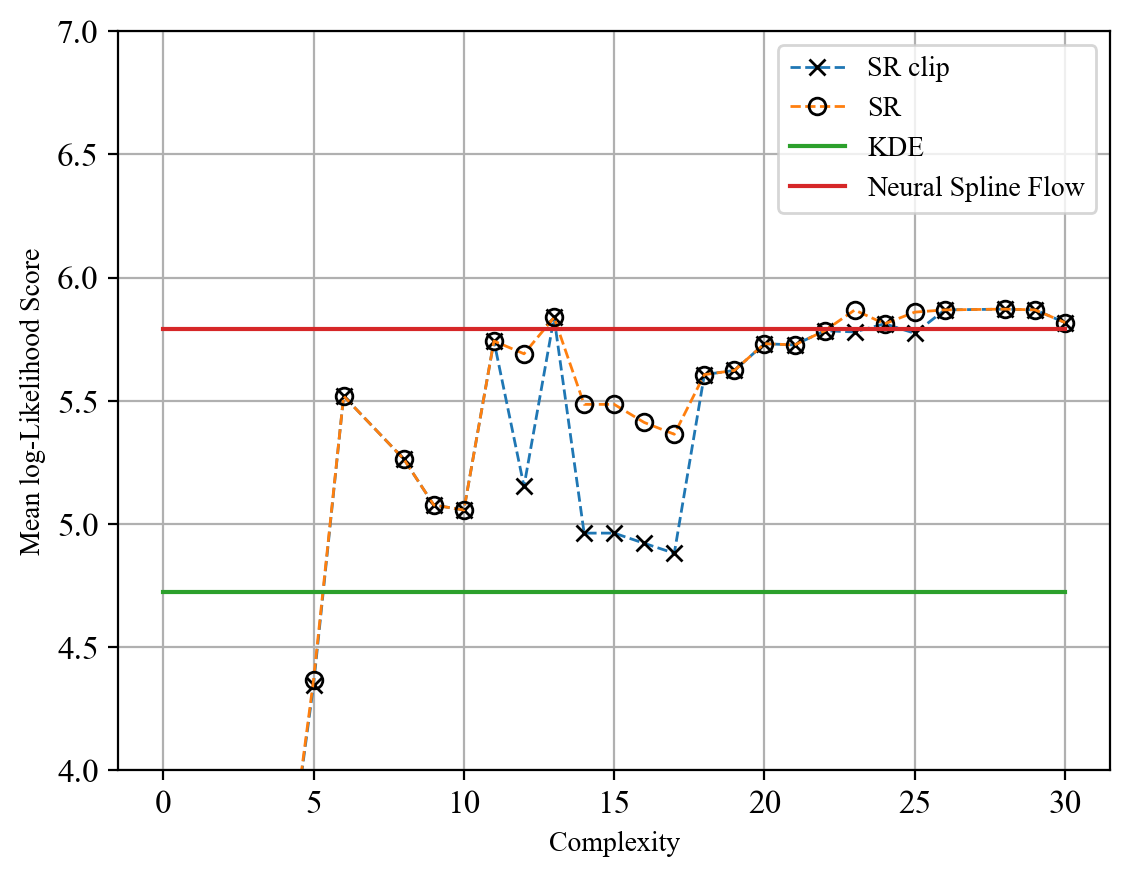

In [ ]:
kde_eval_at_samples = interp_kde_at_samples(test_samples)
likelihood_score = np.sum(np.log(kde_eval_at_samples+1e-130))/np.shape(test_samples)[0]
print(f"Likelihood score of the corrected KDE: {likelihood_score:,}\n")

log_likelihood_scores = []
for idx, func in enumerate(predicted_functions):
    # Compute likelihood scores
    prediction_eval_at_samples = (1/integrals[idx])*func(test_samples[:, 0], test_samples[:, 1])
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples[prediction_eval_at_samples>1e-12]/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores.append(likelihood_score_pred)
    print(f"Function at complexity {complexity[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_clipped = []
for idx, func in enumerate(predicted_functions):
    # Compute likelihood scores
    prediction_eval_at_samples = (1/integrals[idx])*np.max([1e-12*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples[prediction_eval_at_samples>1e-12]/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_clipped.append(likelihood_score_pred)
    print(f"Function at complexity {complexity[idx]}: Likelihood score = {likelihood_score_pred:,}")


plt.plot(complexity, log_likelihood_scores_clipped, marker="x", markeredgecolor="black", linestyle="--", linewidth=1, label="SR clip")
plt.plot(complexity, log_likelihood_scores, marker="o", markeredgecolor="black", markerfacecolor='none', linestyle="--", linewidth=1, label="SR")
plt.plot([0, max(complexity)], [likelihood_score, likelihood_score], label="KDE")
plt.plot([0, max(complexity)], [likelihood_score_neural, likelihood_score_neural], label="Neural Spline Flow")
plt.xlabel("Complexity", fontname='Times New Roman')
plt.ylabel("Mean log-Likelihood Score", fontname='Times New Roman')
# plt.title("Mean log-Likelihood Score vs. Complexity")
plt.ylim([4, 7])
plt.grid(True)
plt.legend()
plt.legend(prop={'family': 'Times New Roman'})  # size optional
plt.xticks(fontname='Times New Roman', fontsize=12)
plt.yticks(fontname='Times New Roman', fontsize=12)
plt.show()

# Other Views (Miscellaneous)

## Scatter plot of data input to SR pipeline

In [29]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

data_original = np.loadtxt('data/processed_data/dijet_joint_data.csv', delimiter=',', skiprows=1)
indices = np.random.choice(data_original.shape[0], size=1000, replace=False)
data = data_original[indices]
fig = go.Figure(data=[go.Scatter3d(
    x=data[:, 0],
    y=data[:, 1],
    z=data[:, 2],
    mode='markers',
    marker=dict(
        size=1,
        color='red',
        opacity=0.8
    )
)])

# fig.show(renderer='browser')
pio.show(fig)

## Joint data in pipeline

In [30]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

data_in_pipeline = np.loadtxt('data/processed_data/dijet_joint_data_in_pipeline.csv', delimiter=',', skiprows=1)
indices = np.random.choice(data_in_pipeline.shape[0], size=1000, replace=False)
data = data_in_pipeline[indices]
fig = go.Figure(data=[go.Scatter3d(
    x=data[:, 0],
    y=data[:, 1],
    z=data[:, 2],
    mode='markers',
    marker=dict(
        size=1,
        color='red',
        opacity=0.8
    )
)])

# fig.show(renderer='browser')
pio.show(fig)

# Final Plot

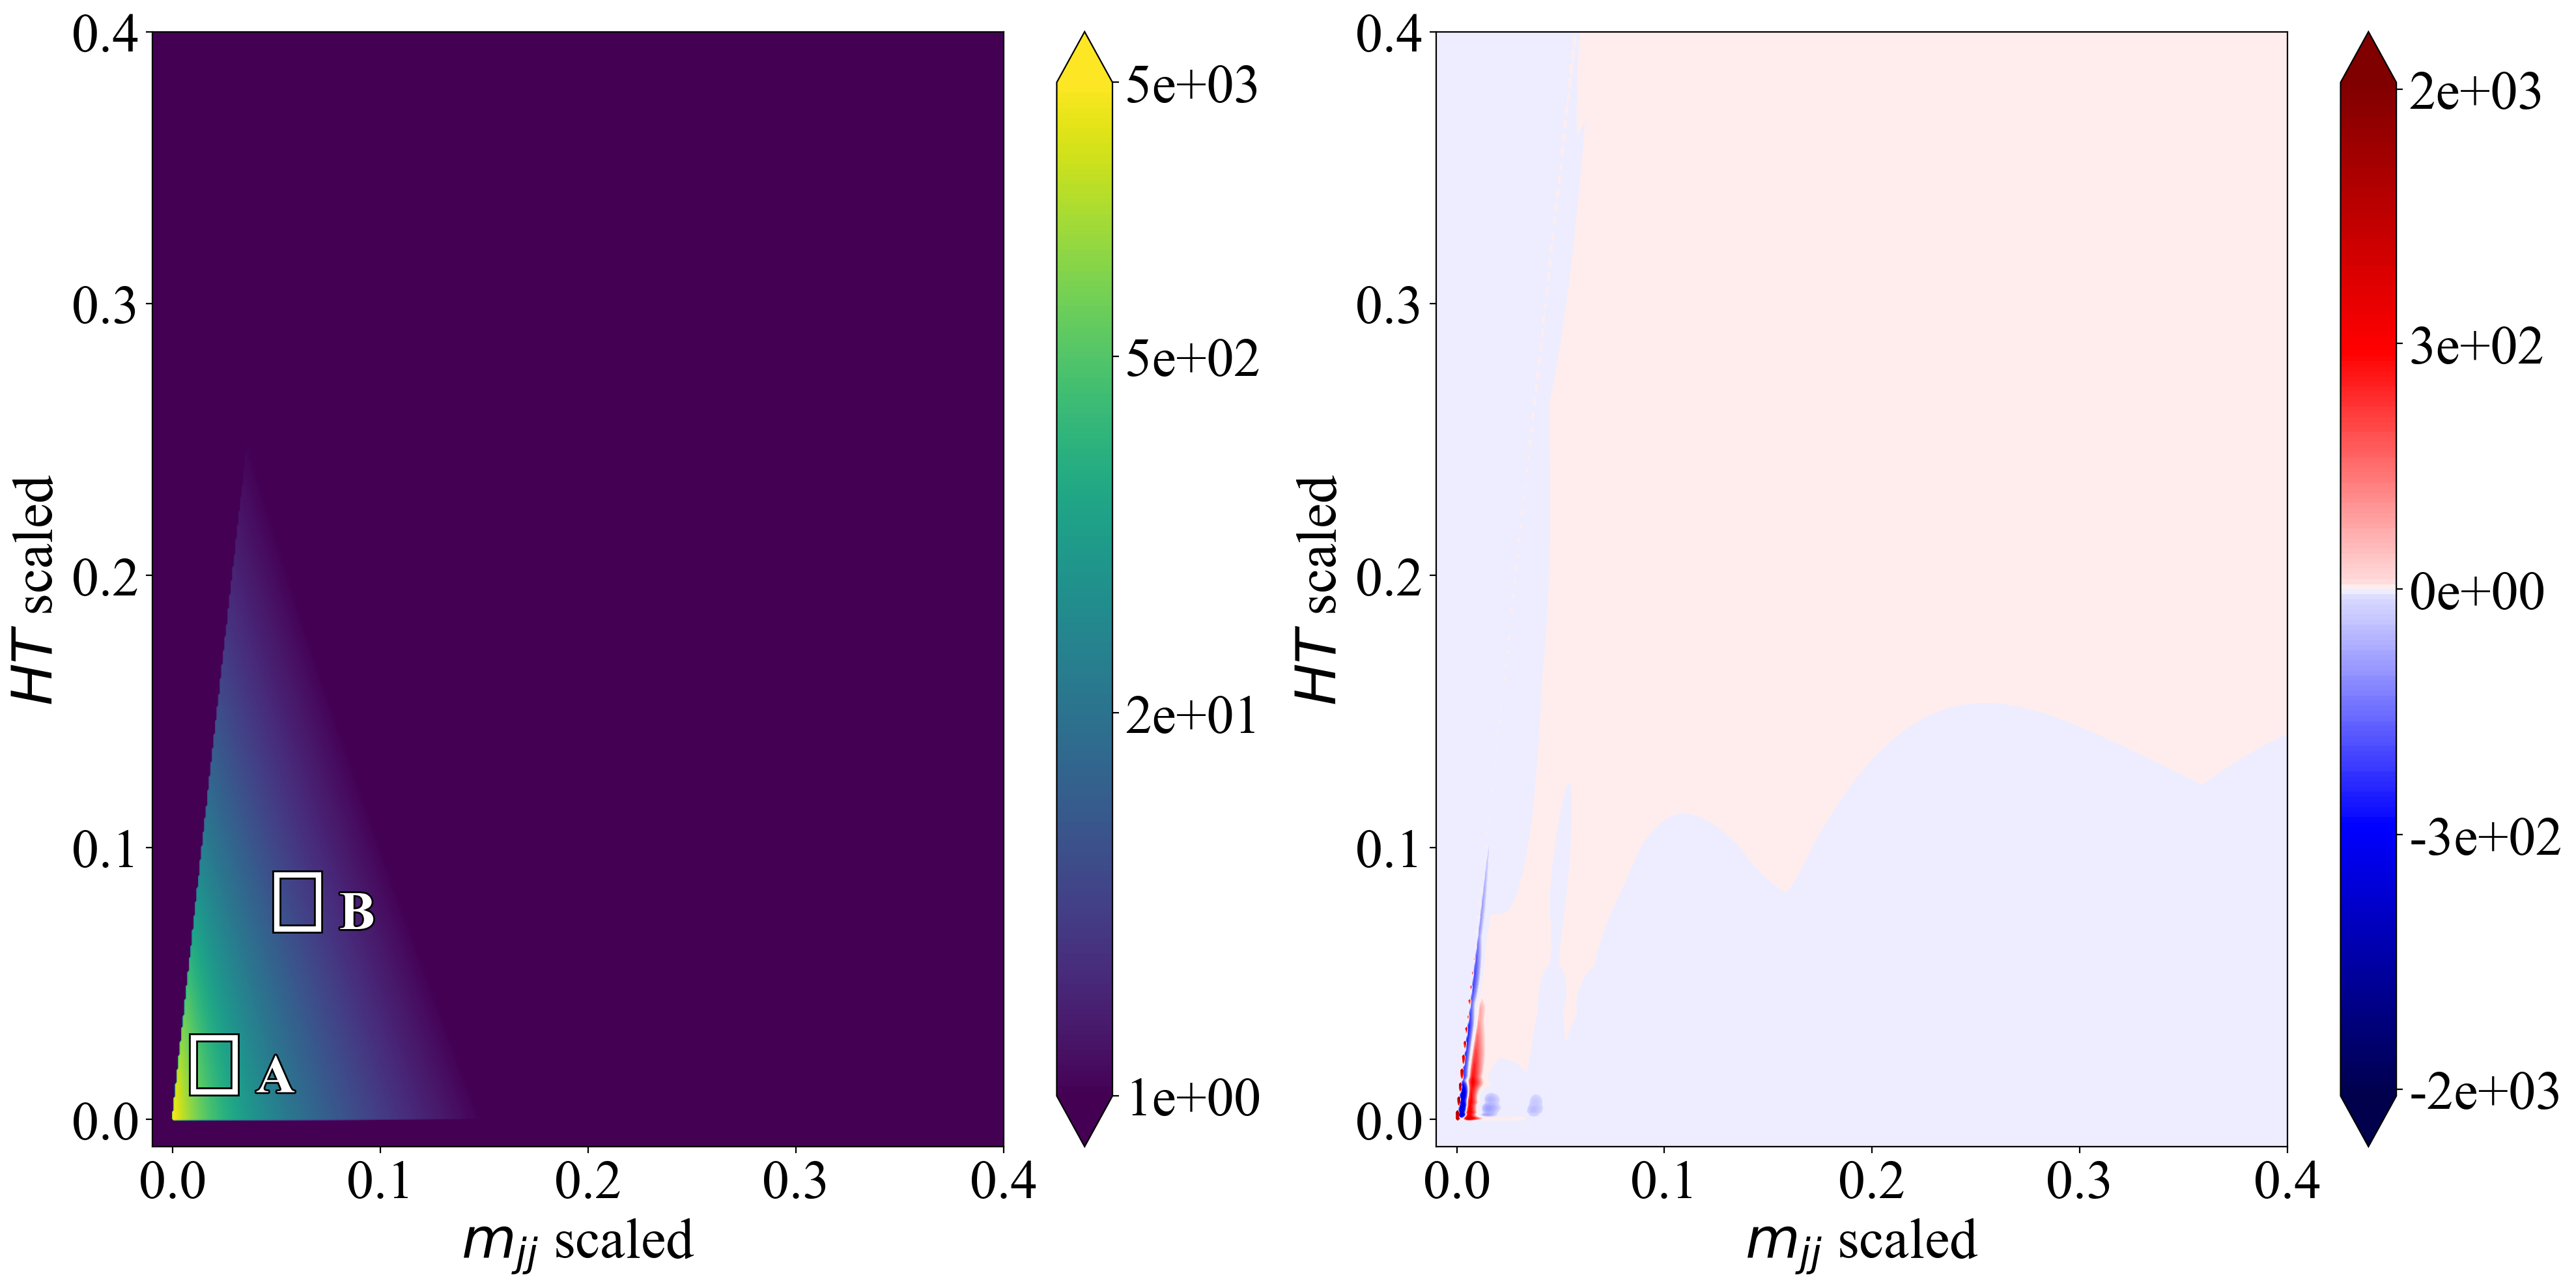

In [72]:
import matplotlib.patheffects as path_effects
import matplotlib.patches as patches
import matplotlib.colors as colors
import matplotlib.ticker as ticker

# Get the title for the current function
title = latex_labels[i]

# Create a new figure for each iteration
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

level_min = 0
level_max = 5000
level_min_delta = -2100
level_max_delta = 2100
# --- Plot 1: Original Function Plot (current_function) ---
ax1 = axes[0]
    
# Calculate the function output
function_output = np.clip(masked_functions[-1](grids[0], grids[1], mask), 1e-10, None)
if np.shape(function_output) == (1,1) or np.shape(function_output)==():
    function_output = (1/integrals[-1])*function_output*np.ones(grids[0].shape)

# # Set levels based on your required range
# levels_original = np.linspace(level_min, level_max, 200)

# 1. Define log-spaced levels for smooth color transitions
# We start at 1 (or a small epsilon) because LogNorm cannot handle 0.
level_min_log = 1 ####
levels_original = np.geomspace(level_min_log, level_max, 200) ####
    
contour1 = ax1.contourf(
    grids[0], grids[1],
    function_output/density_scale_factor,
    levels=levels_original,
    cmap='viridis',
    norm=colors.LogNorm(vmin=level_min_log, vmax=level_max),
    extend='both'
)

cbar1 = fig.colorbar(contour1, ax=ax1, ticks = [1, 25, 500, 5000]) ####
cbar1.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0e')) ###3
# The colorbar needs to be updated for each plot
#cbar = fig.colorbar(contour1, ax=ax1, ticks=np.linspace(level_min, level_max, 5), format='%.1f')
# cbar.set_label("Density", fontsize=30)
cbar1.ax.tick_params(labelsize=30)
ax1.set_xlabel(r"$m_{jj}$ scaled", fontsize=31, fontname='Times New Roman')
ax1.set_ylabel(r"$HT$ scaled", fontsize=31, fontname='Times New Roman')
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax1.locator_params(axis='x', nbins=5)  # 5 ticks along x-axis
ax1.locator_params(axis='y', nbins=5)  # 4 ticks along y-axis
# ax1.set_title(f"AI-Kolmogorov Prediction", fontsize=31)
ax1.set_xlim(-0.01, 0.4)
ax1.set_ylim(-0.01, 0.4)
txt1 = ax1.text(0.04, 0.01, 'A', color='white', fontsize=30, fontweight='bold')
txt1.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                      path_effects.Normal()])
txt2 = ax1.text(0.08, 0.07, 'B', color='white', fontsize=30, fontweight='bold') ##FF4F00
txt2.set_path_effects([path_effects.Stroke(linewidth=2, foreground='black'),
                       path_effects.Normal()])
# ax1.add_patch(patches.Rectangle((0.01, 0.01), 0.02, 0.02, fill=False, edgecolor='white', linewidth=3))
# Outer border (thicker)
ax1.add_patch(patches.Rectangle((0.01, 0.01), 0.02, 0.02,
                                fill=False, edgecolor='black', linewidth=5))
# Inner border (on top)
ax1.add_patch(patches.Rectangle((0.01, 0.01), 0.02, 0.02,
                                fill=False, edgecolor='white', linewidth=3))
ax1.add_patch(patches.Rectangle((0.05, 0.07), 0.02, 0.02,
                                fill=False, edgecolor='black', linewidth=5))
# Inner border (on top)
ax1.add_patch(patches.Rectangle((0.05, 0.07), 0.02, 0.02,
                                fill=False, edgecolor='white', linewidth=3))

# --- Plot 2: Residual Plot (current_function - sum_grid) ---
ax2 = axes[1]

# 2. Define SymLogNorm
# linthresh is the range around zero that remains linear. 
# Decrease this to see more "structure" in tiny residuals.
lin_thresh = 50.0 

norm_residual = colors.SymLogNorm(
    linthresh=lin_thresh, 
    linscale=0.1, 
    vmin=level_min_delta, 
    vmax=level_max_delta, 
    base=10
)
    
# Calculate the residual
residual_output = function_output/density_scale_factor - neural_predicted_density
residual_output[mask] = 0.0
    
# Set levels for the residual plot (should be symmetric around zero)
levels_residual = np.linspace(level_min_delta, level_max_delta, 200)

# 3. Define levels that are dense near zero and sparse far away
# This ensures the 'seismic' contrast is sharp where it matters.
neg_levels = -np.geomspace(abs(level_min_delta), lin_thresh, 100)###
pos_levels = np.geomspace(lin_thresh, level_max_delta, 100)###
levels_residual = np.unique(np.concatenate([neg_levels, [0], pos_levels]))###
    
contour2 = ax2.contourf(
    grids[0], grids[1],
    residual_output,
    levels=levels_residual,
    cmap='seismic', # 'seismic' is good for residuals (zero in the middle)
    norm=norm_residual,
    extend='both'
)
# The colorbar needs to be updated for each plot
cbar = fig.colorbar(contour2, ax=ax2, norm=norm_residual, ticks = [-2000, -300, 0, 300, 2000]) ###
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0e')) ###3
# cbar = fig.colorbar(contour2, ax=ax2, ticks=np.linspace(level_min_delta, level_max_delta, 5), format='%.1f')
# cbar.set_label("Residual", fontsize=30)
cbar.ax.tick_params(labelsize=30)
ax2.set_xlabel(r"$m_{jj}$ scaled", fontsize=31, fontname='Times New Roman')
ax2.set_ylabel(r"$HT$ scaled", fontsize=31, fontname='Times New Roman')
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)
ax2.locator_params(axis='x', nbins=5)  # 5 ticks along x-axis
ax2.locator_params(axis='y', nbins=5)  # 4 ticks along y-axis
# ax2.set_title(f"AI-Kolmogorov Residual", fontsize=31)
ax2.set_xlim(-0.01, 0.4)
ax2.set_ylim(-0.01, 0.4)

# cbar = fig.colorbar(contour2, ax=ax2, norm=norm)
# cbar.ax.tick_params(labelsize=30)

# Final adjustments and saving
plt.tight_layout()
plt.show()
# fig.savefig("./visualization/dijet_plot.png", dpi=1000, bbox_inches='tight')
plt.close(fig) 
    

In [26]:
predicted_functions_hybrid = [eval(f'lambda x1, x2: {str_func}', {'np':np, 'pow2':pow2, 'pow3':pow3, 'pow4':pow4, 'pow5':pow5}) for str_func in function_ready]
masked_functions_hybrid = [
    (lambda f: lambda x1, x2, mask: np.where(mask, 0, f(x1, x2)))(f)
    for f in predicted_functions_hybrid
]

In [27]:
log_likelihood_scores_hybrid = log_likelihood_scores
complexity_hybrid = complexity

In [132]:
file_path_pure = "data/pareto_results/dijet_pure_neural_results.py"
exec(open(file_path_pure).read())

Original at complexity 1: x1
function_ready: x1
Processed: x1
LaTeX: x_{1}

Original at complexity 2: exp(x2)
function_ready: np.exp(x2)
Processed: exp(x2)
LaTeX: e^{x_{2}}

Original at complexity 4: exp(pow3(log(x1)))
function_ready: np.exp(pow3(np.log(x1)))
Processed: exp(pow3(log(x1)))
LaTeX: e^{\log{\left(x_{1} \right)}^{3}}

Original at complexity 5: exp(68.38495154531998 * log(x1))
function_ready: np.exp(68.38495154531998 * np.log(x1))
Processed: x1**68.0
LaTeX: x_{1}^{68.0}

Original at complexity 6: exp(702.5171289853683 + (-852.8787645837084 / x1))
function_ready: np.exp(702.5171289853683 + (-852.8787645837084 / x1))
Processed: 1.3e+305*exp(-850.0/x1)
LaTeX: 1.3 \cdot 10^{305} e^{- \frac{850.0}{x_{1}}}

Original at complexity 7: exp(pow3(-9.72473987523536 / x1) - -697.9441155401239)
function_ready: np.exp(pow3(-9.72473987523536 / x1) - -697.9441155401239)
Processed: 1.3e+303*exp(pow3(-9.7/x1))
LaTeX: 1.3 \cdot 10^{303} e^{- \frac{910.0}{x_{1}^{3}}}

Original at complexity 9: e

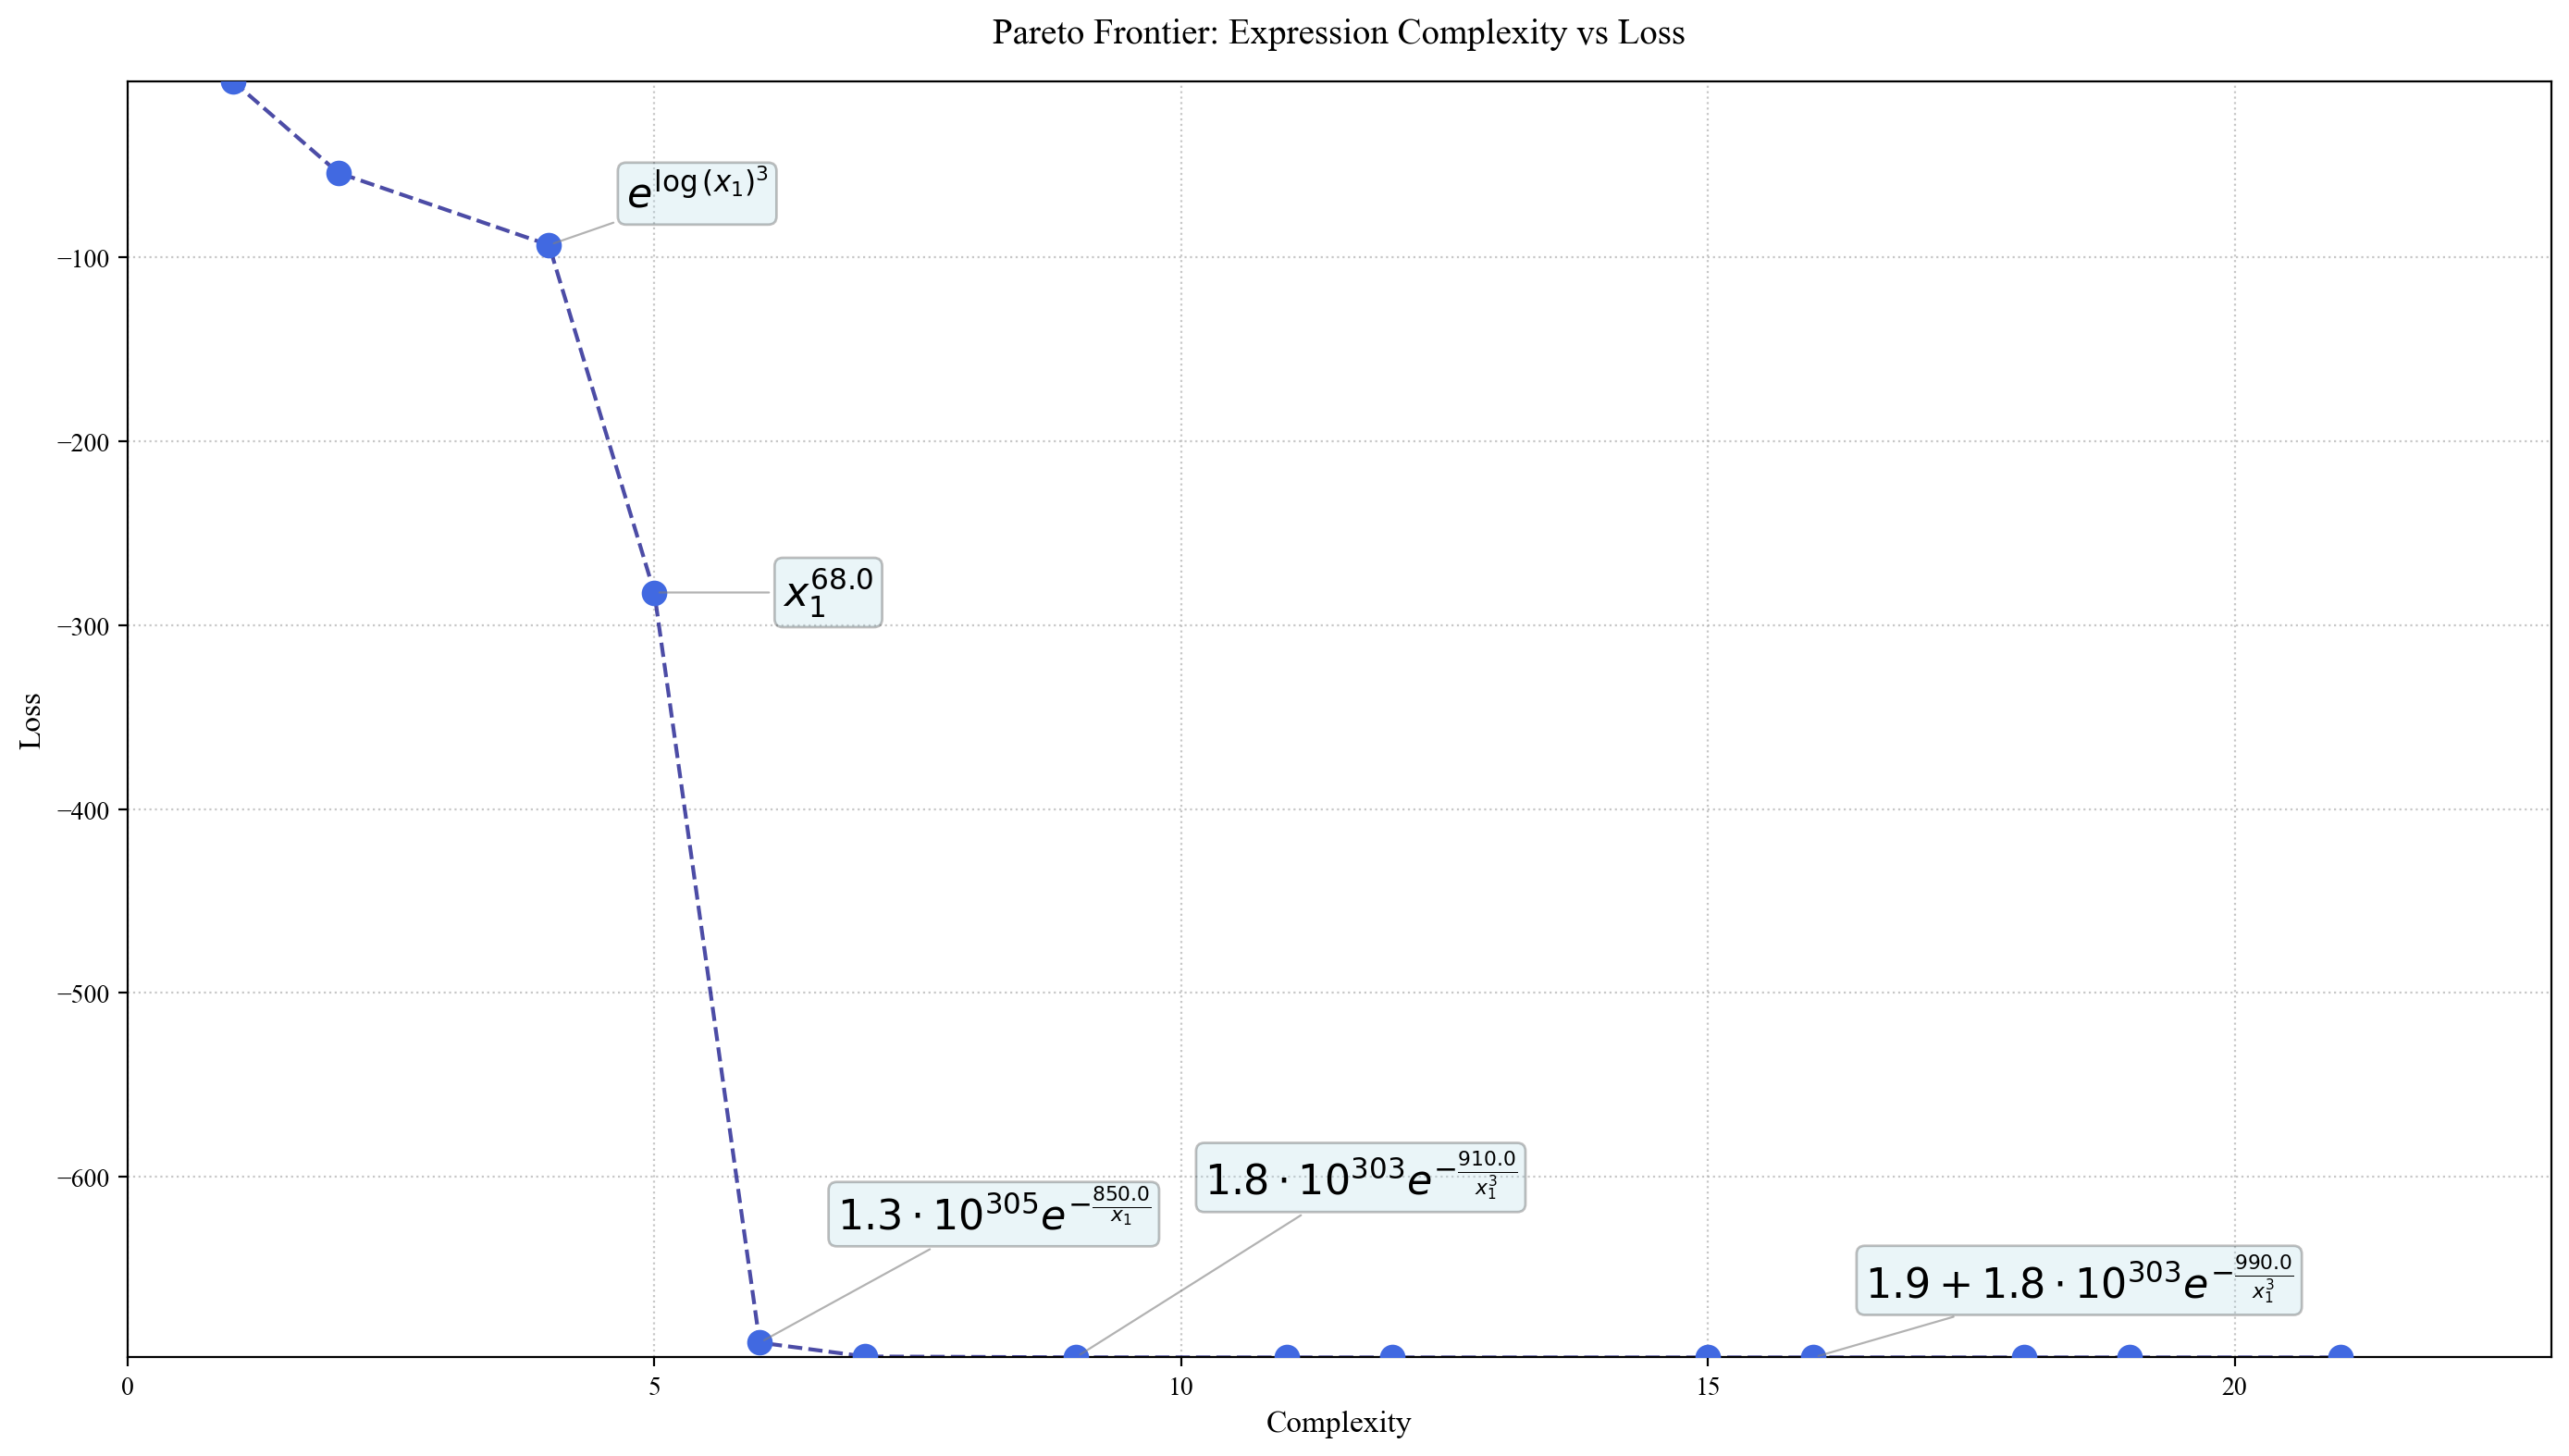

Expr 1 original: $x_{1}$
Expr 2 original: $e^{x_{2}}$
Expr 3 original: $e^{\log{\left(x_{1} \right)}^{3}}$
Expr 4 original: $x_{1}^{68.0}$
Expr 5 original: $1.3 \cdot 10^{305} e^{- \frac{850.0}{x_{1}}}$
Expr 6 original: $1.3 \cdot 10^{303} e^{- \frac{912.673}{x_{1}^{3}}}$
Expr 7 original: $1.8 \cdot 10^{303} e^{- \frac{912.673}{x_{1}^{3}}}$
Expr 8 original: $0.4 + 1.8 \cdot 10^{303} e^{- \frac{912.673}{x_{1}^{3}}}$
Expr 9 original: $1.9 + 1.8 \cdot 10^{303} e^{- \frac{1000.0}{x_{1}^{3}}}$
Expr 10 original: $1.9 + 1.8 \cdot 10^{303} e^{- \frac{997.8}{x_{1}^{3}}}$
Expr 11 original: $1.9 + 1.8 \cdot 10^{303} e^{- \frac{994.168}{x_{1}^{3}}}$
Expr 12 original: $1.9 + 1.8 \cdot 10^{303} e^{- \frac{992.470464}{x_{1}^{3}}}$
Expr 13 original: $1.9 + 1.80004344814856 \cdot 10^{303} e^{- \frac{1000.0}{x_{1}^{3}}}$
Expr 14 original: $1.9 + 1.8 \cdot 10^{303} e^{- \frac{992.470464}{x_{1}^{3}}}$

--- Simplified Expressions ---

complexity 1 simplified: $x_{1}$
complexity 2 simplified: $e^{x_{2}}$
co

In [133]:
range_of_interest = (1, 48)
indices_of_interest = [i for i, c in enumerate(complexity) if range_of_interest[0] <= c <= range_of_interest[1]]
complexity = [complexity[i] for i in indices_of_interest]
loss = [loss[i] for i in indices_of_interest]
raw_equations = [raw_equations[i] for i in indices_of_interest]

# 2) Sympy setup
x1, x2 = sp.symbols('x1 x2')

# 3) Custom function to round constants only (not function arguments)
def round_constants(expr, ndigits=1):
    """
    Round every bare Float in `expr` so that, when printed,
    it has exactly `ndigits` digits after the decimal point
    in scientific notation (i.e. nd+1 significant figures).
    """
    def _is_leaf_float(e):
        return e.is_Float and not e.args

    def _round_sci(e):
        f = float(e)
        # format with `ndigits` places after the decimal in the mantissa:
        sci_str = f"{f:.{ndigits}e}"
        return sp.Float(sci_str)

    return expr.replace(_is_leaf_float, _round_sci)

# 4) Function to convert pow2 to squared form without evaluation
def convert_pow2(expr):
    # Find all pow2 calls
    if expr.func.__name__ == 'pow2':
        return sp.Pow(convert_pow2(expr.args[0]), 2, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow2(arg) for arg in expr.args]) if expr.args else expr

def convert_pow3(expr):
    # Find all pow3 calls
    if expr.func.__name__ == 'pow3':
        return sp.Pow(convert_pow3(expr.args[0]), 3, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow3(arg) for arg in expr.args]) if expr.args else expr

def convert_pow4(expr):
    # Find all pow4 calls
    if expr.func.__name__ == 'pow4':
        return sp.Pow(convert_pow4(expr.args[0]), 4, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow4(arg) for arg in expr.args]) if expr.args else expr

def convert_pow5(expr):
    # Find all pow5 calls
    if expr.func.__name__ == 'pow5':
        return sp.Pow(convert_pow5(expr.args[0]), 5, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow5(arg) for arg in expr.args]) if expr.args else expr

# 4) Function to convert pow_int without evaluation
def convert_pow_int(expr):
    # Find all pow_int calls
    if expr.func.__name__ == 'pow_int':
        base, exp = expr.args
        # If exp is literally an integer, convert to a Python int
        if exp.is_integer and exp.is_number:
            exp = int(exp)
        # Otherwise leave exp symbolic
        return sp.Pow(convert_pow_int(base), convert_pow_int(exp), evaluate=False)

    # Recursively descend into all other function applications
    if expr.args:
        return expr.func(*[convert_pow_int(arg) for arg in expr.args])
    else:
        return expr
    
def replace_pow_functions_recursive(expr: sp.Expr) -> sp.Expr:
    """
    Recursively replaces custom functions like powN(x) with standard power notation x**N.
    E.g. pow3(x + pow2(y)) → (x + y**2)**3
    """
    # First, apply recursively to all arguments (bottom-up),
    # so that nested pow-functions inside arguments get replaced too.
    expr = expr.xreplace({})  # no-op; just ensures expr is a Basic (not strictly needed)

    # Define replacement function
    def _repl(f):
        # check it's a function call
        if not isinstance(f, sp.Function):
            return f

        name = f.func.__name__
        if not name.startswith("pow"):
            return f

        # parse N from “powN”
        try:
            N = int(name[len("pow"):])
        except ValueError:
            return f

        if len(f.args) != 1:
            # unexpected arity, leave unchanged
            return f

        base = f.args[0]
        # Recursively transform the base
        new_base = replace_pow_functions_recursive(base)
        return new_base ** N

    # Use replace with map=False (so it returns an Expr)
    new_expr = expr.replace(
        lambda x: isinstance(x, sp.Function) and x.func.__name__.startswith("pow"),
        _repl,
        map=False
    )
    return new_expr

# 5) Build MathText labels
latex_labels = []
exprs_final = []
function_ready = []
for id, s in enumerate(raw_equations):
    try:
        # Pre-process pow2 -> custom function
        s_processed = s.replace('pow2', 'pow2_func')
        s_processed = s.replace('pow3', 'pow3_func')
        s_processed = s.replace('pow4', 'pow4_func')
        s_processed = s.replace('pow5', 'pow5_func')
        s_processed = s_processed.replace('pow_int', 'pow_int_func')
        
        # Define custom functions
        locals_dict = {
            'x1': x1,
            'x2': x2,
            'pow2_func': sp.Function('pow2'),
            'pow3_func': sp.Function('pow3'),
            'pow4_func': sp.Function('pow4'),
            'pow5_func': sp.Function('pow5'),
            'pow_int_func': sp.Function('pow_int'),
            'asin': sp.asin,
            'atan': sp.atan,
            'tan': sp.tan,
            'exp': sp.exp,
        }
        
        # Parse while preserving structure
        expr = parse_expr(s_processed, evaluate=False, local_dict=locals_dict)
        
        # Convert pow2_func to squared form
        expr_converted_pow2 = convert_pow2(expr)
        expr_converted_pow3 = convert_pow3(expr)
        expr_converted_pow4 = convert_pow4(expr)
        expr_converted_pow5 = convert_pow5(expr)
        expr_converted = convert_pow_int(expr_converted_pow5)
        
        # Round constants (only standalone floats)
        expr_converted_int1 = round_constants(expr_converted)
        expr_converted_int2 = round_constants(expr_converted_int1)
        expr_final = round_constants(expr_converted_int2)
        # expr_final = expr_final.simplify()
        # expr_final = expr_final.expand()
        exprs_final.append(expr_final)

        # Get MathText-friendly LaTeX
        mt = replace_pow_functions_recursive(expr_final)
        expr_converted_int1 = round_constants(mt)
        expr_converted_int2 = round_constants(expr_converted_int1)
        mt = round_constants(expr_converted_int2)
        mt = sp.latex(mt)
        latex_labels.append(f"${mt}$")
        
        # Replace 'exp' with 'np.exp'
        modified_expression = s.replace('exp', 'np.exp')
    
        # Replace 'log' with 'np.log'
        modified_expression = modified_expression.replace('log', 'np.log')
        function_ready.append(modified_expression)
        # Debug print
        print(f"Original at complexity {complexity[id]}: {s}")
        print(f"function_ready: {modified_expression}")
        print(f"Processed: {expr_final}")
        print(f"LaTeX: {mt}\n")
    except Exception as e:
        print(f"Error processing expression: {s}\n{e}")
        latex_labels.append(f"Error: {s}")

# 6) Manual offsets for clarity
offsets = [
    (0, 0), (0, 0), (30, 20), (50, 0), (30, 50),
    (0, 0), (50, 70), (0, 0), (0, 0), (0, 0),
    (20, 30), (0, 0), (0, 0), (0, 0), (0, 0),
    (0, 0), (0, 0), (0, 0), (0, 0), (0, 0),
    (0, 0), (0, 0), (-190, 60), (0, 0), (0, 0),
]

# 7) Plot
fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(complexity, loss, s=80, zorder=3, color='royalblue')
ax.plot(complexity, loss, linestyle='--', alpha=0.7, zorder=2, color='navy')

# Set axis limits
ax.set_xlim(min(complexity) - 1, max(complexity) + 2)
ax.set_ylim(min(loss) - 0.0005, max(loss))
fig.subplots_adjust(right=0.75)


skip_indices = []
keep_indices = [3-1, 4-1, 5-1, 7-1, 11-1]
# Annotate with MathText labels
for i, (x, y, lbl, (dx, dy)) in enumerate(zip(complexity, loss, latex_labels, offsets)):
    if i in skip_indices or (i not in keep_indices):
        continue
    ax.annotate(
        lbl,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=16,
        bbox=dict(boxstyle='round,pad=0.2', alpha=0.25, fc='lightblue'),
        arrowprops=dict(arrowstyle='-', lw=0.8, alpha=0.6, color='gray')
    )

ax.set_title("Pareto Frontier: Expression Complexity vs Loss", fontsize=14, pad=15)
ax.set_xlabel("Complexity", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.show()
plt.grid(True)
# Explicitly close the figure object
plt.close() 
# Force the Python garbage collector to clean up memory
gc.collect()

#######################################
import re
from math import log10, floor
def clean_latex(latex_str, sigfigs=3):
    # --- Fix subscripts first (handle trailing zeros) ---
    latex_str = re.sub(r"x_\{1\.0+\}", "x_1", latex_str)
    latex_str = re.sub(r"x_\{2\.0+\}", "x_2", latex_str)

    # --- Fix powers like ^{2.0} -> ^2 (handles 2.0, 2.00, etc.) ---
    latex_str = re.sub(r"\^\{(\d+)\.0+\}", r"^\1", latex_str)

    # --- Round numeric literals not part of x_{...} or ^{...} ---
    def round_number(m):
        s = m.group(0)
        f = float(s)
        if f == 0:
            return "0"
        exp = floor(log10(abs(f)))
        rounded = round(f, sigfigs - 1 - exp)

        # If rounded is integer-valued, print as integer (no trailing .0)
        if abs(rounded - int(rounded)) < 1e-12:
            return str(int(rounded))

        # Otherwise print normal decimal unless scientific notation is needed
        if 1e-3 <= abs(rounded) < 1e4:
            return str(rounded)
        return f"{rounded:.{sigfigs-1}e}"

    # Negative lookbehinds:
    #  - (?<!x_\{) prevents matching digits inside x_{...}
    #  - (?<!\^\{) prevents matching digits inside ^{...} (exponents)
    number_pattern = re.compile(r"(?<!x_\{)(?<!\^\{)\d*\.?\d+(?:[eE][-+]?\d+)?")
    latex_str = number_pattern.sub(round_number, latex_str)

    return latex_str


# --- after your existing code that builds exprs_final ---

# 1) Simplify each expression
simplified_exprs = [sp.simplify(expr) for expr in exprs_final]
# rounded_simplified_exprs = [round_constants(expr) for expr in simplified_exprs]
# rounded_simplified_exprs = [round_constants(expr) for expr in rounded_simplified_exprs]

# 2) Print them in LaTeX form
for i, expr in enumerate(exprs_final, 1):
    mt = replace_pow_functions_recursive(expr)
    latex_str = sp.latex(mt)
    print(f"Expr {i} original: ${latex_str}$")


print("\n--- Simplified Expressions ---\n")
# 2) Print them in LaTeX form
for i, expr in enumerate(simplified_exprs, 1):
    mt = replace_pow_functions_recursive(expr)
    latex_str = sp.latex(mt)
    latex_str = clean_latex(latex_str, sigfigs=2)
    print(f"complexity {complexity[i-1]} simplified: ${latex_str}$")

In [134]:
predicted_functions_pure = [eval(f'lambda x1, x2: {str_func}', {'np':np, 'pow2':pow2, 'pow3':pow3, 'pow4':pow4, 'pow5':pow5}) for str_func in function_ready]
masked_functions_pure = [
    (lambda f: lambda x1, x2, mask: np.where(mask, 0, f(x1, x2)))(f)
    for f in predicted_functions_pure
]

In [135]:
log_likelihood_scores_pure = log_likelihood_scores
complexity_pure = complexity

In [137]:
file_path_hybrid = "data/pareto_results/dijet_hybrid_neural_results.py"
exec(open(file_path_hybrid).read())

Original at complexity 1: 0.8801137496157823
function_ready: 0.8801137496157823
Processed: 0.880000000000000
LaTeX: 0.88

Original at complexity 2: exp(x2)
function_ready: np.exp(x2)
Processed: exp(x2)
LaTeX: e^{x_{2}}

Original at complexity 3: 2.525150154854746 / x1
function_ready: 2.525150154854746 / x1
Processed: 2.5/x1
LaTeX: \frac{2.5}{x_{1}}

Original at complexity 4: exp(0.9237334047853073) / x1
function_ready: np.exp(0.9237334047853073) / x1
Processed: 2.5/x1
LaTeX: \frac{2.5}{x_{1}}

Original at complexity 5: -7.598547703615941 - (-2.9225261550635713 / x1)
function_ready: -7.598547703615941 - (-2.9225261550635713 / x1)
Processed: -7.6 + 2.9/x1
LaTeX: -7.6 + \frac{2.9}{x_{1}}

Original at complexity 6: pow3(0.14924726836343927 / (x1 + 0.00836235811800397))
function_ready: pow3(0.14924726836343927 / (x1 + 0.00836235811800397))
Processed: pow3(0.15/(x1 + 0.0084))
LaTeX: \frac{0.0034}{\left(x_{1} + 0.0084\right)^{3}}

Original at complexity 8: exp((0.34363270518580363 - x2) / (0.

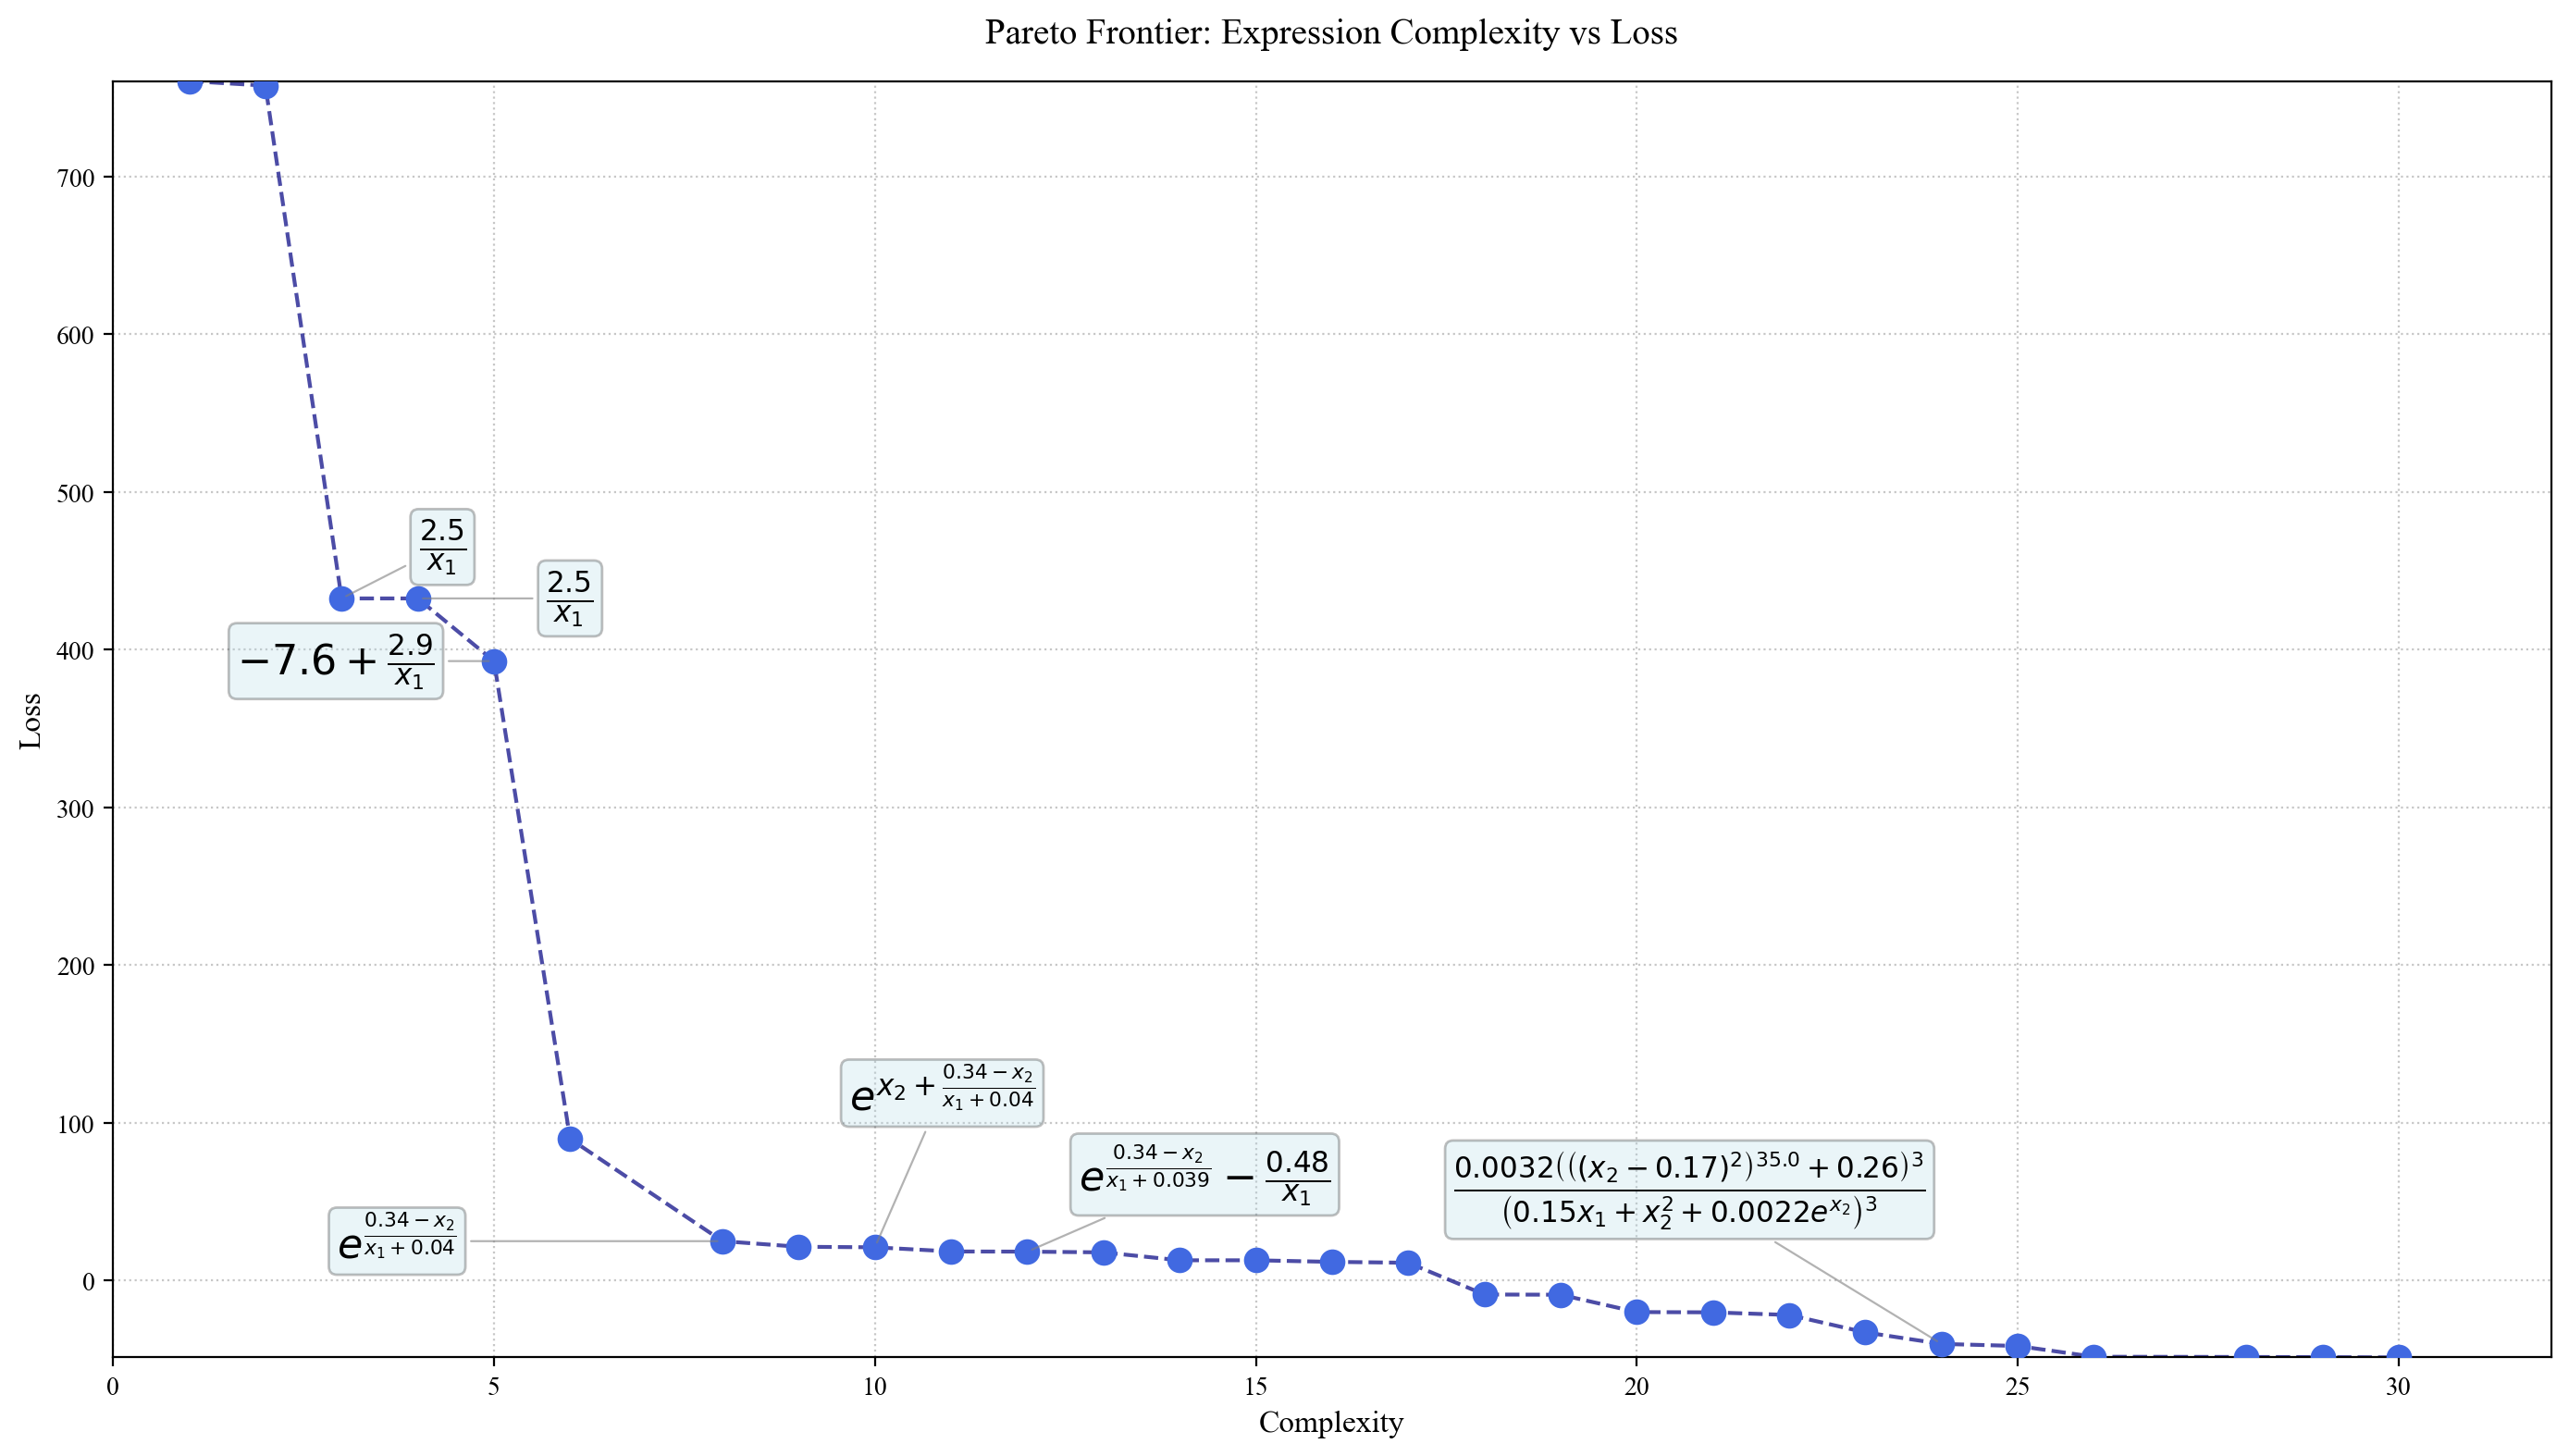

Expr 1 original: $0.88$
Expr 2 original: $e^{x_{2}}$
Expr 3 original: $\frac{2.5}{x_{1}}$
Expr 4 original: $\frac{2.5}{x_{1}}$
Expr 5 original: $-7.6 + \frac{2.9}{x_{1}}$
Expr 6 original: $\frac{0.003375}{\left(x_{1} + 0.0084\right)^{3}}$
Expr 7 original: $e^{\frac{0.34 - x_{2}}{x_{1} + 0.04}}$
Expr 8 original: $e^{\frac{\left(0.61 - x_{2}\right)^{2}}{x_{1} + 0.043}}$
Expr 9 original: $e^{x_{2} + \frac{0.34 - x_{2}}{x_{1} + 0.04}}$
Expr 10 original: $0.099 e^{\frac{\left(x_{2} - 0.8\right)^{2}}{x_{1} + 0.06}}$
Expr 11 original: $e^{\frac{0.34 - x_{2}}{x_{1} + 0.039}} - \frac{0.48}{x_{1}}$
Expr 12 original: $0.025 e^{\frac{1.3 \left(0.83 - x_{2}\right)^{2}}{x_{1} + 0.073}}$
Expr 13 original: $e^{x_{2} + \frac{0.34 - x_{2}}{x_{1} + 0.039}} - \frac{0.54}{x_{1}}$
Expr 14 original: $e^{x_{2}} e^{\frac{0.34 - x_{2}}{x_{1} + 0.039}} - \frac{0.54}{x_{1}}$
Expr 15 original: $e^{1.2 x_{2} + \frac{0.34 - x_{2}}{x_{1} + 0.039}} - \frac{0.54}{x_{1}}$
Expr 16 original: $e^{1.3 x_{2}} e^{\frac{0.34 -

In [138]:
range_of_interest = (1, 48)
indices_of_interest = [i for i, c in enumerate(complexity) if range_of_interest[0] <= c <= range_of_interest[1]]
complexity = [complexity[i] for i in indices_of_interest]
loss = [loss[i] for i in indices_of_interest]
raw_equations = [raw_equations[i] for i in indices_of_interest]

# 2) Sympy setup
x1, x2 = sp.symbols('x1 x2')

# 3) Custom function to round constants only (not function arguments)
def round_constants(expr, ndigits=1):
    """
    Round every bare Float in `expr` so that, when printed,
    it has exactly `ndigits` digits after the decimal point
    in scientific notation (i.e. nd+1 significant figures).
    """
    def _is_leaf_float(e):
        return e.is_Float and not e.args

    def _round_sci(e):
        f = float(e)
        # format with `ndigits` places after the decimal in the mantissa:
        sci_str = f"{f:.{ndigits}e}"
        return sp.Float(sci_str)

    return expr.replace(_is_leaf_float, _round_sci)

# 4) Function to convert pow2 to squared form without evaluation
def convert_pow2(expr):
    # Find all pow2 calls
    if expr.func.__name__ == 'pow2':
        return sp.Pow(convert_pow2(expr.args[0]), 2, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow2(arg) for arg in expr.args]) if expr.args else expr

def convert_pow3(expr):
    # Find all pow3 calls
    if expr.func.__name__ == 'pow3':
        return sp.Pow(convert_pow3(expr.args[0]), 3, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow3(arg) for arg in expr.args]) if expr.args else expr

def convert_pow4(expr):
    # Find all pow4 calls
    if expr.func.__name__ == 'pow4':
        return sp.Pow(convert_pow4(expr.args[0]), 4, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow4(arg) for arg in expr.args]) if expr.args else expr

def convert_pow5(expr):
    # Find all pow5 calls
    if expr.func.__name__ == 'pow5':
        return sp.Pow(convert_pow5(expr.args[0]), 5, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow5(arg) for arg in expr.args]) if expr.args else expr

# 4) Function to convert pow_int without evaluation
def convert_pow_int(expr):
    # Find all pow_int calls
    if expr.func.__name__ == 'pow_int':
        base, exp = expr.args
        # If exp is literally an integer, convert to a Python int
        if exp.is_integer and exp.is_number:
            exp = int(exp)
        # Otherwise leave exp symbolic
        return sp.Pow(convert_pow_int(base), convert_pow_int(exp), evaluate=False)

    # Recursively descend into all other function applications
    if expr.args:
        return expr.func(*[convert_pow_int(arg) for arg in expr.args])
    else:
        return expr
    
def replace_pow_functions_recursive(expr: sp.Expr) -> sp.Expr:
    """
    Recursively replaces custom functions like powN(x) with standard power notation x**N.
    E.g. pow3(x + pow2(y)) → (x + y**2)**3
    """
    # First, apply recursively to all arguments (bottom-up),
    # so that nested pow-functions inside arguments get replaced too.
    expr = expr.xreplace({})  # no-op; just ensures expr is a Basic (not strictly needed)

    # Define replacement function
    def _repl(f):
        # check it's a function call
        if not isinstance(f, sp.Function):
            return f

        name = f.func.__name__
        if not name.startswith("pow"):
            return f

        # parse N from “powN”
        try:
            N = int(name[len("pow"):])
        except ValueError:
            return f

        if len(f.args) != 1:
            # unexpected arity, leave unchanged
            return f

        base = f.args[0]
        # Recursively transform the base
        new_base = replace_pow_functions_recursive(base)
        return new_base ** N

    # Use replace with map=False (so it returns an Expr)
    new_expr = expr.replace(
        lambda x: isinstance(x, sp.Function) and x.func.__name__.startswith("pow"),
        _repl,
        map=False
    )
    return new_expr

# 5) Build MathText labels
latex_labels = []
exprs_final = []
function_ready = []
for id, s in enumerate(raw_equations):
    try:
        # Pre-process pow2 -> custom function
        s_processed = s.replace('pow2', 'pow2_func')
        s_processed = s.replace('pow3', 'pow3_func')
        s_processed = s.replace('pow4', 'pow4_func')
        s_processed = s.replace('pow5', 'pow5_func')
        s_processed = s_processed.replace('pow_int', 'pow_int_func')
        
        # Define custom functions
        locals_dict = {
            'x1': x1,
            'x2': x2,
            'pow2_func': sp.Function('pow2'),
            'pow3_func': sp.Function('pow3'),
            'pow4_func': sp.Function('pow4'),
            'pow5_func': sp.Function('pow5'),
            'pow_int_func': sp.Function('pow_int'),
            'asin': sp.asin,
            'atan': sp.atan,
            'tan': sp.tan,
            'exp': sp.exp,
        }
        
        # Parse while preserving structure
        expr = parse_expr(s_processed, evaluate=False, local_dict=locals_dict)
        
        # Convert pow2_func to squared form
        expr_converted_pow2 = convert_pow2(expr)
        expr_converted_pow3 = convert_pow3(expr)
        expr_converted_pow4 = convert_pow4(expr)
        expr_converted_pow5 = convert_pow5(expr)
        expr_converted = convert_pow_int(expr_converted_pow5)
        
        # Round constants (only standalone floats)
        expr_converted_int1 = round_constants(expr_converted)
        expr_converted_int2 = round_constants(expr_converted_int1)
        expr_final = round_constants(expr_converted_int2)
        # expr_final = expr_final.simplify()
        # expr_final = expr_final.expand()
        exprs_final.append(expr_final)

        # Get MathText-friendly LaTeX
        mt = replace_pow_functions_recursive(expr_final)
        expr_converted_int1 = round_constants(mt)
        expr_converted_int2 = round_constants(expr_converted_int1)
        mt = round_constants(expr_converted_int2)
        mt = sp.latex(mt)
        latex_labels.append(f"${mt}$")
        
        # Replace 'exp' with 'np.exp'
        modified_expression = s.replace('exp', 'np.exp')
    
        # Replace 'log' with 'np.log'
        modified_expression = modified_expression.replace('log', 'np.log')
        function_ready.append(modified_expression)
        # Debug print
        print(f"Original at complexity {complexity[id]}: {s}")
        print(f"function_ready: {modified_expression}")
        print(f"Processed: {expr_final}")
        print(f"LaTeX: {mt}\n")
    except Exception as e:
        print(f"Error processing expression: {s}\n{e}")
        latex_labels.append(f"Error: {s}")

# 6) Manual offsets for clarity
offsets = [
    (0, 0), (0, 0), (30, 20), (50, 0), (-100, 0),
    (0, 0), (-150, 0), (0, 0), (-10, 60), (0, 0),
    (20, 30), (0, 0), (0, 0), (0, 0), (0, 0),
    (0, 0), (0, 0), (0, 0), (0, 0), (0, 0),
    (0, 0), (0, 0), (-190, 60), (0, 0), (0, 0),
]

# 7) Plot
fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(complexity, loss, s=80, zorder=3, color='royalblue')
ax.plot(complexity, loss, linestyle='--', alpha=0.7, zorder=2, color='navy')

# Set axis limits
ax.set_xlim(min(complexity) - 1, max(complexity) + 2)
ax.set_ylim(min(loss) - 0.0005, max(loss))
fig.subplots_adjust(right=0.75)


skip_indices = []
keep_indices = [3-1, 4-1, 5-1, 7-1, 9-1, 11-1, 23-1]
# Annotate with MathText labels
for i, (x, y, lbl, (dx, dy)) in enumerate(zip(complexity, loss, latex_labels, offsets)):
    if i in skip_indices or (i not in keep_indices):
        continue
    ax.annotate(
        lbl,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=16,
        bbox=dict(boxstyle='round,pad=0.2', alpha=0.25, fc='lightblue'),
        arrowprops=dict(arrowstyle='-', lw=0.8, alpha=0.6, color='gray')
    )

ax.set_title("Pareto Frontier: Expression Complexity vs Loss", fontsize=14, pad=15)
ax.set_xlabel("Complexity", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.show()
# Explicitly close the figure object
plt.close() 
# Force the Python garbage collector to clean up memory
gc.collect()

#######################################
import re
from math import log10, floor
def clean_latex(latex_str, sigfigs=3):
    # --- Fix subscripts first (handle trailing zeros) ---
    latex_str = re.sub(r"x_\{1\.0+\}", "x_1", latex_str)
    latex_str = re.sub(r"x_\{2\.0+\}", "x_2", latex_str)

    # --- Fix powers like ^{2.0} -> ^2 (handles 2.0, 2.00, etc.) ---
    latex_str = re.sub(r"\^\{(\d+)\.0+\}", r"^\1", latex_str)

    # --- Round numeric literals not part of x_{...} or ^{...} ---
    def round_number(m):
        s = m.group(0)
        f = float(s)
        if f == 0:
            return "0"
        exp = floor(log10(abs(f)))
        rounded = round(f, sigfigs - 1 - exp)

        # If rounded is integer-valued, print as integer (no trailing .0)
        if abs(rounded - int(rounded)) < 1e-12:
            return str(int(rounded))

        # Otherwise print normal decimal unless scientific notation is needed
        if 1e-3 <= abs(rounded) < 1e4:
            return str(rounded)
        return f"{rounded:.{sigfigs-1}e}"

    # Negative lookbehinds:
    #  - (?<!x_\{) prevents matching digits inside x_{...}
    #  - (?<!\^\{) prevents matching digits inside ^{...} (exponents)
    number_pattern = re.compile(r"(?<!x_\{)(?<!\^\{)\d*\.?\d+(?:[eE][-+]?\d+)?")
    latex_str = number_pattern.sub(round_number, latex_str)

    return latex_str


# --- after your existing code that builds exprs_final ---

# 1) Simplify each expression
simplified_exprs = [sp.simplify(expr) for expr in exprs_final]
# rounded_simplified_exprs = [round_constants(expr) for expr in simplified_exprs]
# rounded_simplified_exprs = [round_constants(expr) for expr in rounded_simplified_exprs]

# 2) Print them in LaTeX form
for i, expr in enumerate(exprs_final, 1):
    mt = replace_pow_functions_recursive(expr)
    latex_str = sp.latex(mt)
    print(f"Expr {i} original: ${latex_str}$")


print("\n--- Simplified Expressions ---\n")
# 2) Print them in LaTeX form
for i, expr in enumerate(simplified_exprs, 1):
    mt = replace_pow_functions_recursive(expr)
    latex_str = sp.latex(mt)
    latex_str = clean_latex(latex_str, sigfigs=2)
    print(f"complexity {complexity[i-1]} simplified: ${latex_str}$")

In [139]:
predicted_functions_hybrid = [eval(f'lambda x1, x2: {str_func}', {'np':np, 'pow2':pow2, 'pow3':pow3, 'pow4':pow4, 'pow5':pow5}) for str_func in function_ready]
masked_functions_hybrid = [
    (lambda f: lambda x1, x2, mask: np.where(mask, 0, f(x1, x2)))(f)
    for f in predicted_functions_hybrid
]

In [140]:
log_likelihood_scores_hybrid = log_likelihood_scores
complexity_hybrid = complexity

In [141]:
file_path_mse = "data/pareto_results/dijet_neural_results.py"
exec(open(file_path_mse).read())

Original at complexity 1: 0.8233243305586407
function_ready: 0.8233243305586407
Processed: 0.820000000000000
LaTeX: 0.82

Original at complexity 2: log(2.278051681158995)
function_ready: np.log(2.278051681158995)
Processed: 0.820000000000000
LaTeX: 0.82

Original at complexity 3: 2.5211225918266487 / x1
function_ready: 2.5211225918266487 / x1
Processed: 2.5/x1
LaTeX: \frac{2.5}{x_{1}}

Original at complexity 4: pow3(1.3604589304236097) / x1
function_ready: pow3(1.3604589304236097) / x1
Processed: pow3(1.4)/x1
LaTeX: \frac{2.7}{x_{1}}

Original at complexity 5: (2.929834105591473 / x1) + -7.566502029141336
function_ready: (2.929834105591473 / x1) + -7.566502029141336
Processed: -7.6 + 2.9/x1
LaTeX: -7.6 + \frac{2.9}{x_{1}}

Original at complexity 6: pow3(0.14318738691156752 / (x1 + 0.007840907305470437))
function_ready: pow3(0.14318738691156752 / (x1 + 0.007840907305470437))
Processed: pow3(0.14/(x1 + 0.0078))
LaTeX: \frac{0.0027}{\left(x_{1} + 0.0078\right)^{3}}

Original at complexity

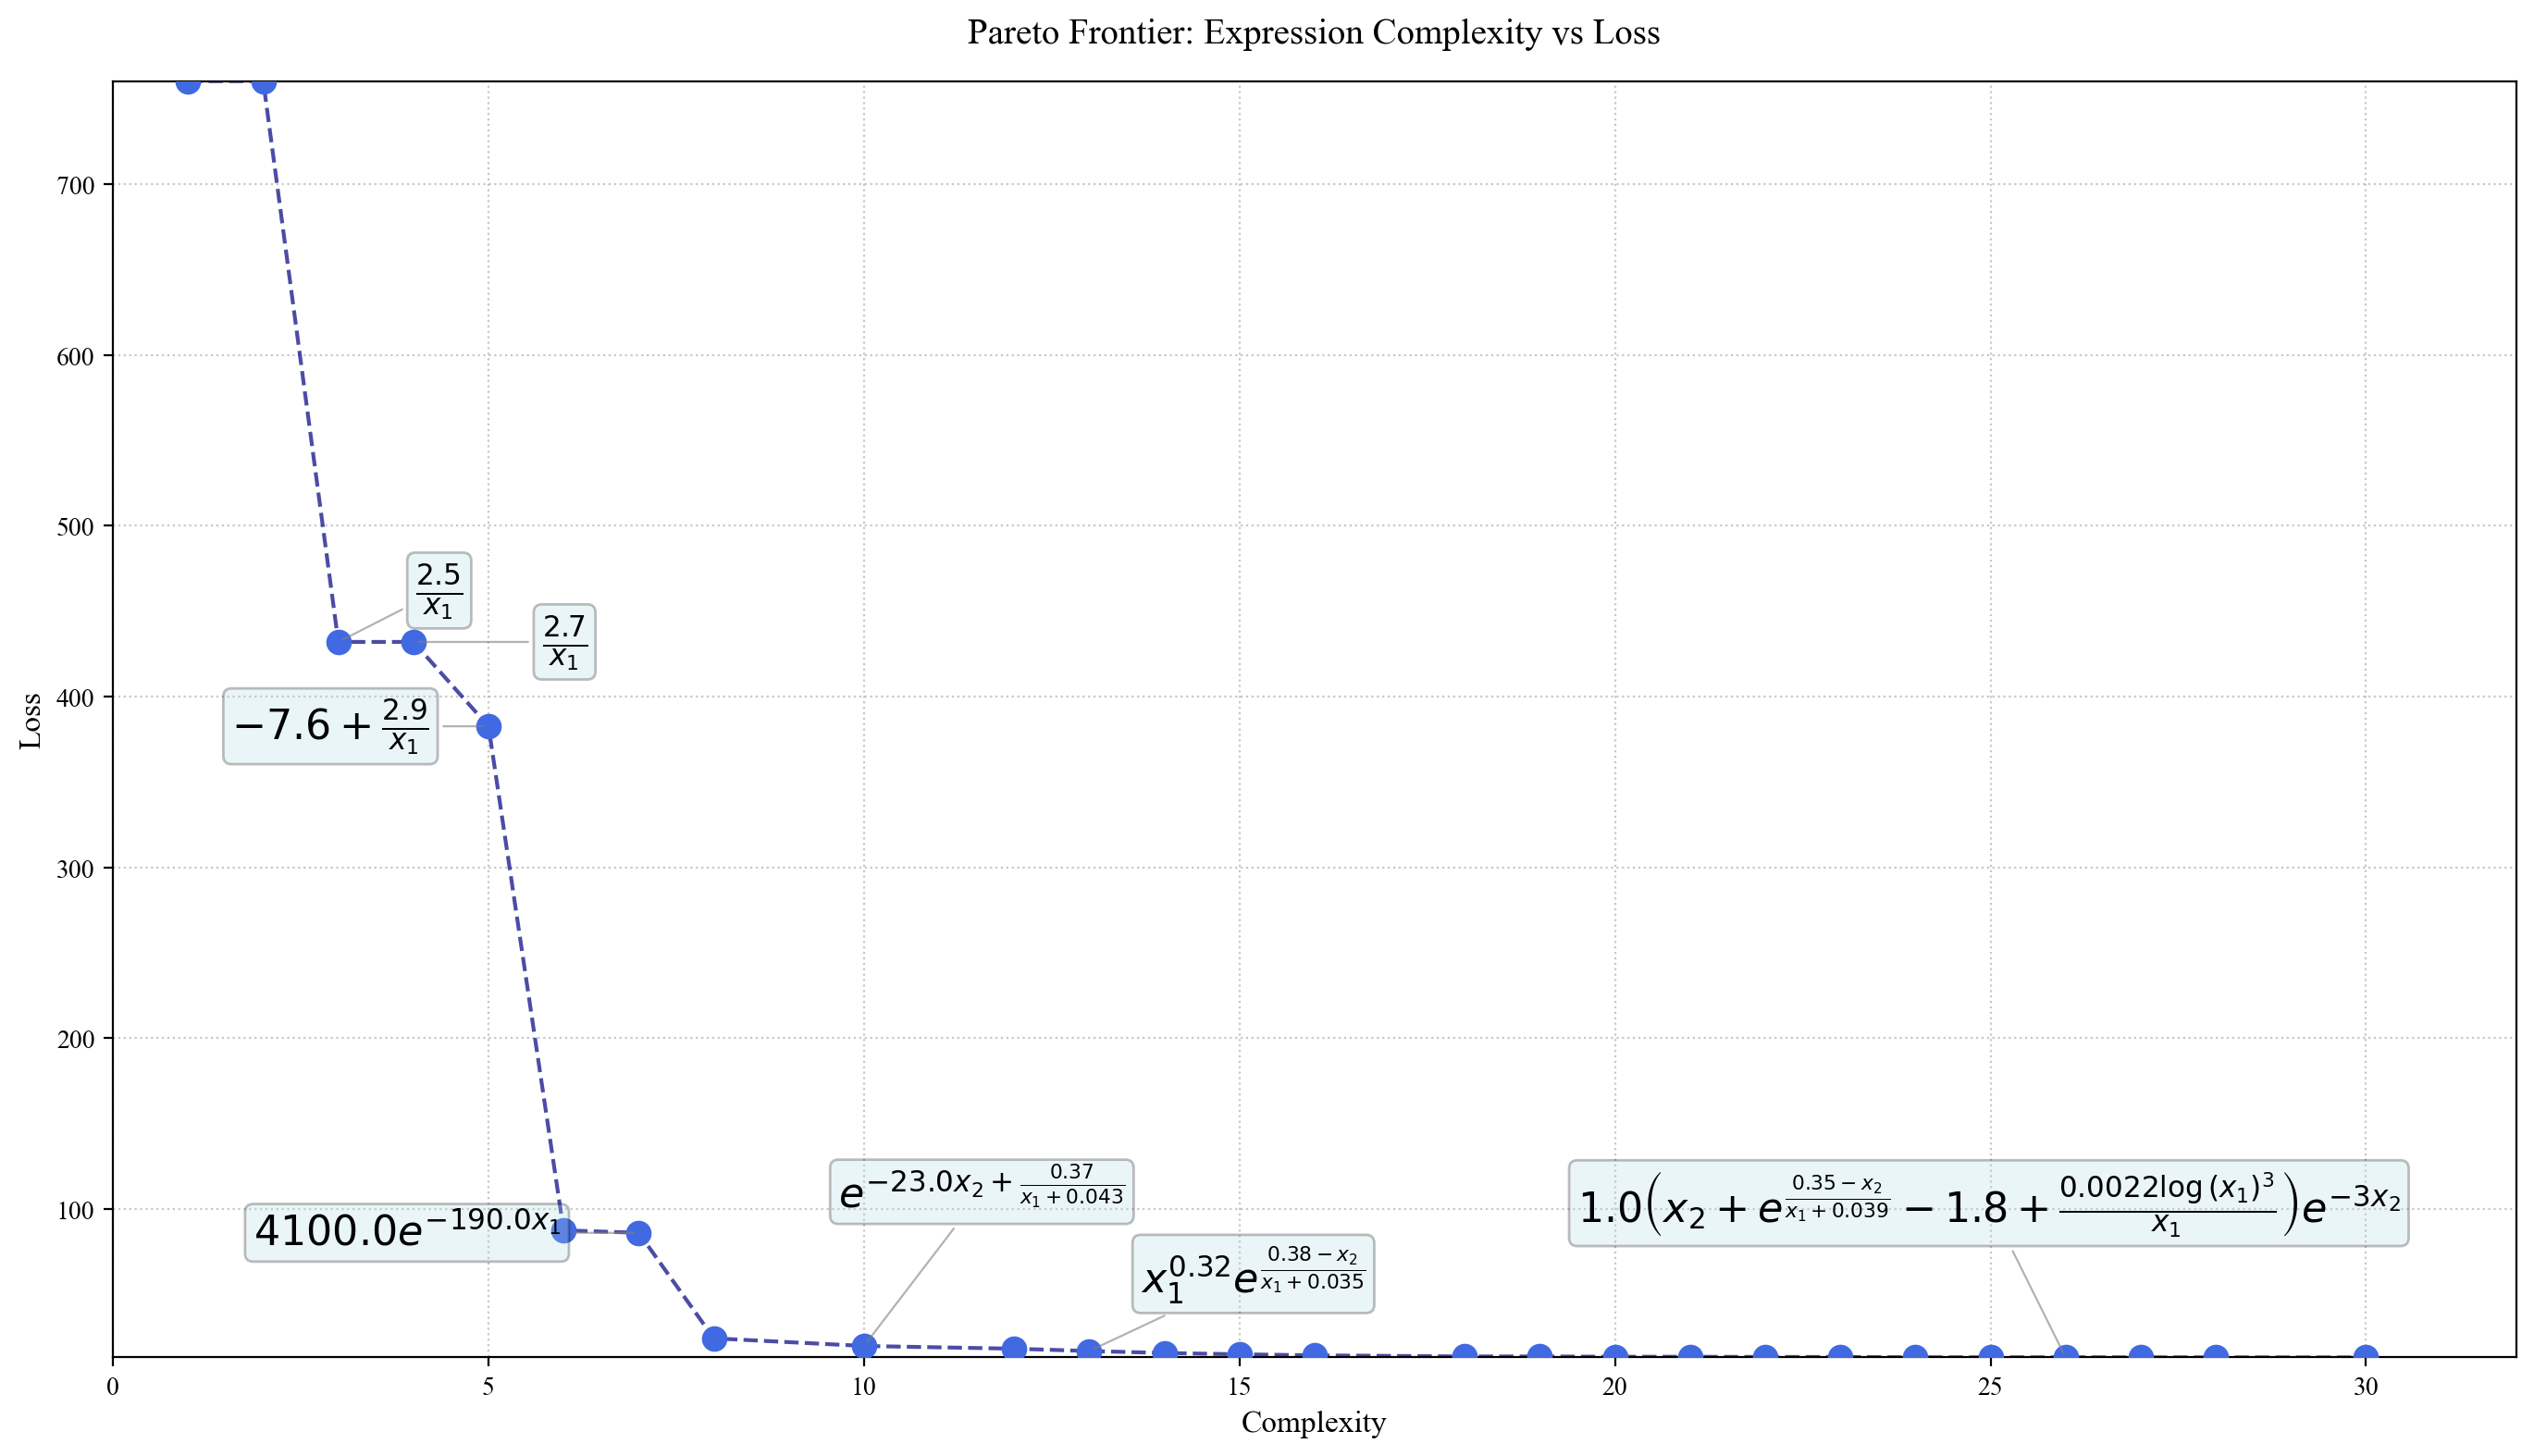

Expr 1 original: $0.82$
Expr 2 original: $0.82$
Expr 3 original: $\frac{2.5}{x_{1}}$
Expr 4 original: $\frac{2.744}{x_{1}}$
Expr 5 original: $-7.6 + \frac{2.9}{x_{1}}$
Expr 6 original: $\frac{0.002744}{\left(x_{1} + 0.0078\right)^{3}}$
Expr 7 original: $4100.0 e^{- 189.0 x_{1}}$
Expr 8 original: $e^{\frac{0.34 - x_{2}}{x_{1} + 0.04}}$
Expr 9 original: $e^{- 23.0 x_{2} + \frac{0.37}{x_{1} + 0.043}}$
Expr 10 original: $e^{\frac{0.35 - x_{2}}{x_{1} + 0.04}} - \frac{0.42}{x_{1}}$
Expr 11 original: $x_{1}^{0.32} e^{\frac{0.38 - x_{2}}{x_{1} + 0.035}}$
Expr 12 original: $e^{\frac{0.35 - x_{2}}{x_{1} + 0.04}} + \frac{x_{2} - 0.74}{x_{1}}$
Expr 13 original: $e^{\frac{0.35 - x_{2}}{x_{1} + 0.039}} + \frac{0.14 \log{\left(x_{1} \right)}}{x_{1}}$
Expr 14 original: $e^{\frac{0.32 - x_{2}}{x_{1} + 0.037}} + \frac{0.002197 \log{\left(x_{1} \right)}^{3}}{x_{1}}$
Expr 15 original: $e^{\frac{0.32 - x_{2}}{x_{1} + 0.037}} - 0.8 + \frac{0.002197 \log{\left(x_{1} \right)}^{3}}{x_{1}}$
Expr 16 original: $e

In [142]:
range_of_interest = (1, 48)
indices_of_interest = [i for i, c in enumerate(complexity) if range_of_interest[0] <= c <= range_of_interest[1]]
complexity = [complexity[i] for i in indices_of_interest]
loss = [loss[i] for i in indices_of_interest]
raw_equations = [raw_equations[i] for i in indices_of_interest]

# 2) Sympy setup
x1, x2 = sp.symbols('x1 x2')

# 3) Custom function to round constants only (not function arguments)
def round_constants(expr, ndigits=1):
    """
    Round every bare Float in `expr` so that, when printed,
    it has exactly `ndigits` digits after the decimal point
    in scientific notation (i.e. nd+1 significant figures).
    """
    def _is_leaf_float(e):
        return e.is_Float and not e.args

    def _round_sci(e):
        f = float(e)
        # format with `ndigits` places after the decimal in the mantissa:
        sci_str = f"{f:.{ndigits}e}"
        return sp.Float(sci_str)

    return expr.replace(_is_leaf_float, _round_sci)

# 4) Function to convert pow2 to squared form without evaluation
def convert_pow2(expr):
    # Find all pow2 calls
    if expr.func.__name__ == 'pow2':
        return sp.Pow(convert_pow2(expr.args[0]), 2, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow2(arg) for arg in expr.args]) if expr.args else expr

def convert_pow3(expr):
    # Find all pow3 calls
    if expr.func.__name__ == 'pow3':
        return sp.Pow(convert_pow3(expr.args[0]), 3, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow3(arg) for arg in expr.args]) if expr.args else expr

def convert_pow4(expr):
    # Find all pow4 calls
    if expr.func.__name__ == 'pow4':
        return sp.Pow(convert_pow4(expr.args[0]), 4, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow4(arg) for arg in expr.args]) if expr.args else expr

def convert_pow5(expr):
    # Find all pow5 calls
    if expr.func.__name__ == 'pow5':
        return sp.Pow(convert_pow5(expr.args[0]), 5, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow5(arg) for arg in expr.args]) if expr.args else expr

# 4) Function to convert pow_int without evaluation
def convert_pow_int(expr):
    # Find all pow_int calls
    if expr.func.__name__ == 'pow_int':
        base, exp = expr.args
        # If exp is literally an integer, convert to a Python int
        if exp.is_integer and exp.is_number:
            exp = int(exp)
        # Otherwise leave exp symbolic
        return sp.Pow(convert_pow_int(base), convert_pow_int(exp), evaluate=False)

    # Recursively descend into all other function applications
    if expr.args:
        return expr.func(*[convert_pow_int(arg) for arg in expr.args])
    else:
        return expr
    
def replace_pow_functions_recursive(expr: sp.Expr) -> sp.Expr:
    """
    Recursively replaces custom functions like powN(x) with standard power notation x**N.
    E.g. pow3(x + pow2(y)) → (x + y**2)**3
    """
    # First, apply recursively to all arguments (bottom-up),
    # so that nested pow-functions inside arguments get replaced too.
    expr = expr.xreplace({})  # no-op; just ensures expr is a Basic (not strictly needed)

    # Define replacement function
    def _repl(f):
        # check it's a function call
        if not isinstance(f, sp.Function):
            return f

        name = f.func.__name__
        if not name.startswith("pow"):
            return f

        # parse N from “powN”
        try:
            N = int(name[len("pow"):])
        except ValueError:
            return f

        if len(f.args) != 1:
            # unexpected arity, leave unchanged
            return f

        base = f.args[0]
        # Recursively transform the base
        new_base = replace_pow_functions_recursive(base)
        return new_base ** N

    # Use replace with map=False (so it returns an Expr)
    new_expr = expr.replace(
        lambda x: isinstance(x, sp.Function) and x.func.__name__.startswith("pow"),
        _repl,
        map=False
    )
    return new_expr

# 5) Build MathText labels
latex_labels = []
exprs_final = []
function_ready = []
for id, s in enumerate(raw_equations):
    try:
        # Pre-process pow2 -> custom function
        s_processed = s.replace('pow2', 'pow2_func')
        s_processed = s.replace('pow3', 'pow3_func')
        s_processed = s.replace('pow4', 'pow4_func')
        s_processed = s.replace('pow5', 'pow5_func')
        s_processed = s_processed.replace('pow_int', 'pow_int_func')
        
        # Define custom functions
        locals_dict = {
            'x1': x1,
            'x2': x2,
            'pow2_func': sp.Function('pow2'),
            'pow3_func': sp.Function('pow3'),
            'pow4_func': sp.Function('pow4'),
            'pow5_func': sp.Function('pow5'),
            'pow_int_func': sp.Function('pow_int'),
            'asin': sp.asin,
            'atan': sp.atan,
            'tan': sp.tan,
            'exp': sp.exp,
        }
        
        # Parse while preserving structure
        expr = parse_expr(s_processed, evaluate=False, local_dict=locals_dict)
        
        # Convert pow2_func to squared form
        expr_converted_pow2 = convert_pow2(expr)
        expr_converted_pow3 = convert_pow3(expr)
        expr_converted_pow4 = convert_pow4(expr)
        expr_converted_pow5 = convert_pow5(expr)
        expr_converted = convert_pow_int(expr_converted_pow5)
        
        # Round constants (only standalone floats)
        expr_converted_int1 = round_constants(expr_converted)
        expr_converted_int2 = round_constants(expr_converted_int1)
        expr_final = round_constants(expr_converted_int2)
        # expr_final = expr_final.simplify()
        # expr_final = expr_final.expand()
        exprs_final.append(expr_final)

        # Get MathText-friendly LaTeX
        mt = replace_pow_functions_recursive(expr_final)
        expr_converted_int1 = round_constants(mt)
        expr_converted_int2 = round_constants(expr_converted_int1)
        mt = round_constants(expr_converted_int2)
        mt = sp.latex(mt)
        latex_labels.append(f"${mt}$")
        
        # Replace 'exp' with 'np.exp'
        modified_expression = s.replace('exp', 'np.exp')
    
        # Replace 'log' with 'np.log'
        modified_expression = modified_expression.replace('log', 'np.log')
        function_ready.append(modified_expression)
        # Debug print
        print(f"Original at complexity {complexity[id]}: {s}")
        print(f"function_ready: {modified_expression}")
        print(f"Processed: {expr_final}")
        print(f"LaTeX: {mt}\n")
    except Exception as e:
        print(f"Error processing expression: {s}\n{e}")
        latex_labels.append(f"Error: {s}")

# 6) Manual offsets for clarity
offsets = [
    (0, 0), (0, 0), (30, 20), (50, 0), (-100, 0),
    (0, 0), (-150, 0), (0, 0), (-10, 60), (0, 0),
    (20, 30), (0, 0), (0, 0), (0, 0), (0, 0),
    (0, 0), (0, 0), (0, 0), (0, 0), (0, 0),
    (0, 0), (0, 0), (-190, 60), (0, 0), (0, 0),
]

# 7) Plot
fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(complexity, loss, s=80, zorder=3, color='royalblue')
ax.plot(complexity, loss, linestyle='--', alpha=0.7, zorder=2, color='navy')

# Set axis limits
ax.set_xlim(min(complexity) - 1, max(complexity) + 2)
ax.set_ylim(min(loss) - 0.0005, max(loss))
fig.subplots_adjust(right=0.75)


skip_indices = []
keep_indices = [3-1, 4-1, 5-1, 7-1, 9-1, 11-1, 23-1]
# Annotate with MathText labels
for i, (x, y, lbl, (dx, dy)) in enumerate(zip(complexity, loss, latex_labels, offsets)):
    if i in skip_indices or (i not in keep_indices):
        continue
    ax.annotate(
        lbl,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=16,
        bbox=dict(boxstyle='round,pad=0.2', alpha=0.25, fc='lightblue'),
        arrowprops=dict(arrowstyle='-', lw=0.8, alpha=0.6, color='gray')
    )

ax.set_title("Pareto Frontier: Expression Complexity vs Loss", fontsize=14, pad=15)
ax.set_xlabel("Complexity", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.show()
# Explicitly close the figure object
plt.close() 
# Force the Python garbage collector to clean up memory
gc.collect()

#######################################
import re
from math import log10, floor
def clean_latex(latex_str, sigfigs=3):
    # --- Fix subscripts first (handle trailing zeros) ---
    latex_str = re.sub(r"x_\{1\.0+\}", "x_1", latex_str)
    latex_str = re.sub(r"x_\{2\.0+\}", "x_2", latex_str)

    # --- Fix powers like ^{2.0} -> ^2 (handles 2.0, 2.00, etc.) ---
    latex_str = re.sub(r"\^\{(\d+)\.0+\}", r"^\1", latex_str)

    # --- Round numeric literals not part of x_{...} or ^{...} ---
    def round_number(m):
        s = m.group(0)
        f = float(s)
        if f == 0:
            return "0"
        exp = floor(log10(abs(f)))
        rounded = round(f, sigfigs - 1 - exp)

        # If rounded is integer-valued, print as integer (no trailing .0)
        if abs(rounded - int(rounded)) < 1e-12:
            return str(int(rounded))

        # Otherwise print normal decimal unless scientific notation is needed
        if 1e-3 <= abs(rounded) < 1e4:
            return str(rounded)
        return f"{rounded:.{sigfigs-1}e}"

    # Negative lookbehinds:
    #  - (?<!x_\{) prevents matching digits inside x_{...}
    #  - (?<!\^\{) prevents matching digits inside ^{...} (exponents)
    number_pattern = re.compile(r"(?<!x_\{)(?<!\^\{)\d*\.?\d+(?:[eE][-+]?\d+)?")
    latex_str = number_pattern.sub(round_number, latex_str)

    return latex_str


# --- after your existing code that builds exprs_final ---

# 1) Simplify each expression
simplified_exprs = [sp.simplify(expr) for expr in exprs_final]
# rounded_simplified_exprs = [round_constants(expr) for expr in simplified_exprs]
# rounded_simplified_exprs = [round_constants(expr) for expr in rounded_simplified_exprs]

# 2) Print them in LaTeX form
for i, expr in enumerate(exprs_final, 1):
    mt = replace_pow_functions_recursive(expr)
    latex_str = sp.latex(mt)
    print(f"Expr {i} original: ${latex_str}$")


print("\n--- Simplified Expressions ---\n")
# 2) Print them in LaTeX form
for i, expr in enumerate(simplified_exprs, 1):
    mt = replace_pow_functions_recursive(expr)
    latex_str = sp.latex(mt)
    latex_str = clean_latex(latex_str, sigfigs=2)
    print(f"complexity {complexity[i-1]} simplified: ${latex_str}$")

In [143]:
predicted_functions_mse = [eval(f'lambda x1, x2: {str_func}', {'np':np, 'pow2':pow2, 'pow3':pow3, 'pow4':pow4, 'pow5':pow5}) for str_func in function_ready]
masked_functions_mse = [
    (lambda f: lambda x1, x2, mask: np.where(mask, 0, f(x1, x2)))(f)
    for f in predicted_functions_mse
]
# mask = (grids[1] > 7 * grids[0]) | (grids[1] < 0)

In [144]:
log_likelihood_scores_mse = log_likelihood_scores
complexity_mse = complexity

In [145]:
file_path_hybridhard = "data/pareto_results/dijet_hybrid_hardpenalty_neural_results.py"
exec(open(file_path_hybridhard).read())

Original at complexity 1: 0.8801645373056243
function_ready: 0.8801645373056243
Processed: 0.880000000000000
LaTeX: 0.88

Original at complexity 2: exp(x2)
function_ready: np.exp(x2)
Processed: exp(x2)
LaTeX: e^{x_{2}}

Original at complexity 3: 2.520120076580098 / x1
function_ready: 2.520120076580098 / x1
Processed: 2.5/x1
LaTeX: \frac{2.5}{x_{1}}

Original at complexity 5: -0.00046269385776301255 + (2.520120076580098 / x1)
function_ready: -0.00046269385776301255 + (2.520120076580098 / x1)
Processed: -0.00046 + 2.5/x1
LaTeX: -0.00046 + \frac{2.5}{x_{1}}

Original at complexity 6: pow3(0.13673873733652592 / (x1 - -0.00757720304403706))
function_ready: pow3(0.13673873733652592 / (x1 - -0.00757720304403706))
Processed: pow3(0.14/(x1 + 0.0076))
LaTeX: \frac{0.0027}{\left(x_{1} + 0.0076\right)^{3}}

Original at complexity 7: exp(pow2(0.1690014061241114 / (x1 - -0.057731874172535474)))
function_ready: np.exp(pow2(0.1690014061241114 / (x1 - -0.057731874172535474)))
Processed: exp(pow2(0.17/(

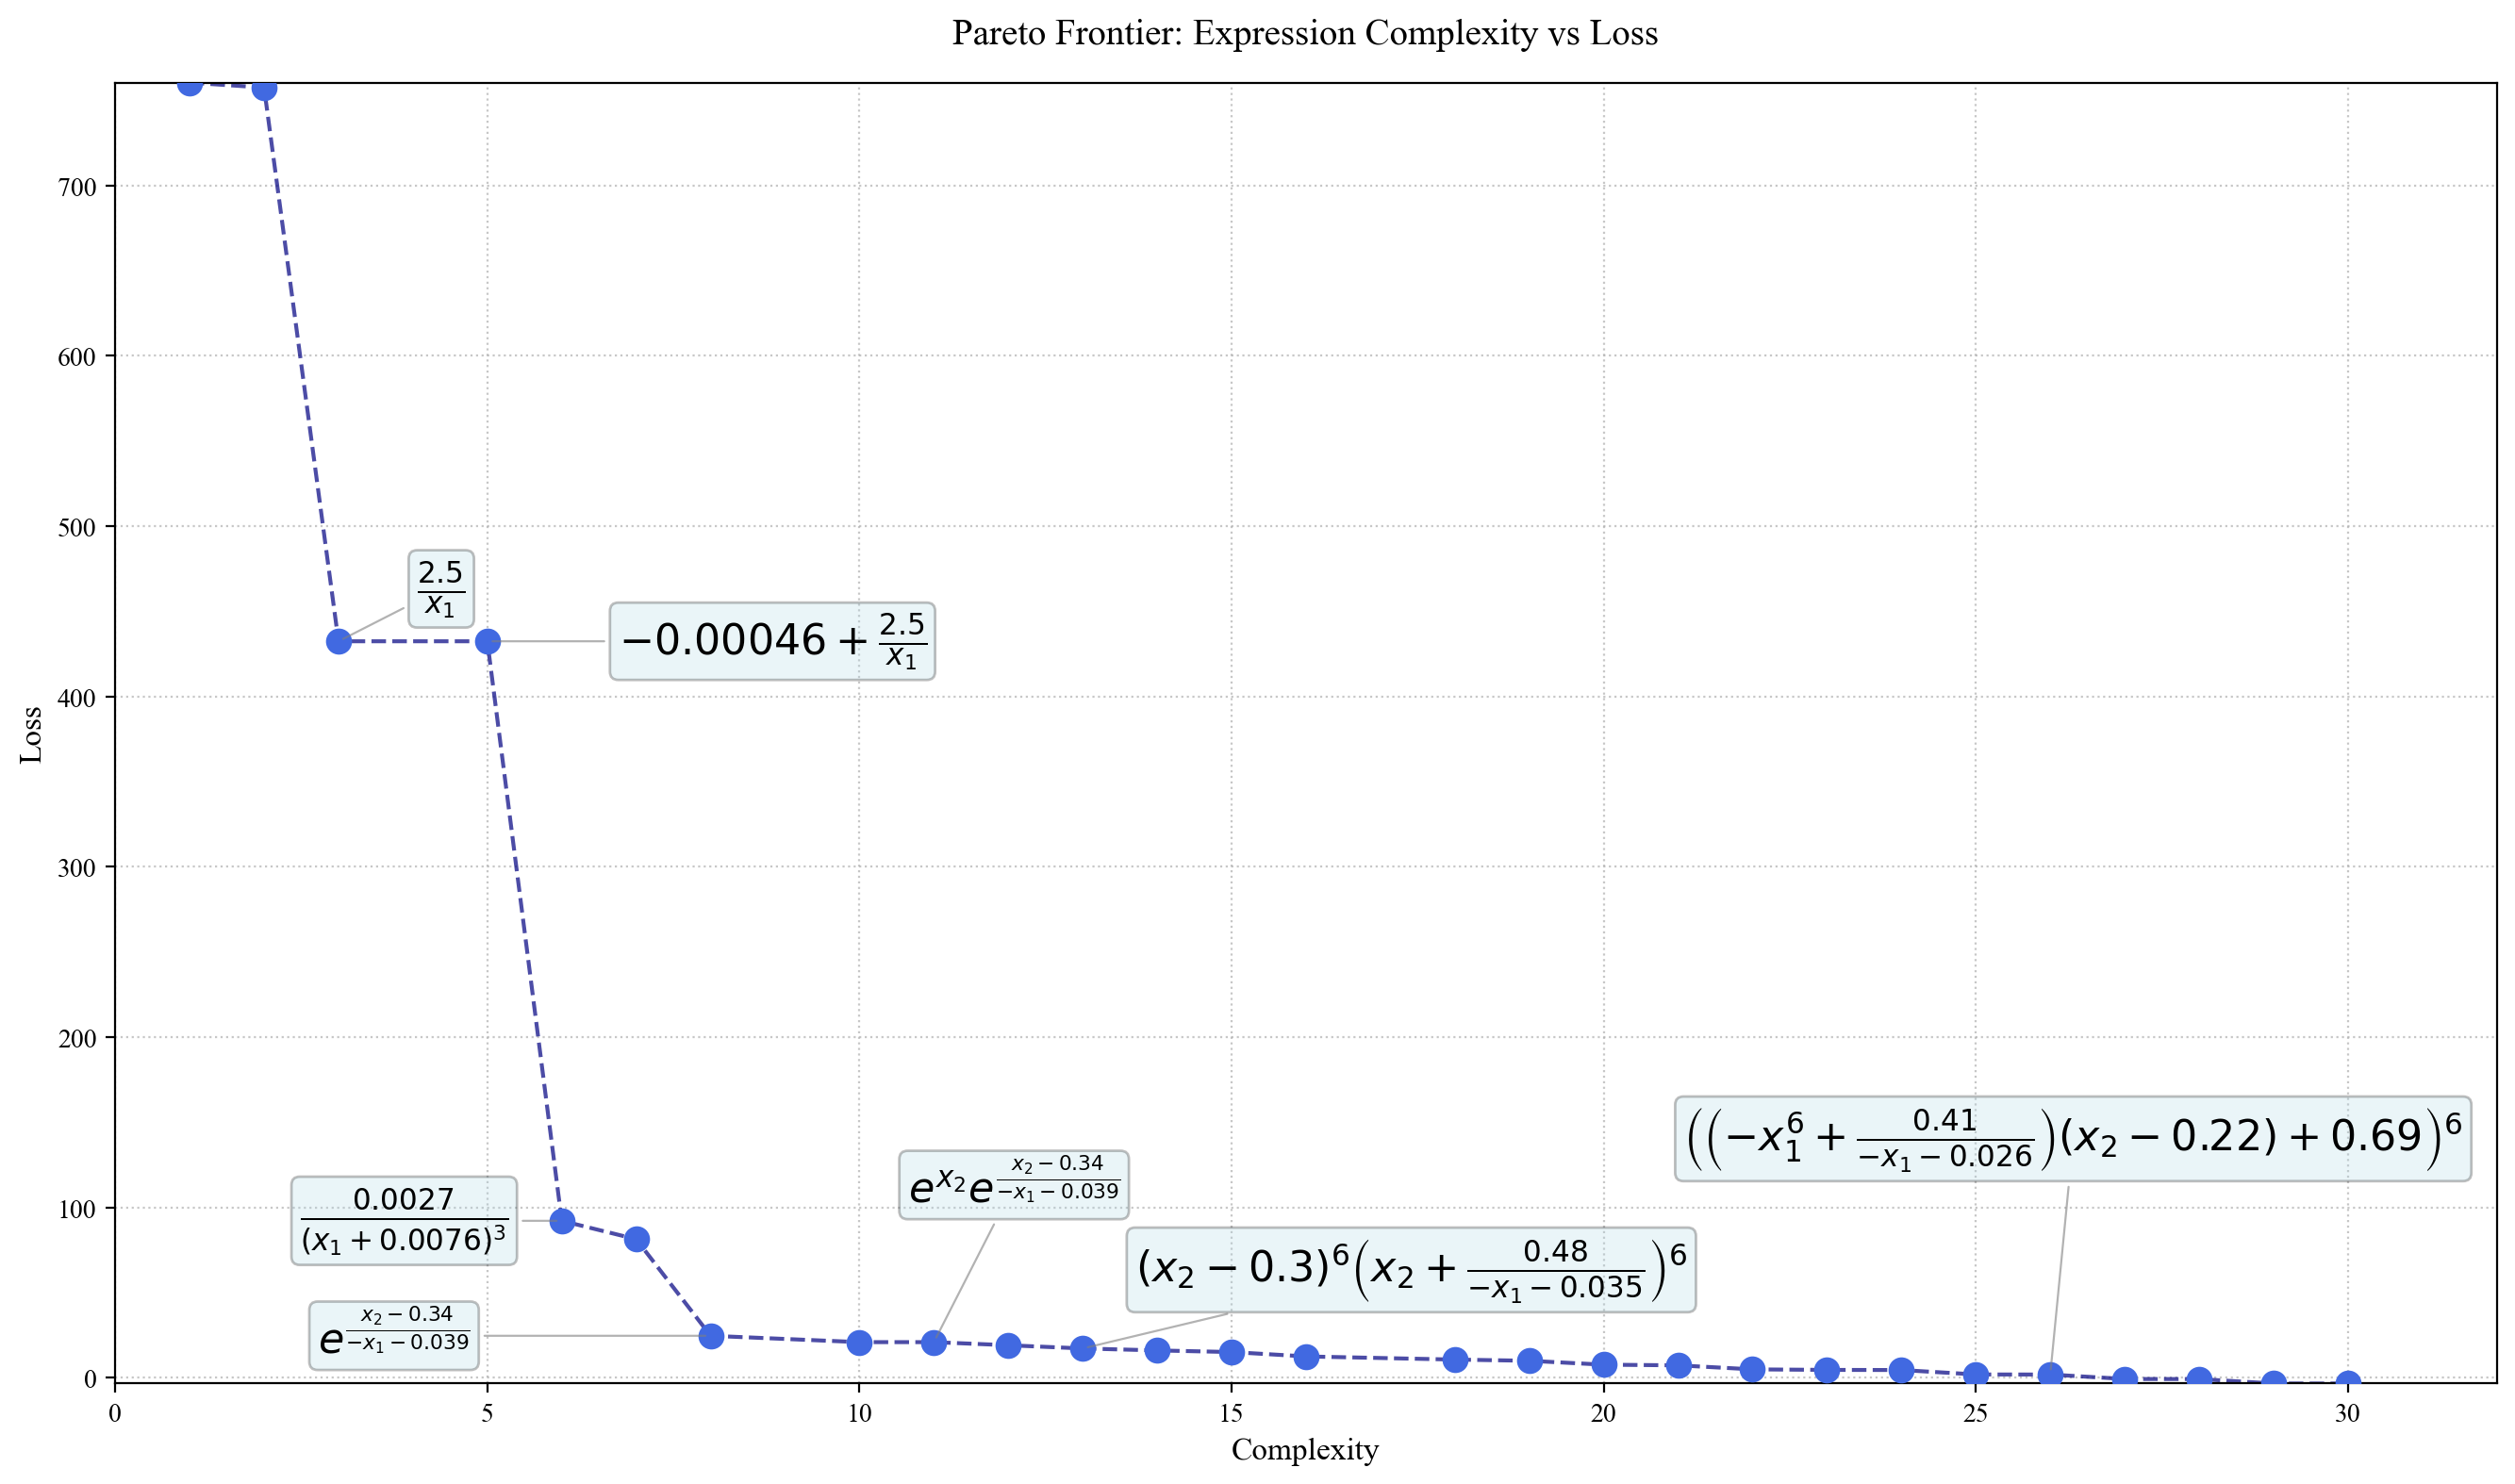

Expr 1 original: $0.88$
Expr 2 original: $e^{x_{2}}$
Expr 3 original: $\frac{2.5}{x_{1}}$
Expr 4 original: $-0.00046 + \frac{2.5}{x_{1}}$
Expr 5 original: $\frac{0.002744}{\left(x_{1} + 0.0076\right)^{3}}$
Expr 6 original: $e^{\frac{0.0289}{\left(x_{1} + 0.058\right)^{2}}}$
Expr 7 original: $e^{\frac{x_{2} - 0.34}{- x_{1} - 0.039}}$
Expr 8 original: $e^{x_{2} + \frac{x_{2} - 0.34}{- x_{1} - 0.039}}$
Expr 9 original: $e^{x_{2}} e^{\frac{x_{2} - 0.34}{- x_{1} - 0.039}}$
Expr 10 original: $e^{x_{2} + \frac{x_{2} - 0.34}{- x_{1} - 0.039}} - 1.3$
Expr 11 original: $\left(x_{2} - 0.3\right)^{6} \left(x_{2} + \frac{0.48}{- x_{1} - 0.035}\right)^{6}$
Expr 12 original: $e^{x_{2} + \frac{x_{2} - 0.34}{- x_{1} - 0.039}} - \frac{0.23}{x_{1}}$
Expr 13 original: $\left(x_{2} - 0.3\right)^{6} \left(x_{2}^{2} + \frac{0.48}{- x_{1} - 0.035}\right)^{6}$
Expr 14 original: $\left(x_{2} - 0.3\right)^{6} \left(x_{2} + \frac{0.48}{- x_{1} - 0.035}\right)^{6} e^{x_{2}}$
Expr 15 original: $\left(x_{2} - 0.29\r

In [146]:
range_of_interest = (1, 48)
indices_of_interest = [i for i, c in enumerate(complexity) if range_of_interest[0] <= c <= range_of_interest[1]]
complexity = [complexity[i] for i in indices_of_interest]
loss = [loss[i] for i in indices_of_interest]
raw_equations = [raw_equations[i] for i in indices_of_interest]

# 2) Sympy setup
x1, x2 = sp.symbols('x1 x2')

# 3) Custom function to round constants only (not function arguments)
def round_constants(expr, ndigits=1):
    """
    Round every bare Float in `expr` so that, when printed,
    it has exactly `ndigits` digits after the decimal point
    in scientific notation (i.e. nd+1 significant figures).
    """
    def _is_leaf_float(e):
        return e.is_Float and not e.args

    def _round_sci(e):
        f = float(e)
        # format with `ndigits` places after the decimal in the mantissa:
        sci_str = f"{f:.{ndigits}e}"
        return sp.Float(sci_str)

    return expr.replace(_is_leaf_float, _round_sci)

# 4) Function to convert pow2 to squared form without evaluation
def convert_pow2(expr):
    # Find all pow2 calls
    if expr.func.__name__ == 'pow2':
        return sp.Pow(convert_pow2(expr.args[0]), 2, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow2(arg) for arg in expr.args]) if expr.args else expr

def convert_pow3(expr):
    # Find all pow3 calls
    if expr.func.__name__ == 'pow3':
        return sp.Pow(convert_pow3(expr.args[0]), 3, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow3(arg) for arg in expr.args]) if expr.args else expr

def convert_pow4(expr):
    # Find all pow4 calls
    if expr.func.__name__ == 'pow4':
        return sp.Pow(convert_pow4(expr.args[0]), 4, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow4(arg) for arg in expr.args]) if expr.args else expr

def convert_pow5(expr):
    # Find all pow5 calls
    if expr.func.__name__ == 'pow5':
        return sp.Pow(convert_pow5(expr.args[0]), 5, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow5(arg) for arg in expr.args]) if expr.args else expr

# 4) Function to convert pow_int without evaluation
def convert_pow_int(expr):
    # Find all pow_int calls
    if expr.func.__name__ == 'pow_int':
        base, exp = expr.args
        # If exp is literally an integer, convert to a Python int
        if exp.is_integer and exp.is_number:
            exp = int(exp)
        # Otherwise leave exp symbolic
        return sp.Pow(convert_pow_int(base), convert_pow_int(exp), evaluate=False)

    # Recursively descend into all other function applications
    if expr.args:
        return expr.func(*[convert_pow_int(arg) for arg in expr.args])
    else:
        return expr
    
def replace_pow_functions_recursive(expr: sp.Expr) -> sp.Expr:
    """
    Recursively replaces custom functions like powN(x) with standard power notation x**N.
    E.g. pow3(x + pow2(y)) → (x + y**2)**3
    """
    # First, apply recursively to all arguments (bottom-up),
    # so that nested pow-functions inside arguments get replaced too.
    expr = expr.xreplace({})  # no-op; just ensures expr is a Basic (not strictly needed)

    # Define replacement function
    def _repl(f):
        # check it's a function call
        if not isinstance(f, sp.Function):
            return f

        name = f.func.__name__
        if not name.startswith("pow"):
            return f

        # parse N from “powN”
        try:
            N = int(name[len("pow"):])
        except ValueError:
            return f

        if len(f.args) != 1:
            # unexpected arity, leave unchanged
            return f

        base = f.args[0]
        # Recursively transform the base
        new_base = replace_pow_functions_recursive(base)
        return new_base ** N

    # Use replace with map=False (so it returns an Expr)
    new_expr = expr.replace(
        lambda x: isinstance(x, sp.Function) and x.func.__name__.startswith("pow"),
        _repl,
        map=False
    )
    return new_expr

# 5) Build MathText labels
latex_labels = []
exprs_final = []
function_ready = []
for id, s in enumerate(raw_equations):
    try:
        # Pre-process pow2 -> custom function
        s_processed = s.replace('pow2', 'pow2_func')
        s_processed = s.replace('pow3', 'pow3_func')
        s_processed = s.replace('pow4', 'pow4_func')
        s_processed = s.replace('pow5', 'pow5_func')
        s_processed = s_processed.replace('pow_int', 'pow_int_func')
        
        # Define custom functions
        locals_dict = {
            'x1': x1,
            'x2': x2,
            'pow2_func': sp.Function('pow2'),
            'pow3_func': sp.Function('pow3'),
            'pow4_func': sp.Function('pow4'),
            'pow5_func': sp.Function('pow5'),
            'pow_int_func': sp.Function('pow_int'),
            'asin': sp.asin,
            'atan': sp.atan,
            'tan': sp.tan,
            'exp': sp.exp,
        }
        
        # Parse while preserving structure
        expr = parse_expr(s_processed, evaluate=False, local_dict=locals_dict)
        
        # Convert pow2_func to squared form
        expr_converted_pow2 = convert_pow2(expr)
        expr_converted_pow3 = convert_pow3(expr)
        expr_converted_pow4 = convert_pow4(expr)
        expr_converted_pow5 = convert_pow5(expr)
        expr_converted = convert_pow_int(expr_converted_pow5)
        
        # Round constants (only standalone floats)
        expr_converted_int1 = round_constants(expr_converted)
        expr_converted_int2 = round_constants(expr_converted_int1)
        expr_final = round_constants(expr_converted_int2)
        # expr_final = expr_final.simplify()
        # expr_final = expr_final.expand()
        exprs_final.append(expr_final)

        # Get MathText-friendly LaTeX
        mt = replace_pow_functions_recursive(expr_final)
        expr_converted_int1 = round_constants(mt)
        expr_converted_int2 = round_constants(expr_converted_int1)
        mt = round_constants(expr_converted_int2)
        mt = sp.latex(mt)
        latex_labels.append(f"${mt}$")
        
        # Replace 'exp' with 'np.exp'
        modified_expression = s.replace('exp', 'np.exp')
    
        # Replace 'log' with 'np.log'
        modified_expression = modified_expression.replace('log', 'np.log')
        function_ready.append(modified_expression)
        # Debug print
        print(f"Original at complexity {complexity[id]}: {s}")
        print(f"function_ready: {modified_expression}")
        print(f"Processed: {expr_final}")
        print(f"LaTeX: {mt}\n")
    except Exception as e:
        print(f"Error processing expression: {s}\n{e}")
        latex_labels.append(f"Error: {s}")

# 6) Manual offsets for clarity
offsets = [
    (0, 0), (0, 0), (30, 20), (50, 0), (-100, 0),
    (0, 0), (-150, 0), (0, 0), (-10, 60), (0, 0),
    (20, 30), (0, 0), (0, 0), (0, 0), (0, 0),
    (0, 0), (0, 0), (0, 0), (0, 0), (0, 0),
    (0, 0), (0, 0), (-140, 90), (0, 0), (0, 0),
]

# 7) Plot
fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(complexity, loss, s=80, zorder=3, color='royalblue')
ax.plot(complexity, loss, linestyle='--', alpha=0.7, zorder=2, color='navy')

# Set axis limits
ax.set_xlim(min(complexity) - 1, max(complexity) + 2)
ax.set_ylim(min(loss) - 0.0005, max(loss))
fig.subplots_adjust(right=0.75)


skip_indices = []
keep_indices = [3-1, 4-1, 5-1, 7-1, 9-1, 11-1, 23-1]
# Annotate with MathText labels
for i, (x, y, lbl, (dx, dy)) in enumerate(zip(complexity, loss, latex_labels, offsets)):
    if i in skip_indices or (i not in keep_indices):
        continue
    ax.annotate(
        lbl,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=16,
        bbox=dict(boxstyle='round,pad=0.2', alpha=0.25, fc='lightblue'),
        arrowprops=dict(arrowstyle='-', lw=0.8, alpha=0.6, color='gray')
    )

ax.set_title("Pareto Frontier: Expression Complexity vs Loss", fontsize=14, pad=15)
ax.set_xlabel("Complexity", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.show()
plt.grid(True)
# Explicitly close the figure object
plt.close() 
# Force the Python garbage collector to clean up memory
gc.collect()

#######################################
import re
from math import log10, floor
def clean_latex(latex_str, sigfigs=3):
    # --- Fix subscripts first (handle trailing zeros) ---
    latex_str = re.sub(r"x_\{1\.0+\}", "x_1", latex_str)
    latex_str = re.sub(r"x_\{2\.0+\}", "x_2", latex_str)

    # --- Fix powers like ^{2.0} -> ^2 (handles 2.0, 2.00, etc.) ---
    latex_str = re.sub(r"\^\{(\d+)\.0+\}", r"^\1", latex_str)

    # --- Round numeric literals not part of x_{...} or ^{...} ---
    def round_number(m):
        s = m.group(0)
        f = float(s)
        if f == 0:
            return "0"
        exp = floor(log10(abs(f)))
        rounded = round(f, sigfigs - 1 - exp)

        # If rounded is integer-valued, print as integer (no trailing .0)
        if abs(rounded - int(rounded)) < 1e-12:
            return str(int(rounded))

        # Otherwise print normal decimal unless scientific notation is needed
        if 1e-3 <= abs(rounded) < 1e4:
            return str(rounded)
        return f"{rounded:.{sigfigs-1}e}"

    # Negative lookbehinds:
    #  - (?<!x_\{) prevents matching digits inside x_{...}
    #  - (?<!\^\{) prevents matching digits inside ^{...} (exponents)
    number_pattern = re.compile(r"(?<!x_\{)(?<!\^\{)\d*\.?\d+(?:[eE][-+]?\d+)?")
    latex_str = number_pattern.sub(round_number, latex_str)

    return latex_str


# --- after your existing code that builds exprs_final ---

# 1) Simplify each expression
simplified_exprs = [sp.simplify(expr) for expr in exprs_final]
# rounded_simplified_exprs = [round_constants(expr) for expr in simplified_exprs]
# rounded_simplified_exprs = [round_constants(expr) for expr in rounded_simplified_exprs]

# 2) Print them in LaTeX form
for i, expr in enumerate(exprs_final, 1):
    mt = replace_pow_functions_recursive(expr)
    latex_str = sp.latex(mt)
    print(f"Expr {i} original: ${latex_str}$")


print("\n--- Simplified Expressions ---\n")
# 2) Print them in LaTeX form
for i, expr in enumerate(simplified_exprs, 1):
    mt = replace_pow_functions_recursive(expr)
    latex_str = sp.latex(mt)
    latex_str = clean_latex(latex_str, sigfigs=2)
    print(f"complexity {complexity[i-1]} simplified: ${latex_str}$")

In [147]:
predicted_functions_hybridhard = [eval(f'lambda x1, x2: {str_func}', {'np':np, 'pow2':pow2, 'pow3':pow3, 'pow4':pow4, 'pow5':pow5}) for str_func in function_ready]
masked_functions_hybridhard = [
    (lambda f: lambda x1, x2, mask: np.where(mask, 0, f(x1, x2)))(f)
    for f in predicted_functions_hybridhard
]

In [148]:
log_likelihood_scores_hybridhard = log_likelihood_scores
complexity_hybridhard = complexity

In [149]:
file_path_nphybrid = "data/pareto_results/dijet_nphybrid_neural_results.py"
exec(open(file_path_nphybrid).read())

Original at complexity 1: 0.8233336448526833
function_ready: 0.8233336448526833
Processed: 0.820000000000000
LaTeX: 0.82

Original at complexity 2: exp(-0.1944256517930074)
function_ready: np.exp(-0.1944256517930074)
Processed: 0.820000000000000
LaTeX: 0.82

Original at complexity 3: 2.519852723256814 / x1
function_ready: 2.519852723256814 / x1
Processed: 2.5/x1
LaTeX: \frac{2.5}{x_{1}}

Original at complexity 4: pow2(1.5871147479731569) / x1
function_ready: pow2(1.5871147479731569) / x1
Processed: pow2(1.6)/x1
LaTeX: \frac{2.6}{x_{1}}

Original at complexity 5: (1.2849890543349165 / x1) / 0.5103846441564578
function_ready: (1.2849890543349165 / x1) / 0.5103846441564578
Processed: 2.5/x1
LaTeX: \frac{2.5}{x_{1}}

Original at complexity 6: pow3(0.1448042408402706 / (x1 + 0.00803346145490139))
function_ready: pow3(0.1448042408402706 / (x1 + 0.00803346145490139))
Processed: pow3(0.14/(x1 + 0.008))
LaTeX: \frac{0.0027}{\left(x_{1} + 0.008\right)^{3}}

Original at complexity 8: exp((0.30874

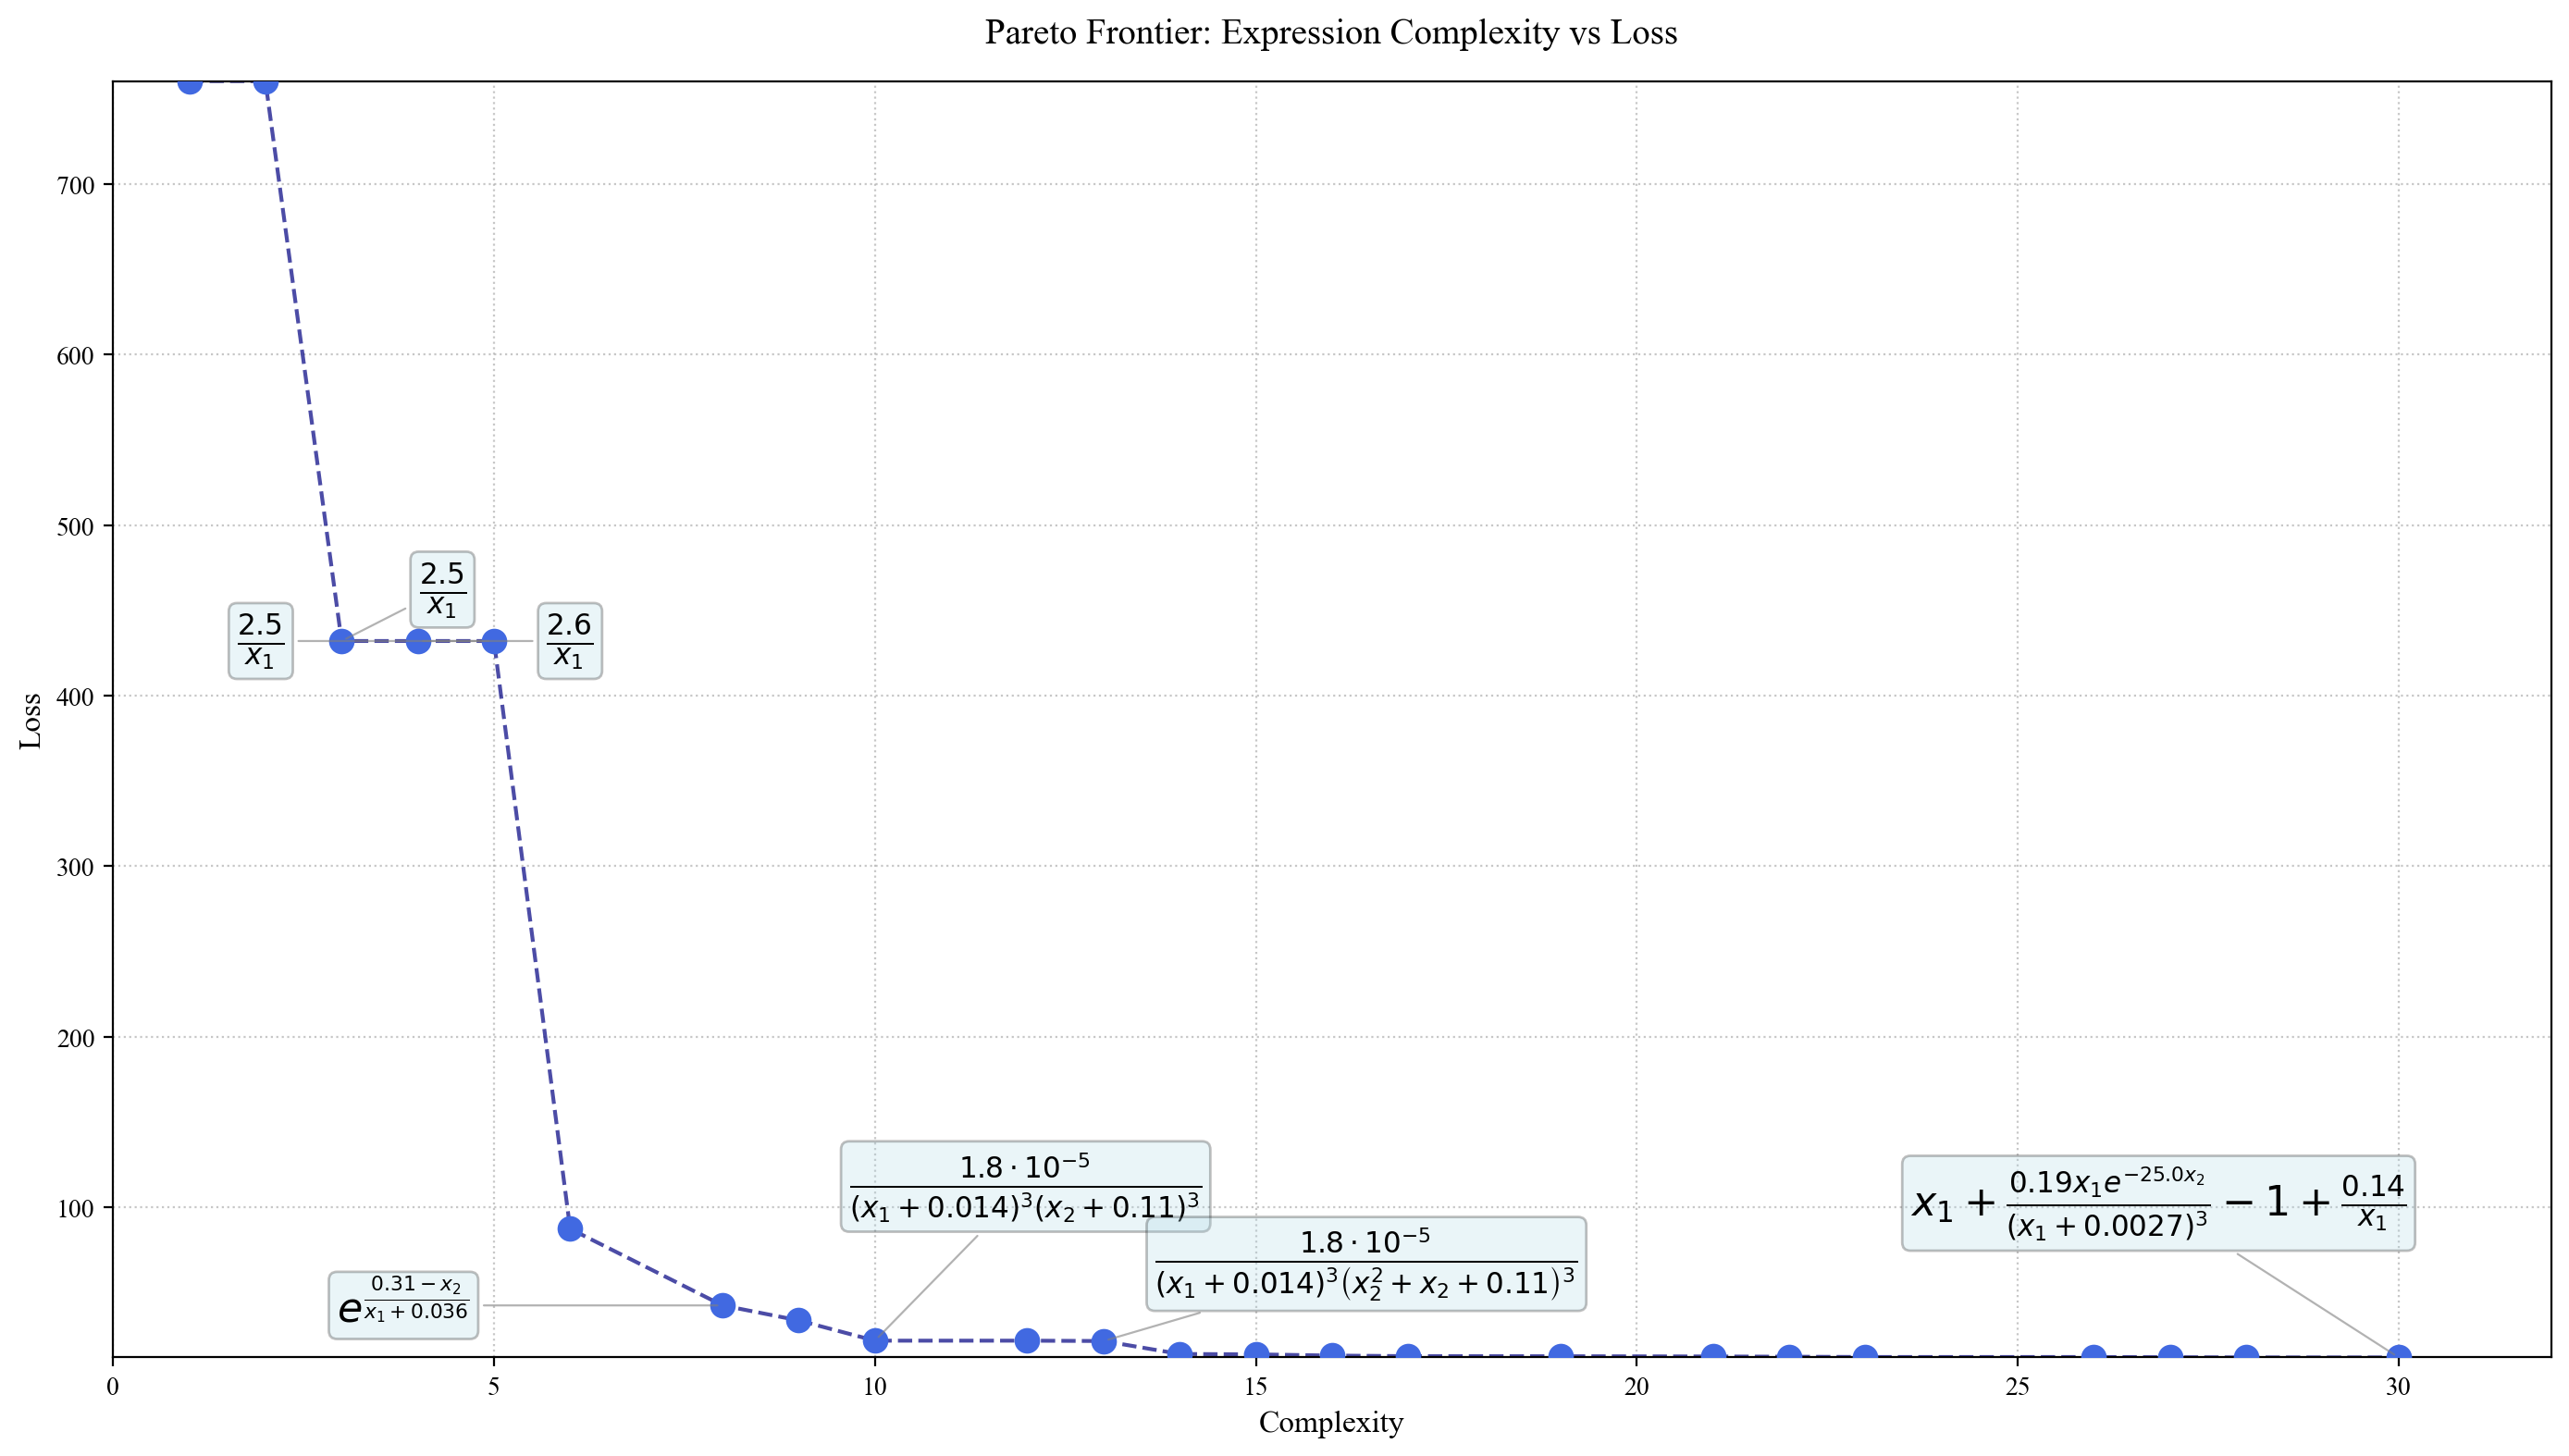

Expr 1 original: $0.82$
Expr 2 original: $0.82$
Expr 3 original: $\frac{2.5}{x_{1}}$
Expr 4 original: $\frac{2.56}{x_{1}}$
Expr 5 original: $\frac{2.5}{x_{1}}$
Expr 6 original: $\frac{0.002744}{\left(x_{1} + 0.008\right)^{3}}$
Expr 7 original: $e^{\frac{0.31 - x_{2}}{x_{1} + 0.036}}$
Expr 8 original: $e^{\frac{2 \left(0.23 - x_{2}\right)}{x_{1} + 0.054}}$
Expr 9 original: $\frac{1.7576 \cdot 10^{-5}}{\left(x_{1} + 0.014\right)^{3} \left(x_{2} + 0.11\right)^{3}}$
Expr 10 original: $\frac{1.7576 \cdot 10^{-5}}{\left(x_{1} + 0.014\right)^{3} \left(x_{2} + 0.11\right)^{3}}$
Expr 11 original: $\frac{1.7576 \cdot 10^{-5}}{\left(x_{1} + 0.014\right)^{3} \left(x_{2}^{2} + x_{2} + 0.11\right)^{3}}$
Expr 12 original: $\frac{0.00014556672 x_{1}}{\left(x_{1} + 0.0028\right)^{3} \left(x_{2} + 0.086\right)^{3}}$
Expr 13 original: $\frac{0.00014556672 x_{1}}{\left(x_{1} + 0.0027\right)^{3} \left(x_{2} + 0.09\right)^{3}}$
Expr 14 original: $\frac{0.00026244 x_{1}}{\left(x_{1} + 0.0027\right)^{3} \left

In [150]:
range_of_interest = (1, 48)
indices_of_interest = [i for i, c in enumerate(complexity) if range_of_interest[0] <= c <= range_of_interest[1]]
complexity = [complexity[i] for i in indices_of_interest]
loss = [loss[i] for i in indices_of_interest]
raw_equations = [raw_equations[i] for i in indices_of_interest]

# 2) Sympy setup
x1, x2 = sp.symbols('x1 x2')

# 3) Custom function to round constants only (not function arguments)
def round_constants(expr, ndigits=1):
    """
    Round every bare Float in `expr` so that, when printed,
    it has exactly `ndigits` digits after the decimal point
    in scientific notation (i.e. nd+1 significant figures).
    """
    def _is_leaf_float(e):
        return e.is_Float and not e.args

    def _round_sci(e):
        f = float(e)
        # format with `ndigits` places after the decimal in the mantissa:
        sci_str = f"{f:.{ndigits}e}"
        return sp.Float(sci_str)

    return expr.replace(_is_leaf_float, _round_sci)

# 4) Function to convert pow2 to squared form without evaluation
def convert_pow2(expr):
    # Find all pow2 calls
    if expr.func.__name__ == 'pow2':
        return sp.Pow(convert_pow2(expr.args[0]), 2, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow2(arg) for arg in expr.args]) if expr.args else expr

def convert_pow3(expr):
    # Find all pow3 calls
    if expr.func.__name__ == 'pow3':
        return sp.Pow(convert_pow3(expr.args[0]), 3, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow3(arg) for arg in expr.args]) if expr.args else expr

def convert_pow4(expr):
    # Find all pow4 calls
    if expr.func.__name__ == 'pow4':
        return sp.Pow(convert_pow4(expr.args[0]), 4, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow4(arg) for arg in expr.args]) if expr.args else expr

def convert_pow5(expr):
    # Find all pow5 calls
    if expr.func.__name__ == 'pow5':
        return sp.Pow(convert_pow5(expr.args[0]), 5, evaluate=False)
    # Recurse through expression
    return expr.func(*[convert_pow5(arg) for arg in expr.args]) if expr.args else expr

# 4) Function to convert pow_int without evaluation
def convert_pow_int(expr):
    # Find all pow_int calls
    if expr.func.__name__ == 'pow_int':
        base, exp = expr.args
        # If exp is literally an integer, convert to a Python int
        if exp.is_integer and exp.is_number:
            exp = int(exp)
        # Otherwise leave exp symbolic
        return sp.Pow(convert_pow_int(base), convert_pow_int(exp), evaluate=False)

    # Recursively descend into all other function applications
    if expr.args:
        return expr.func(*[convert_pow_int(arg) for arg in expr.args])
    else:
        return expr
    
def replace_pow_functions_recursive(expr: sp.Expr) -> sp.Expr:
    """
    Recursively replaces custom functions like powN(x) with standard power notation x**N.
    E.g. pow3(x + pow2(y)) → (x + y**2)**3
    """
    # First, apply recursively to all arguments (bottom-up),
    # so that nested pow-functions inside arguments get replaced too.
    expr = expr.xreplace({})  # no-op; just ensures expr is a Basic (not strictly needed)

    # Define replacement function
    def _repl(f):
        # check it's a function call
        if not isinstance(f, sp.Function):
            return f

        name = f.func.__name__
        if not name.startswith("pow"):
            return f

        # parse N from “powN”
        try:
            N = int(name[len("pow"):])
        except ValueError:
            return f

        if len(f.args) != 1:
            # unexpected arity, leave unchanged
            return f

        base = f.args[0]
        # Recursively transform the base
        new_base = replace_pow_functions_recursive(base)
        return new_base ** N

    # Use replace with map=False (so it returns an Expr)
    new_expr = expr.replace(
        lambda x: isinstance(x, sp.Function) and x.func.__name__.startswith("pow"),
        _repl,
        map=False
    )
    return new_expr

# 5) Build MathText labels
latex_labels = []
exprs_final = []
function_ready = []
for id, s in enumerate(raw_equations):
    try:
        # Pre-process pow2 -> custom function
        s_processed = s.replace('pow2', 'pow2_func')
        s_processed = s.replace('pow3', 'pow3_func')
        s_processed = s.replace('pow4', 'pow4_func')
        s_processed = s.replace('pow5', 'pow5_func')
        s_processed = s_processed.replace('pow_int', 'pow_int_func')
        
        # Define custom functions
        locals_dict = {
            'x1': x1,
            'x2': x2,
            'pow2_func': sp.Function('pow2'),
            'pow3_func': sp.Function('pow3'),
            'pow4_func': sp.Function('pow4'),
            'pow5_func': sp.Function('pow5'),
            'pow_int_func': sp.Function('pow_int'),
            'asin': sp.asin,
            'atan': sp.atan,
            'tan': sp.tan,
            'exp': sp.exp,
        }
        
        # Parse while preserving structure
        expr = parse_expr(s_processed, evaluate=False, local_dict=locals_dict)
        
        # Convert pow2_func to squared form
        expr_converted_pow2 = convert_pow2(expr)
        expr_converted_pow3 = convert_pow3(expr)
        expr_converted_pow4 = convert_pow4(expr)
        expr_converted_pow5 = convert_pow5(expr)
        expr_converted = convert_pow_int(expr_converted_pow5)
        
        # Round constants (only standalone floats)
        expr_converted_int1 = round_constants(expr_converted)
        expr_converted_int2 = round_constants(expr_converted_int1)
        expr_final = round_constants(expr_converted_int2)
        # expr_final = expr_final.simplify()
        # expr_final = expr_final.expand()
        exprs_final.append(expr_final)

        # Get MathText-friendly LaTeX
        mt = replace_pow_functions_recursive(expr_final)
        expr_converted_int1 = round_constants(mt)
        expr_converted_int2 = round_constants(expr_converted_int1)
        mt = round_constants(expr_converted_int2)
        mt = sp.latex(mt)
        latex_labels.append(f"${mt}$")
        
        # Replace 'exp' with 'np.exp'
        modified_expression = s.replace('exp', 'np.exp')
    
        # Replace 'log' with 'np.log'
        modified_expression = modified_expression.replace('log', 'np.log')
        function_ready.append(modified_expression)
        # Debug print
        print(f"Original at complexity {complexity[id]}: {s}")
        print(f"function_ready: {modified_expression}")
        print(f"Processed: {expr_final}")
        print(f"LaTeX: {mt}\n")
    except Exception as e:
        print(f"Error processing expression: {s}\n{e}")
        latex_labels.append(f"Error: {s}")

# 6) Manual offsets for clarity
offsets = [
    (0, 0), (0, 0), (30, 20), (50, 0), (-100, 0),
    (0, 0), (-150, 0), (0, 0), (-10, 60), (0, 0),
    (20, 30), (0, 0), (0, 0), (0, 0), (0, 0),
    (0, 0), (0, 0), (0, 0), (0, 0), (0, 0),
    (0, 0), (0, 0), (-190, 60), (0, 0), (0, 0),
]

# 7) Plot
fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(complexity, loss, s=80, zorder=3, color='royalblue')
ax.plot(complexity, loss, linestyle='--', alpha=0.7, zorder=2, color='navy')

# Set axis limits
ax.set_xlim(min(complexity) - 1, max(complexity) + 2)
ax.set_ylim(min(loss) - 0.0005, max(loss))
fig.subplots_adjust(right=0.75)


skip_indices = []
keep_indices = [3-1, 4-1, 5-1, 7-1, 9-1, 11-1, 23-1]
# Annotate with MathText labels
for i, (x, y, lbl, (dx, dy)) in enumerate(zip(complexity, loss, latex_labels, offsets)):
    if i in skip_indices or (i not in keep_indices):
        continue
    ax.annotate(
        lbl,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords='offset points',
        ha='left',
        va='center',
        fontsize=16,
        bbox=dict(boxstyle='round,pad=0.2', alpha=0.25, fc='lightblue'),
        arrowprops=dict(arrowstyle='-', lw=0.8, alpha=0.6, color='gray')
    )

ax.set_title("Pareto Frontier: Expression Complexity vs Loss", fontsize=14, pad=15)
ax.set_xlabel("Complexity", fontsize=12)
ax.set_ylabel("Loss", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.show()
# Explicitly close the figure object
plt.close() 
# Force the Python garbage collector to clean up memory
gc.collect()

#######################################
import re
from math import log10, floor
def clean_latex(latex_str, sigfigs=3):
    # --- Fix subscripts first (handle trailing zeros) ---
    latex_str = re.sub(r"x_\{1\.0+\}", "x_1", latex_str)
    latex_str = re.sub(r"x_\{2\.0+\}", "x_2", latex_str)

    # --- Fix powers like ^{2.0} -> ^2 (handles 2.0, 2.00, etc.) ---
    latex_str = re.sub(r"\^\{(\d+)\.0+\}", r"^\1", latex_str)

    # --- Round numeric literals not part of x_{...} or ^{...} ---
    def round_number(m):
        s = m.group(0)
        f = float(s)
        if f == 0:
            return "0"
        exp = floor(log10(abs(f)))
        rounded = round(f, sigfigs - 1 - exp)

        # If rounded is integer-valued, print as integer (no trailing .0)
        if abs(rounded - int(rounded)) < 1e-12:
            return str(int(rounded))

        # Otherwise print normal decimal unless scientific notation is needed
        if 1e-3 <= abs(rounded) < 1e4:
            return str(rounded)
        return f"{rounded:.{sigfigs-1}e}"

    # Negative lookbehinds:
    #  - (?<!x_\{) prevents matching digits inside x_{...}
    #  - (?<!\^\{) prevents matching digits inside ^{...} (exponents)
    number_pattern = re.compile(r"(?<!x_\{)(?<!\^\{)\d*\.?\d+(?:[eE][-+]?\d+)?")
    latex_str = number_pattern.sub(round_number, latex_str)

    return latex_str


# --- after your existing code that builds exprs_final ---

# 1) Simplify each expression
simplified_exprs = [sp.simplify(expr) for expr in exprs_final]
# rounded_simplified_exprs = [round_constants(expr) for expr in simplified_exprs]
# rounded_simplified_exprs = [round_constants(expr) for expr in rounded_simplified_exprs]

# 2) Print them in LaTeX form
for i, expr in enumerate(exprs_final, 1):
    mt = replace_pow_functions_recursive(expr)
    latex_str = sp.latex(mt)
    print(f"Expr {i} original: ${latex_str}$")


print("\n--- Simplified Expressions ---\n")
# 2) Print them in LaTeX form
for i, expr in enumerate(simplified_exprs, 1):
    mt = replace_pow_functions_recursive(expr)
    latex_str = sp.latex(mt)
    latex_str = clean_latex(latex_str, sigfigs=2)
    print(f"complexity {complexity[i-1]} simplified: ${latex_str}$")

In [151]:
predicted_functions_nphybrid = [eval(f'lambda x1, x2: {str_func}', {'np':np, 'pow2':pow2, 'pow3':pow3, 'pow4':pow4, 'pow5':pow5}) for str_func in function_ready]
masked_functions_nphybrid = [
    (lambda f: lambda x1, x2, mask: np.where(mask, 0, f(x1, x2)))(f)
    for f in predicted_functions_nphybrid
]

In [152]:
log_likelihood_scores_nphybrid = log_likelihood_scores
complexity_nphybrid = complexity

## Normalization

In [46]:
# clipped_masked_functions = [
#     (lambda f: lambda x1, x2: np.maximum(1e-9, f(x1, x2, mask)))(f)
#     for f in masked_functions
# ]

In [181]:
clipped_masked_functions_pure = [
    (lambda f: lambda x1, x2: np.maximum(1e-18, f(x1, x2, mask)))(f)
    for f in masked_functions_pure
]

In [182]:
clipped_masked_functions_mse = [
    (lambda f: lambda x1, x2: np.maximum(1e-18, f(x1, x2, mask)))(f)
    for f in masked_functions_mse
]

In [183]:
clipped_masked_functions_hybridhard = [
    (lambda f: lambda x1, x2: np.maximum(1e-18, f(x1, x2, mask)))(f)
    for f in masked_functions_hybridhard
]

In [184]:
clipped_masked_functions_nphybrid = [
    (lambda f: lambda x1, x2: np.maximum(1e-18, f(x1, x2, mask)))(f)
    for f in masked_functions_nphybrid
]

In [ ]:
# # 1. Calculate grid spacing
# dx = grids[0][1, 0] - grids[0][0, 0]
# dy = grids[1][0, 1] - grids[1][0, 0]
# cell_area = dx * dy

# integrals = []
# integrals_unclipped = []
# bad_counts = []

# for i, func in enumerate(clipped_masked_functions):
#     # Suppress warnings so the console doesn't flood during the loop
#     # with np.errstate(all='ignore'):
#     values = func(grids[0], grids[1])
        
#     # 2. Count non-finite points (NaN or Inf)
#     # np.isfinite returns False for both NaN and Inf
#     bad_mask = ~np.isfinite(values)
#     num_bad = np.sum(bad_mask)
#     bad_counts.append(num_bad)
        
#     # 3. Compute the integral
#     # Note: If num_bad > 0, total_integral will likely be NaN or Inf
#     total_integral = np.sum(values) * cell_area
#     integrals.append(total_integral)
        
#     if num_bad > 0:
#         print(f"Function {i}: {num_bad:,} bad coordinates found.")

# for i, func in enumerate(masked_functions):
#     # Suppress warnings so the console doesn't flood during the loop
#     # with np.errstate(all='ignore'):
#     values = func(grids[0], grids[1], mask)
        
#     # 2. Count non-finite points (NaN or Inf)
#     # np.isfinite returns False for both NaN and Inf
#     bad_mask = ~np.isfinite(values)
#     num_bad = np.sum(bad_mask)
#     bad_counts.append(num_bad)
        
#     # 3. Compute the integral
#     # Note: If num_bad > 0, total_integral will likely be NaN or Inf
#     total_integral = np.sum(values) * cell_area
#     integrals_unclipped.append(total_integral)
        
#     if num_bad > 0:
#         print(f"Function {i}: {num_bad:,} bad coordinates found.")

In [185]:
# 1. Calculate grid spacing
dx = grids[0][1, 0] - grids[0][0, 0]
dy = grids[1][0, 1] - grids[1][0, 0]
cell_area = dx * dy

integrals_pure = []
integrals_unclipped_pure = []
bad_counts = []

for i, func in enumerate(clipped_masked_functions_pure):
    # Suppress warnings so the console doesn't flood during the loop
    # with np.errstate(all='ignore'):
    values = func(grids[0], grids[1])
        
    # 2. Count non-finite points (NaN or Inf)
    # np.isfinite returns False for both NaN and Inf
    bad_mask = ~np.isfinite(values)
    num_bad = np.sum(bad_mask)
    bad_counts.append(num_bad)
        
    # 3. Compute the integral
    # Note: If num_bad > 0, total_integral will likely be NaN or Inf
    total_integral = np.sum(values) * cell_area
    integrals_pure.append(total_integral)
        
    if num_bad > 0:
        print(f"Function {i}: {num_bad:,} bad coordinates found.")

for i, func in enumerate(masked_functions_pure):
    # Suppress warnings so the console doesn't flood during the loop
    # with np.errstate(all='ignore'):
    values = func(grids[0], grids[1], mask)
        
    # 2. Count non-finite points (NaN or Inf)
    # np.isfinite returns False for both NaN and Inf
    bad_mask = ~np.isfinite(values)
    num_bad = np.sum(bad_mask)
    bad_counts.append(num_bad)
        
    # 3. Compute the integral
    # Note: If num_bad > 0, total_integral will likely be NaN or Inf
    total_integral = np.sum(values) * cell_area
    integrals_unclipped_pure.append(total_integral)
        
    if num_bad > 0:
        print(f"Function {i}: {num_bad:,} bad coordinates found.")

<string>:1: RuntimeWarning:

invalid value encountered in log

<string>:1: RuntimeWarning:

invalid value encountered in log

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp



In [186]:
# 1. Calculate grid spacing
dx = grids[0][1, 0] - grids[0][0, 0]
dy = grids[1][0, 1] - grids[1][0, 0]
cell_area = dx * dy

integrals_mse = []
integrals_unclipped_mse = []
bad_counts = []

for i, func in enumerate(clipped_masked_functions_mse):
    # Suppress warnings so the console doesn't flood during the loop
    # with np.errstate(all='ignore'):
    values = func(grids[0], grids[1])
        
    # 2. Count non-finite points (NaN or Inf)
    # np.isfinite returns False for both NaN and Inf
    bad_mask = ~np.isfinite(values)
    num_bad = np.sum(bad_mask)
    bad_counts.append(num_bad)
        
    # 3. Compute the integral
    # Note: If num_bad > 0, total_integral will likely be NaN or Inf
    total_integral = np.sum(values) * cell_area
    integrals_mse.append(total_integral)
        
    if num_bad > 0:
        print(f"Function {i}: {num_bad:,} bad coordinates found.")

for i, func in enumerate(masked_functions_mse):
    # Suppress warnings so the console doesn't flood during the loop
    # with np.errstate(all='ignore'):
    values = func(grids[0], grids[1], mask)
        
    # 2. Count non-finite points (NaN or Inf)
    # np.isfinite returns False for both NaN and Inf
    bad_mask = ~np.isfinite(values)
    num_bad = np.sum(bad_mask)
    bad_counts.append(num_bad)
        
    # 3. Compute the integral
    # Note: If num_bad > 0, total_integral will likely be NaN or Inf
    total_integral = np.sum(values) * cell_area
    integrals_unclipped_mse.append(total_integral)
        
    if num_bad > 0:
        print(f"Function {i}: {num_bad:,} bad coordinates found.")

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

invalid value encountered in log

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

invalid value encountered in log

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

invalid value encountered in log

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

invalid value encountered in log

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

invalid value encountered in log

<string>:1: RuntimeWarning:

invalid value encountered in log

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

invalid value

In [187]:
# 1. Calculate grid spacing
dx = grids[0][1, 0] - grids[0][0, 0]
dy = grids[1][0, 1] - grids[1][0, 0]
cell_area = dx * dy

integrals_hybridhard = []
integrals_unclipped_hybridhard = []
bad_counts = []

for i, func in enumerate(clipped_masked_functions_hybridhard):
    # Suppress warnings so the console doesn't flood during the loop
    # with np.errstate(all='ignore'):
    values = func(grids[0], grids[1])
        
    # 2. Count non-finite points (NaN or Inf)
    # np.isfinite returns False for both NaN and Inf
    bad_mask = ~np.isfinite(values)
    num_bad = np.sum(bad_mask)
    bad_counts.append(num_bad)
        
    # 3. Compute the integral
    # Note: If num_bad > 0, total_integral will likely be NaN or Inf
    total_integral = np.sum(values) * cell_area
    integrals_hybridhard.append(total_integral)
        
    if num_bad > 0:
        print(f"Function {i}: {num_bad:,} bad coordinates found.")

for i, func in enumerate(masked_functions_hybridhard):
    # Suppress warnings so the console doesn't flood during the loop
    # with np.errstate(all='ignore'):
    values = func(grids[0], grids[1], mask)
        
    # 2. Count non-finite points (NaN or Inf)
    # np.isfinite returns False for both NaN and Inf
    bad_mask = ~np.isfinite(values)
    num_bad = np.sum(bad_mask)
    bad_counts.append(num_bad)
        
    # 3. Compute the integral
    # Note: If num_bad > 0, total_integral will likely be NaN or Inf
    total_integral = np.sum(values) * cell_area
    integrals_unclipped_hybridhard.append(total_integral)
        
    if num_bad > 0:
        print(f"Function {i}: {num_bad:,} bad coordinates found.")

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in multiply

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp



In [188]:
# 1. Calculate grid spacing
dx = grids[0][1, 0] - grids[0][0, 0]
dy = grids[1][0, 1] - grids[1][0, 0]
cell_area = dx * dy

integrals_nphybrid = []
integrals_unclipped_nphybrid = []
bad_counts = []

for i, func in enumerate(clipped_masked_functions_nphybrid):
    # Suppress warnings so the console doesn't flood during the loop
    # with np.errstate(all='ignore'):
    values = func(grids[0], grids[1])
        
    # 2. Count non-finite points (NaN or Inf)
    # np.isfinite returns False for both NaN and Inf
    bad_mask = ~np.isfinite(values)
    num_bad = np.sum(bad_mask)
    bad_counts.append(num_bad)
        
    # 3. Compute the integral
    # Note: If num_bad > 0, total_integral will likely be NaN or Inf
    total_integral = np.sum(values) * cell_area
    integrals_nphybrid.append(total_integral)
        
    if num_bad > 0:
        print(f"Function {i}: {num_bad:,} bad coordinates found.")

for i, func in enumerate(masked_functions_nphybrid):
    # Suppress warnings so the console doesn't flood during the loop
    # with np.errstate(all='ignore'):
    values = func(grids[0], grids[1], mask)
        
    # 2. Count non-finite points (NaN or Inf)
    # np.isfinite returns False for both NaN and Inf
    bad_mask = ~np.isfinite(values)
    num_bad = np.sum(bad_mask)
    bad_counts.append(num_bad)
        
    # 3. Compute the integral
    # Note: If num_bad > 0, total_integral will likely be NaN or Inf
    total_integral = np.sum(values) * cell_area
    integrals_unclipped_nphybrid.append(total_integral)
        
    if num_bad > 0:
        print(f"Function {i}: {num_bad:,} bad coordinates found.")

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

/tmp/ipykernel_1853/691372964.py:1: RuntimeWarning:

overflow encountered in square



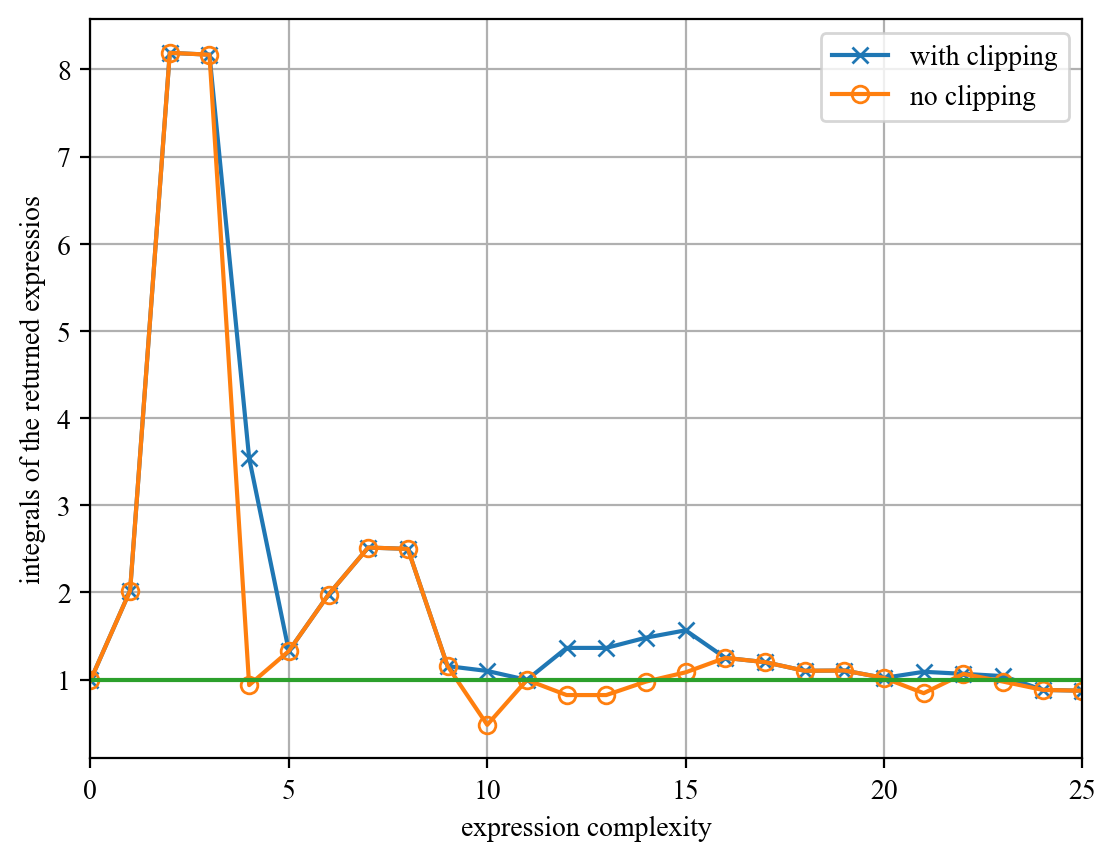

In [162]:
plt.plot(integrals, marker = 'x', label='with clipping')
plt.plot(integrals_unclipped, marker='o', markerfacecolor='none', label='no clipping')
plt.plot([0, 25], [1,1])
plt.ylabel('integrals of the returned expressios')
plt.xlabel('expression complexity')
plt.xlim([0,25])
plt.legend()
plt.grid(True)


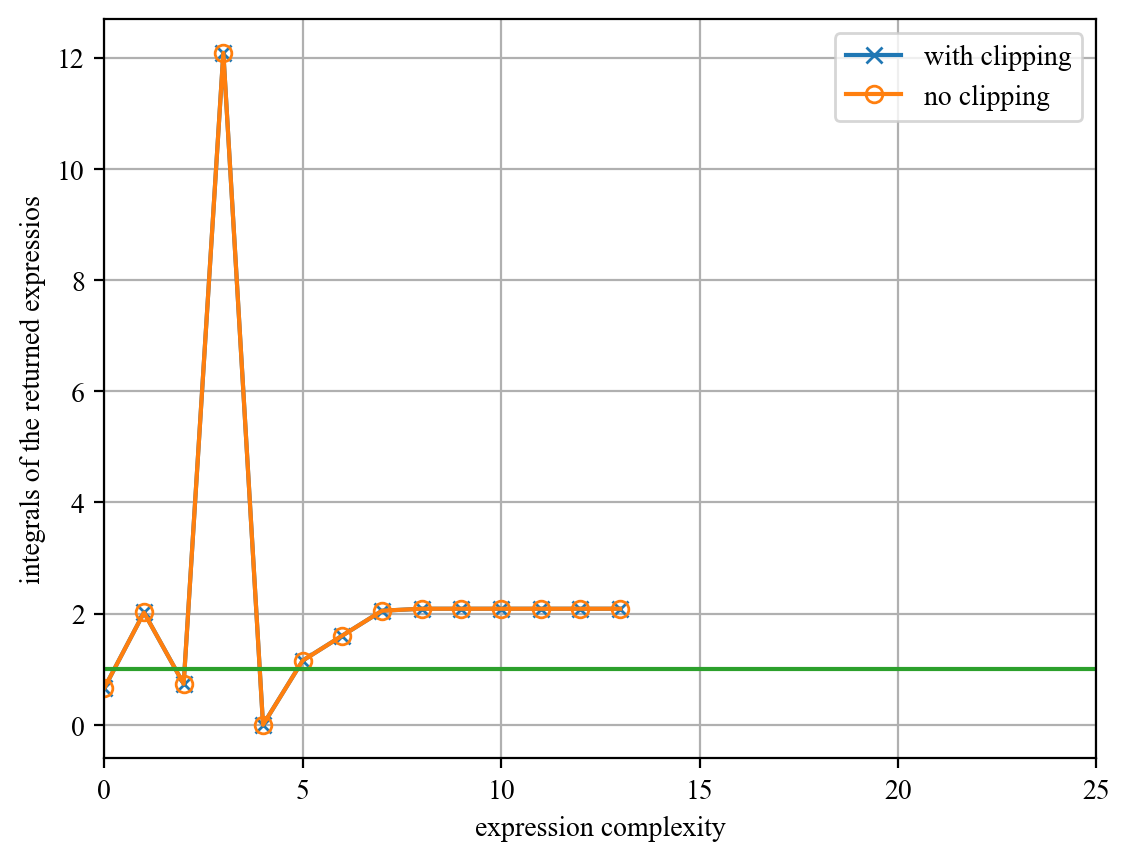

In [163]:
plt.plot(integrals_pure, marker = 'x', label='with clipping')
plt.plot(integrals_unclipped_pure, marker='o', markerfacecolor='none', label='no clipping')
plt.plot([0, 25], [1,1])
plt.ylabel('integrals of the returned expressios')
plt.xlabel('expression complexity')
plt.xlim([0,25])
plt.legend()
plt.grid(True)

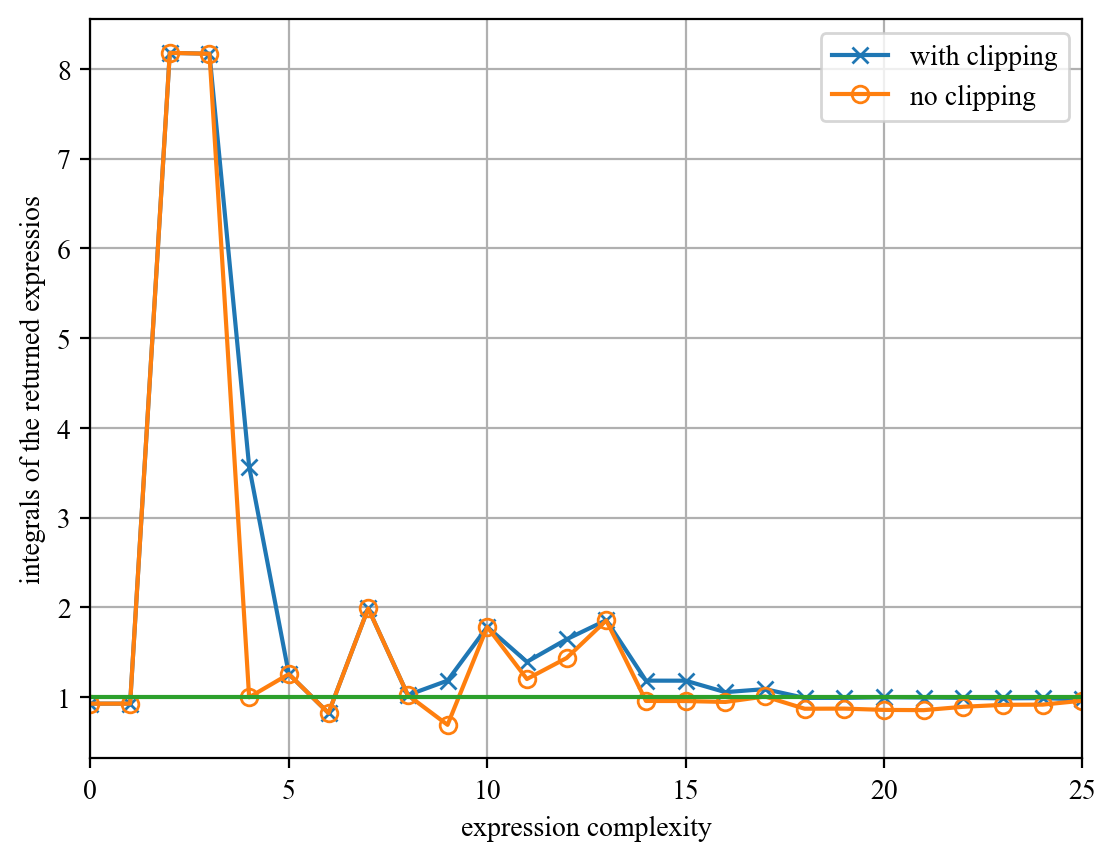

In [164]:
plt.plot(integrals_mse, marker = 'x', label='with clipping')
plt.plot(integrals_unclipped_mse, marker='o', markerfacecolor='none', label='no clipping')
plt.plot([0, 25], [1,1])
plt.ylabel('integrals of the returned expressios')
plt.xlabel('expression complexity')
plt.xlim([0,25])
plt.legend()
plt.grid(True)

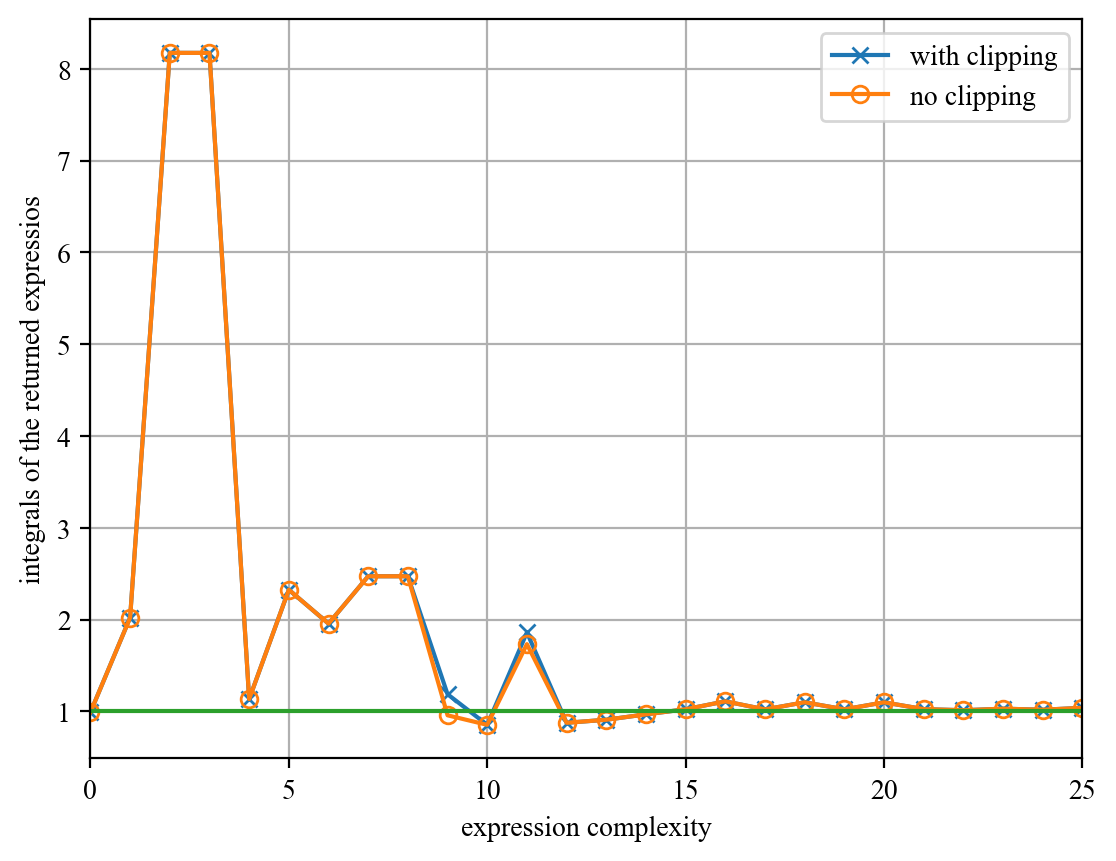

In [165]:
plt.plot(integrals_hybridhard, marker = 'x', label='with clipping')
plt.plot(integrals_unclipped_hybridhard, marker='o', markerfacecolor='none', label='no clipping')
plt.plot([0, 25], [1,1])
plt.ylabel('integrals of the returned expressios')
plt.xlabel('expression complexity')
plt.xlim([0,25])
plt.legend()
plt.grid(True)

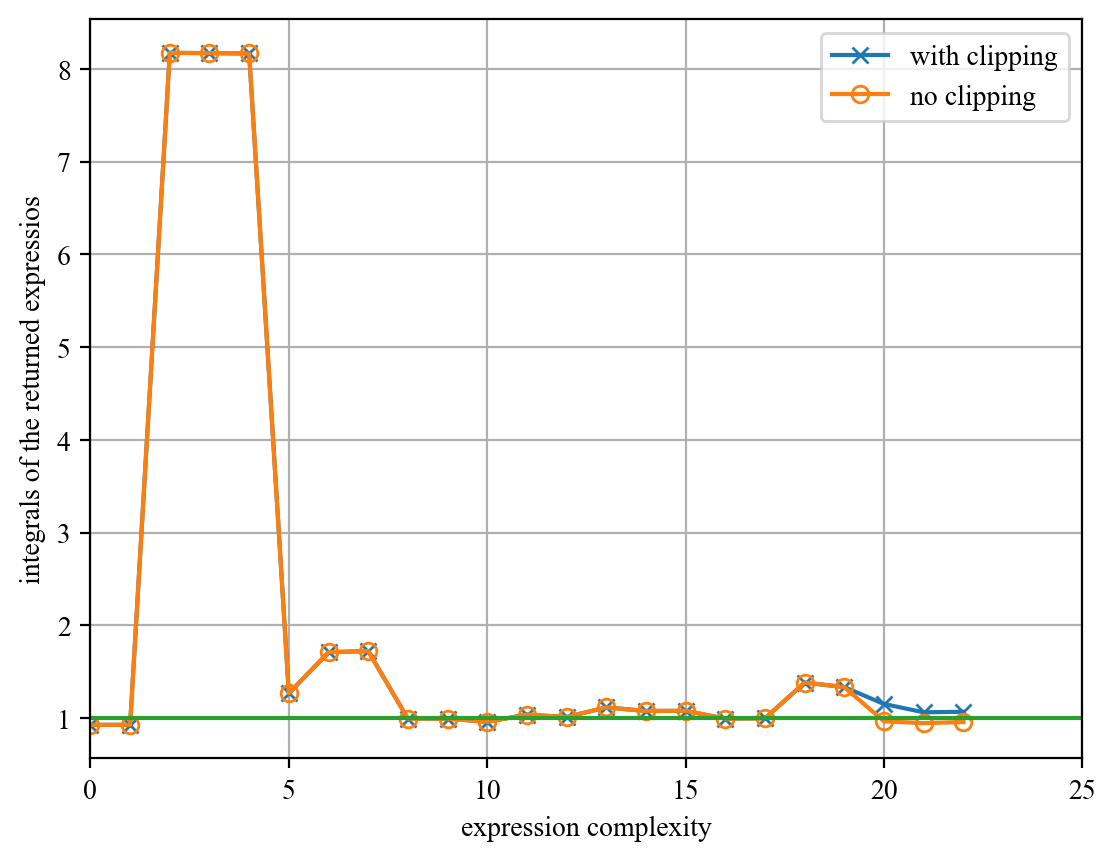

In [166]:
plt.plot(integrals_nphybrid, marker = 'x', label='with clipping')
plt.plot(integrals_unclipped_nphybrid, marker='o', markerfacecolor='none', label='no clipping')
plt.plot([0, 25], [1,1])
plt.ylabel('integrals of the returned expressios')
plt.xlabel('expression complexity')
plt.xlim([0,25])
plt.legend()
plt.grid(True)

### Clipping comparison with vanilla SR MSE loss

Likelihood score of the corrected KDE: 4.722576214899293

Function at complexity 1: Likelihood score = -0.11721424558278981, prob: 8893.946238803033
Function at complexity 2: Likelihood score = -0.1172142455829197, prob: 8893.946238801878
Function at complexity 3: Likelihood score = 3.442771204664705, prob: 814669.4786033537
Function at complexity 4: Likelihood score = 3.4427712046645387, prob: 814669.4786032179
Function at complexity 5: Likelihood score = 3.4427712046643135, prob: 814669.4786030349
Function at complexity 6: Likelihood score = 5.53239846811102, prob: 8200559.997655105
Function at complexity 8: Likelihood score = 5.210636488425396, prob: 5456777.643093271
Function at complexity 9: Likelihood score = 5.395884808140413, prob: 5849739.407862163
Function at complexity 10: Likelihood score = 5.893933713914937, prob: 10850132.356631314
Function at complexity 12: Likelihood score = 5.893933713914937, prob: 10850132.356631314
Function at complexity 13: Likelihood score = 5.9002

/tmp/ipykernel_1853/360118478.py:11: RuntimeWarning:

invalid value encountered in log



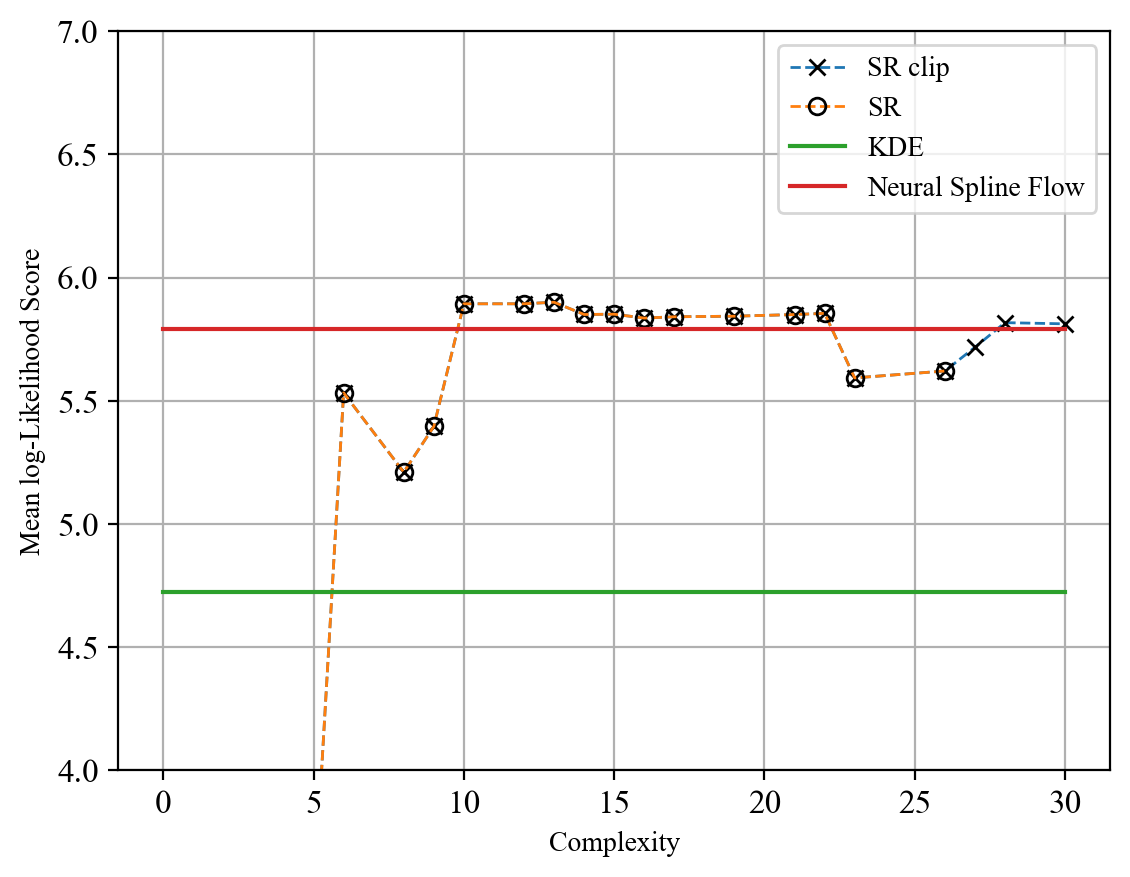

In [175]:
kde_eval_at_samples = interp_kde_at_samples(test_samples)
likelihood_score = np.sum(np.log(kde_eval_at_samples+1e-130))/np.shape(test_samples)[0]
print(f"Likelihood score of the corrected KDE: {likelihood_score:,}\n")

log_likelihood_scores = []
for idx, func in enumerate(predicted_functions_nphybrid):
    # Compute likelihood scores
    prediction_eval_at_samples = (1/integrals_nphybrid[idx])*func(test_samples[:, 0], test_samples[:, 1])
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores.append(likelihood_score_pred)
    print(f"Function at complexity {complexity_nphybrid[idx]}: Likelihood score = {likelihood_score_pred:,}, prob: {np.sum(prediction_eval_at_samples/density_scale_factor)}")

log_likelihood_scores_clipped = []
for idx, func in enumerate(predicted_functions_nphybrid):
    # Compute likelihood scores
    prediction_eval_at_samples = (1/integrals_nphybrid[idx])*np.max([1e-12*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_clipped.append(likelihood_score_pred)
    print(f"Function at complexity {complexity_nphybrid[idx]}: Likelihood score = {likelihood_score_pred:,}")


plt.plot(complexity_nphybrid, log_likelihood_scores_clipped, marker="x", markeredgecolor="black", linestyle="--", linewidth=1, label="SR clip")
plt.plot(complexity_nphybrid, log_likelihood_scores, marker="o", markeredgecolor="black", markerfacecolor='none', linestyle="--", linewidth=1, label="SR")
plt.plot([0, max(complexity_nphybrid)], [likelihood_score, likelihood_score], label="KDE")
plt.plot([0, max(complexity_nphybrid)], [likelihood_score_neural, likelihood_score_neural], label="Neural Spline Flow")
plt.xlabel("Complexity", fontname='Times New Roman')
plt.ylabel("Mean log-Likelihood Score", fontname='Times New Roman')
# plt.title("Mean log-Likelihood Score vs. Complexity")
plt.ylim([4, 7])
plt.grid(True)
plt.legend()
plt.legend(prop={'family': 'Times New Roman'})  # size optional
plt.xticks(fontname='Times New Roman', fontsize=12)
plt.yticks(fontname='Times New Roman', fontsize=12)
plt.show()

In [73]:
kde_eval_at_samples = interp_kde_at_samples(test_samples)
likelihood_score = np.sum(np.log(kde_eval_at_samples+1e-130))/np.shape(test_samples)[0]
print(f"Likelihood score of the corrected KDE: {likelihood_score:,}\n")

log_likelihood_scores = []
for idx, func in enumerate(predicted_functions_hybrid):
    # Compute likelihood scores
    prediction_eval_at_samples = (1/integrals[idx])*func(test_samples[:, 0], test_samples[:, 1])
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores.append(likelihood_score_pred)
    print(f"Function at complexity {complexity_hybrid[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_clipped = []
for idx, func in enumerate(predicted_functions_hybrid):
    # Compute likelihood scores
    prediction_eval_at_samples = (1/integrals[idx])*np.max([1e-12*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_clipped.append(likelihood_score_pred)
    print(f"Function at complexity {complexity_hybrid[idx]}: Likelihood score = {likelihood_score_pred:,}")


plt.plot(complexity_hybrid, log_likelihood_scores_clipped, marker="x", markeredgecolor="black", linestyle="--", linewidth=1, label="SR clip")
plt.plot(complexity_hybrid, log_likelihood_scores, marker="o", markeredgecolor="black", markerfacecolor='none', linestyle="--", linewidth=1, label="SR")
plt.plot([0, max(complexity_hybridhard)], [likelihood_score, likelihood_score], label="KDE")
plt.plot([0, max(complexity_hybridhard)], [likelihood_score_neural, likelihood_score_neural], label="Neural Spline Flow")
plt.xlabel("Complexity", fontname='Times New Roman')
plt.ylabel("Mean log-Likelihood Score", fontname='Times New Roman')
# plt.title("Mean log-Likelihood Score vs. Complexity")
plt.ylim([4, 7])
plt.grid(True)
plt.legend()
plt.legend(prop={'family': 'Times New Roman'})  # size optional
plt.xticks(fontname='Times New Roman', fontsize=12)
plt.yticks(fontname='Times New Roman', fontsize=12)
plt.show()

Likelihood score of the corrected KDE: 4.722576214899293



NameError: name 'predicted_functions_hybrid' is not defined

Likelihood score of the corrected KDE: 4.722576214899293

Function at complexity 1: Likelihood score = -0.1276464147764475
Function at complexity 2: Likelihood score = 0.02835055295439198
Function at complexity 3: Likelihood score = 5.54382348813533
Function at complexity 5: Likelihood score = 5.543819746025365
Function at complexity 6: Likelihood score = 5.674791092455248
Function at complexity 7: Likelihood score = 5.713524378778228
Function at complexity 8: Likelihood score = 5.946619544707552
Function at complexity 10: Likelihood score = 5.974970097661944
Function at complexity 11: Likelihood score = 5.974970097661944
Function at complexity 12: Likelihood score = 5.948908125749861
Function at complexity 13: Likelihood score = 5.547171582865321
Function at complexity 14: Likelihood score = 5.874603847960801
Function at complexity 15: Likelihood score = 5.568756189913431
Function at complexity 16: Likelihood score = 5.57549218336585
Function at complexity 18: Likelihood score = 5.553

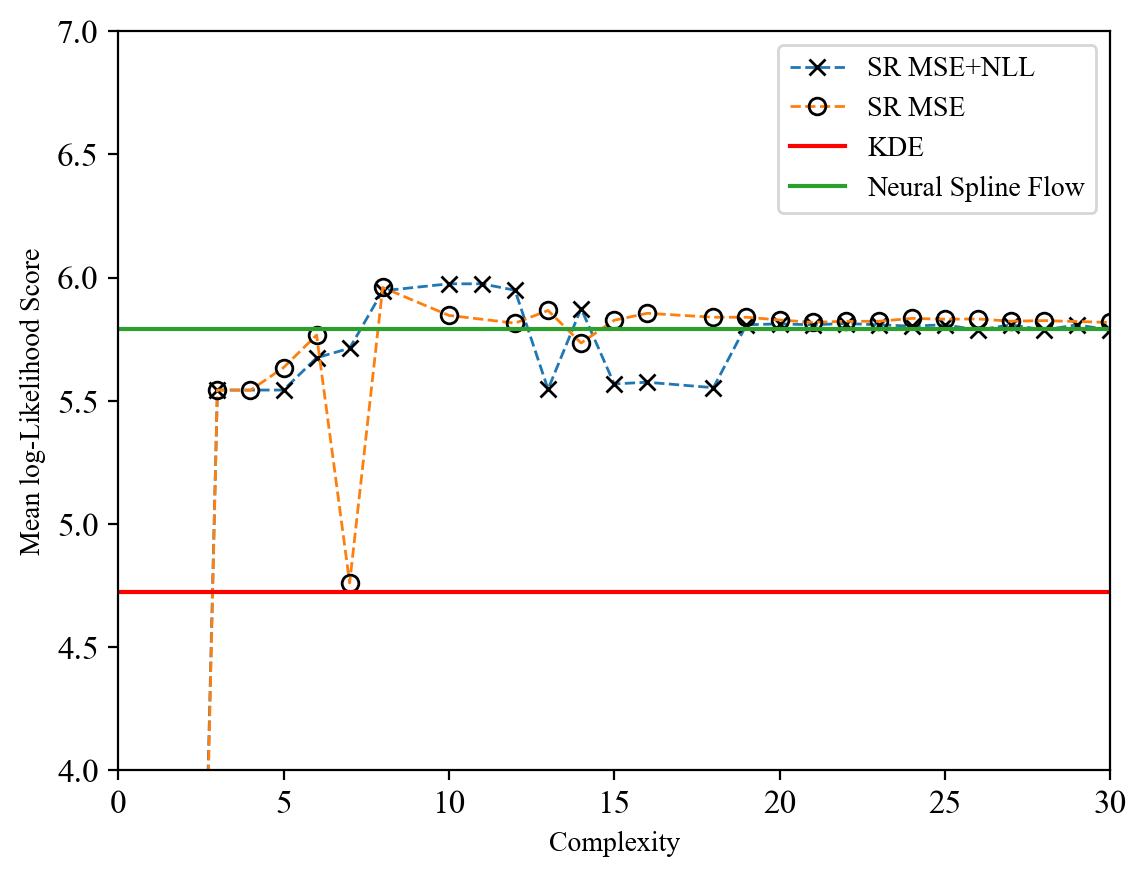

In [ ]:
# No normalization

kde_eval_at_samples = interp_kde_at_samples(test_samples)
likelihood_score = np.sum(np.log(kde_eval_at_samples+1e-130))/np.shape(test_samples)[0]
print(f"Likelihood score of the corrected KDE: {likelihood_score:,}\n")

log_likelihood_scores_hybrid = []
for idx, func in enumerate(predicted_functions):
    # Compute likelihood scores
    prediction_eval_at_samples = func(test_samples[:, 0], test_samples[:, 1])
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples[prediction_eval_at_samples>1e-12]/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_hybrid.append(likelihood_score_pred)
    print(f"Function at complexity {complexity_hybrid[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_mse = []
for idx, func in enumerate(predicted_functions_mse):
    # Compute likelihood scores
    prediction_eval_at_samples = func(test_samples[:, 0], test_samples[:, 1])
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples[prediction_eval_at_samples>1e-12]/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_mse.append(likelihood_score_pred)
    print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")

plt.plot(complexity_hybrid, log_likelihood_scores_hybrid, marker="x", markeredgecolor="black", linestyle="--", linewidth=1, label="SR MSE+NLL")
plt.plot(complexity_mse, log_likelihood_scores_mse, marker="o", markeredgecolor="black", markerfacecolor='none', linestyle="--", linewidth=1, label="SR MSE")
plt.plot([0, max(complexity)], [likelihood_score, likelihood_score], label="KDE", color="red")
plt.plot([0, max(complexity)], [likelihood_score_neural, likelihood_score_neural], label="Neural Spline Flow")
plt.xlabel("Complexity", fontname='Times New Roman')
plt.ylabel("Mean log-Likelihood Score", fontname='Times New Roman')
# plt.title("Mean log-Likelihood Score vs. Complexity")
plt.ylim([4, 7])
plt.xlim([0, 30])
plt.grid(False)
plt.legend()
plt.legend(prop={'family': 'Times New Roman'})  # size optional
plt.xticks(fontname='Times New Roman', fontsize=12)
plt.yticks(fontname='Times New Roman', fontsize=12)
plt.show()

# plt.savefig("./visualization/compare_likelihood.png", dpi=300, bbox_inches='tight')

Likelihood score of the corrected KDE: 4.722576214899293

Function at complexity 1: Likelihood score = -0.11721424532340506
Function at complexity 2: Likelihood score = -0.6750707579245574
Function at complexity 3: Likelihood score = 3.442771204664753
Function at complexity 5: Likelihood score = 3.442831103649154
Function at complexity 6: Likelihood score = 5.549758218175142
Function at complexity 7: Likelihood score = 4.869752213589939
Function at complexity 8: Likelihood score = 5.27576773537721
Function at complexity 10: Likelihood score = 5.069982888937257
Function at complexity 11: Likelihood score = 5.069982888937257
Function at complexity 12: Likelihood score = 5.777853180055591
Function at complexity 13: Likelihood score = 5.706030641989869
Function at complexity 14: Likelihood score = 5.257683460914303
Function at complexity 15: Likelihood score = 5.701836843595574
Function at complexity 16: Likelihood score = 5.671126433647928
Function at complexity 18: Likelihood score = 5.5

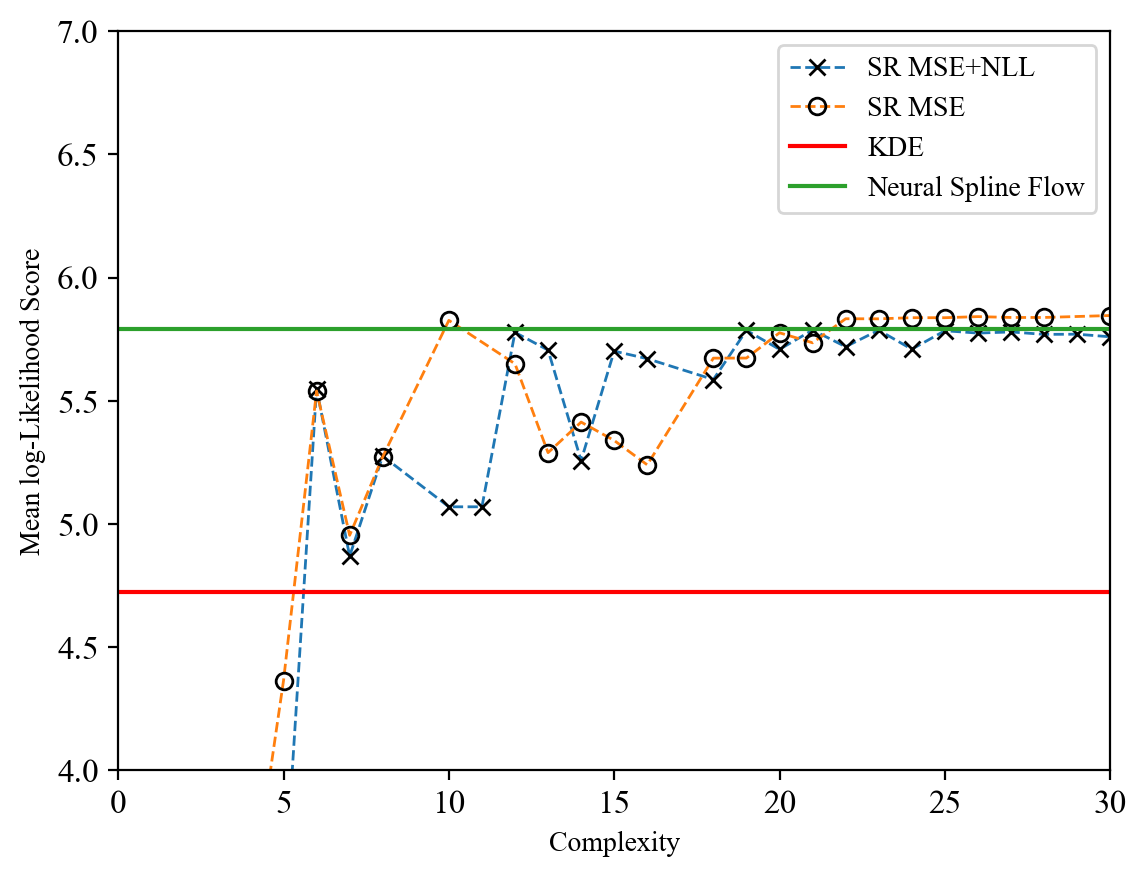

In [ ]:
# With normalization (integrals clipped, function not clipped)

kde_eval_at_samples = interp_kde_at_samples(test_samples)
likelihood_score = np.sum(np.log(kde_eval_at_samples+1e-130))/np.shape(test_samples)[0]
print(f"Likelihood score of the corrected KDE: {likelihood_score:,}\n")

log_likelihood_scores_hybrid = []
for idx, func in enumerate(predicted_functions):
    # Compute likelihood scores
    prediction_eval_at_samples = (1/integrals[idx])*func(test_samples[:, 0], test_samples[:, 1])
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples[prediction_eval_at_samples>1e-12]/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_hybrid.append(likelihood_score_pred)
    print(f"Function at complexity {complexity_hybrid[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_mse = []
for idx, func in enumerate(predicted_functions_mse):
    # Compute likelihood scores
    prediction_eval_at_samples = (1/integrals_mse[idx])*func(test_samples[:, 0], test_samples[:, 1])
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples[prediction_eval_at_samples>1e-12]/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_mse.append(likelihood_score_pred)
    print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")

plt.plot(complexity_hybrid, log_likelihood_scores_hybrid, marker="x", markeredgecolor="black", linestyle="--", linewidth=1, label="SR MSE+NLL")
plt.plot(complexity_mse, log_likelihood_scores_mse, marker="o", markeredgecolor="black", markerfacecolor='none', linestyle="--", linewidth=1, label="SR MSE")
plt.plot([0, max(complexity)], [likelihood_score, likelihood_score], label="KDE", color="red")
plt.plot([0, max(complexity)], [likelihood_score_neural, likelihood_score_neural], label="Neural Spline Flow")
plt.xlabel("Complexity", fontname='Times New Roman')
plt.ylabel("Mean log-Likelihood Score", fontname='Times New Roman')
# plt.title("Mean log-Likelihood Score vs. Complexity")
plt.ylim([4, 7])
plt.xlim([0, 30])
plt.grid(False)
plt.legend()
plt.legend(prop={'family': 'Times New Roman'})  # size optional
plt.xticks(fontname='Times New Roman', fontsize=12)
plt.yticks(fontname='Times New Roman', fontsize=12)
plt.show()

Likelihood score of the corrected KDE: 4.722576214899293

Function at complexity 1: Likelihood score = -0.11721424156554021
Function at complexity 2: Likelihood score = -0.6750707560841326
Function at complexity 3: Likelihood score = 3.442771205119673
Function at complexity 5: Likelihood score = 3.4428311041041053
Function at complexity 6: Likelihood score = 5.549758221456925
Function at complexity 7: Likelihood score = 4.869752215189368
Function at complexity 8: Likelihood score = 5.275767737278568
Function at complexity 10: Likelihood score = 5.0699828904417155
Function at complexity 11: Likelihood score = 5.0699828904417155
Function at complexity 12: Likelihood score = 5.992779816017976
Function at complexity 13: Likelihood score = 5.7060306466266875
Function at complexity 14: Likelihood score = 5.328206681497014
Function at complexity 15: Likelihood score = 5.701836848007207
Function at complexity 16: Likelihood score = 5.671126437986807
Function at complexity 18: Likelihood score 

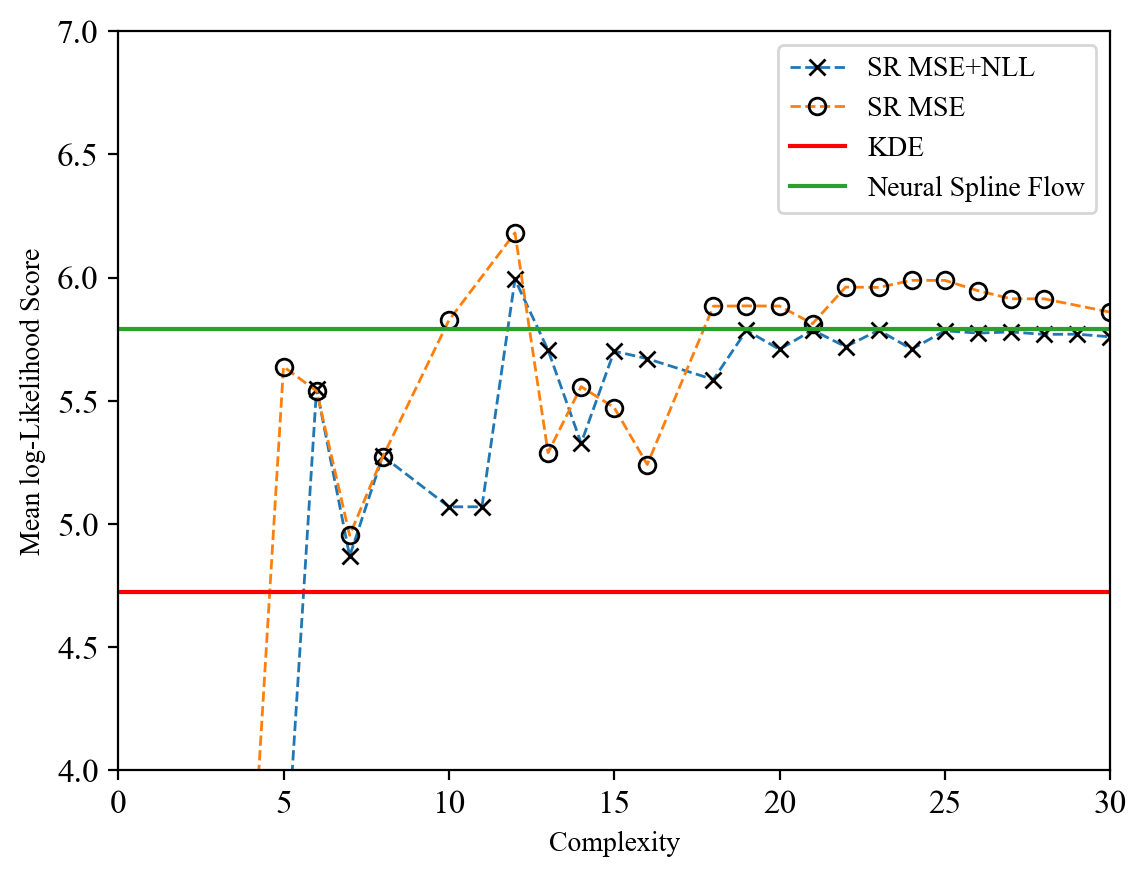

In [ ]:
# With normalization using (integrals not clipped, function not clipped)

kde_eval_at_samples = interp_kde_at_samples(test_samples)
likelihood_score = np.sum(np.log(kde_eval_at_samples+1e-130))/np.shape(test_samples)[0]
print(f"Likelihood score of the corrected KDE: {likelihood_score:,}\n")

log_likelihood_scores_hybrid = []
for idx, func in enumerate(predicted_functions):
    # Compute likelihood scores
    prediction_eval_at_samples = (1/integrals_unclipped[idx])*func(test_samples[:, 0], test_samples[:, 1])
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples[prediction_eval_at_samples>1e-12]/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_hybrid.append(likelihood_score_pred)
    print(f"Function at complexity {complexity_hybrid[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_mse = []
for idx, func in enumerate(predicted_functions_mse):
    # Compute likelihood scores
    prediction_eval_at_samples = (1/integrals_unclipped_mse[idx])*func(test_samples[:, 0], test_samples[:, 1])
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples[prediction_eval_at_samples>1e-12]/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_mse.append(likelihood_score_pred)
    print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")

plt.plot(complexity_hybrid, log_likelihood_scores_hybrid, marker="x", markeredgecolor="black", linestyle="--", linewidth=1, label="SR MSE+NLL")
plt.plot(complexity_mse, log_likelihood_scores_mse, marker="o", markeredgecolor="black", markerfacecolor='none', linestyle="--", linewidth=1, label="SR MSE")
plt.plot([0, max(complexity)], [likelihood_score, likelihood_score], label="KDE", color="red")
plt.plot([0, max(complexity)], [likelihood_score_neural, likelihood_score_neural], label="Neural Spline Flow")
plt.xlabel("Complexity", fontname='Times New Roman')
plt.ylabel("Mean log-Likelihood Score", fontname='Times New Roman')
# plt.title("Mean log-Likelihood Score vs. Complexity")
plt.ylim([4, 7])
plt.xlim([0, 30])
plt.grid(False)
plt.legend()
plt.legend(prop={'family': 'Times New Roman'})  # size optional
plt.xticks(fontname='Times New Roman', fontsize=12)
plt.yticks(fontname='Times New Roman', fontsize=12)
plt.show()

Likelihood score of the corrected KDE: 4.722576214899293

size of test_samples (10000, 2)
Number of bad test samples hybrid: 0
Function at complexity 1: Likelihood score = -0.11721424532362049
Number of bad test samples hybrid: 0
Function at complexity 2: Likelihood score = -0.6750707579245574
Number of bad test samples hybrid: 0
Function at complexity 3: Likelihood score = 3.4427712046656582
Number of bad test samples hybrid: 0
Function at complexity 4: Likelihood score = 3.442771204664491
Number of bad test samples hybrid: 7
Function at complexity 5: Likelihood score = 4.338631618036736
Number of bad test samples hybrid: 0
Function at complexity 6: Likelihood score = 5.519429159330513
Number of bad test samples hybrid: 0
Function at complexity 8: Likelihood score = 5.263827579695394
Number of bad test samples hybrid: 0
Function at complexity 9: Likelihood score = 5.077270968050485
Number of bad test samples hybrid: 0
Function at complexity 10: Likelihood score = 5.056913741875431
Num

<string>:1: RuntimeWarning:

overflow encountered in exp

<string>:1: RuntimeWarning:

overflow encountered in exp

/tmp/ipykernel_1853/691372964.py:1: RuntimeWarning:

overflow encountered in square



Number of bad test samples nphybrid: 0
Number of bad test samples nphybrid: 0
Number of bad test samples nphybrid: 0
Number of bad test samples nphybrid: 0
Number of bad test samples nphybrid: 0
Number of bad test samples nphybrid: 0
Number of bad test samples nphybrid: 0
Number of bad test samples nphybrid: 0
Number of bad test samples nphybrid: 0
Number of bad test samples nphybrid: 0
Number of bad test samples nphybrid: 0
Number of bad test samples nphybrid: 0
Number of bad test samples nphybrid: 0
Number of bad test samples nphybrid: 0
Number of bad test samples nphybrid: 14
Number of bad test samples nphybrid: 8
Number of bad test samples nphybrid: 8
Number of bad test samples pure: 0
Number of bad test samples pure: 0
Number of bad test samples pure: 0
Number of bad test samples pure: 9998
Number of bad test samples pure: 0
Number of bad test samples pure: 10000
Number of bad test samples pure: 10000
Number of bad test samples pure: 0
Number of bad test samples pure: 0
Number of 

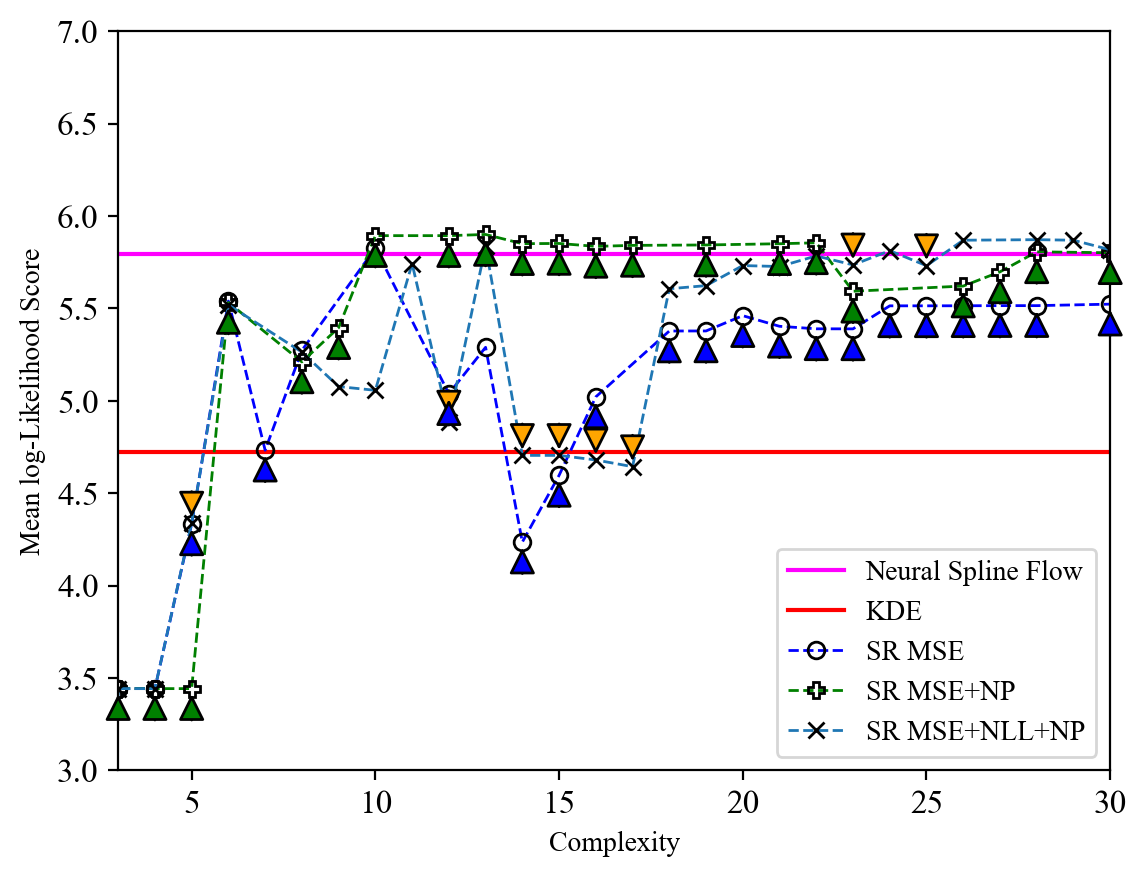

In [198]:
# SOFT HYBRID
# With normalization (integrals clipped, function clipped)

kde_eval_at_samples = interp_kde_at_samples(test_samples)
likelihood_score = np.sum(np.log(kde_eval_at_samples+1e-130))/np.shape(test_samples)[0]
print(f"Likelihood score of the corrected KDE: {likelihood_score:,}\n")

tolerance = 1e-18

print("size of test_samples", np.shape(test_samples))
log_likelihood_scores_hybrid = []
bad_idx_hybrid = []
for idx, func in enumerate(predicted_functions_hybrid):
    # Compute likelihood scores
    bad_evals_flag = any(func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])<=tolerance)
    if bad_evals_flag:
        bad_idx_hybrid.append(idx)

    prediction_eval_at_samples = (1/integrals[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_hybrid.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples hybrid: {num_bad_test_samples}")
    print(f"Function at complexity {complexity_hybrid[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_mse = []
bad_idx_mse = []
for idx, func in enumerate(predicted_functions_mse):
    # Compute likelihood scores
    bad_evals_flag = any(func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])<=tolerance)
    if bad_evals_flag:
        bad_idx_mse.append(idx)
    prediction_eval_at_samples = (1/integrals_mse[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_mse.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples mse: {num_bad_test_samples}")
    # print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_hybridhard = []
bad_idx_hybridhard = []
for idx, func in enumerate(predicted_functions_hybridhard):
    # Compute likelihood scores
    bad_evals_flag = any(func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])<=tolerance)
    if bad_evals_flag:
        bad_idx_hybridhard.append(idx)
    prediction_eval_at_samples = (1/integrals_hybridhard[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_hybridhard.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples hh: {num_bad_test_samples}")
    # print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_nphybrid = []
bad_idx_nphybrid = []
for idx, func in enumerate(predicted_functions_nphybrid):
    # Compute likelihood scores
    bad_evals_flag = np.any(func(grids[0], grids[1])<=tolerance)
    if bad_evals_flag:
        bad_idx_nphybrid.append(idx)
    prediction_eval_at_samples = (1/integrals_nphybrid[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_nphybrid.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples nphybrid: {num_bad_test_samples}")
    # print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_pure = []
bad_idx_pure = []
for idx, func in enumerate(predicted_functions_pure):
    # Compute likelihood scores
    bad_evals_flag = any(func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])<=tolerance)
    if bad_evals_flag:
        bad_idx_pure.append(idx)
    prediction_eval_at_samples = (1/integrals_pure[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_pure.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples pure: {num_bad_test_samples}")
    # print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")
plt.plot([0, max(complexity_mse)], [likelihood_score_neural, likelihood_score_neural], label="Neural Spline Flow", color="magenta")
plt.plot([0, max(complexity_mse)], [likelihood_score, likelihood_score], label="KDE", color="red")
plt.plot(complexity_mse, log_likelihood_scores_mse, marker="o", markeredgecolor="black", markerfacecolor='none', linestyle="--", color="blue", linewidth=1, label="SR MSE")
# plt.plot(complexity_hybridhard, log_likelihood_scores_hybridhard, marker="s", markeredgecolor="black", markerfacecolor='none', linestyle="--", color="orange", linewidth=1, label="SR MSE+NLL+NP")
plt.plot(complexity_nphybrid, log_likelihood_scores_nphybrid, marker="P", markeredgecolor="black", markerfacecolor='none', linestyle="--", color="green", linewidth=1, label="SR MSE+NP")
plt.plot(complexity_hybrid, log_likelihood_scores_hybrid, marker="x", markeredgecolor="black", linestyle="--", linewidth=1, label="SR MSE+NLL+NP")
# plt.plot(complexity_pure, log_likelihood_scores_pure, marker="D", markeredgecolor="black", markerfacecolor='none', linestyle="--", linewidth=1, label="SR Pure")


plt.xlabel("Complexity", fontname='Times New Roman')
plt.ylabel("Mean log-Likelihood Score", fontname='Times New Roman')
# plt.title("Mean log-Likelihood Score vs. Complexity")
plt.ylim([3, 7])
plt.xlim([3, 30])
plt.grid(False)
plt.legend()
plt.legend(prop={'family': 'Times New Roman'})  # size optional
plt.xticks(fontname='Times New Roman', fontsize=12)
plt.yticks(fontname='Times New Roman', fontsize=12)

for idx in bad_idx_hybrid:
    plt.annotate(
        '',              # The annotation text
        xy=(complexity_hybrid[idx], log_likelihood_scores_hybrid[idx]),                 # The data point to annotate
        xytext=(complexity_hybrid[idx], log_likelihood_scores_hybrid[idx]+0.2),             # The position for the text
        arrowprops=dict(
            edgecolor='black',     # Arrow color
            facecolor='orange',     # Arrow color
            arrowstyle='-|>',       # Arrow style (e.g., simple arrow)
            mutation_scale=20,
            lw=1,
            # connectionstyle="arc3,rad=0.2" # Optional: add a slight curve to the arrow
        ),
        ha='center'                # Horizontal alignment of the text
    )

for idx in bad_idx_mse:
    plt.annotate(
        '',              # The annotation text
        xy=(complexity_mse[idx], log_likelihood_scores_mse[idx]),                 # The data point to annotate
        xytext=(complexity_mse[idx], log_likelihood_scores_mse[idx]-0.2),             # The position for the text
        arrowprops=dict(
            edgecolor='black',     # Arrow color
            facecolor='blue',     # Arrow color
            arrowstyle='-|>',       # Arrow style (e.g., simple arrow)
            mutation_scale=20,
            lw=1,
            # connectionstyle="arc3,rad=0.2" # Optional: add a slight curve to the arrow
        ),
        ha='center'                # Horizontal alignment of the text
    )

for idx in bad_idx_nphybrid:
    plt.annotate(
        '',              # The annotation text
        xy=(complexity_nphybrid[idx], log_likelihood_scores_nphybrid[idx]),                 # The data point to annotate
        xytext=(complexity_nphybrid[idx], log_likelihood_scores_nphybrid[idx]-0.2),             # The position for the text
        arrowprops=dict(
            edgecolor='black',     # Arrow color
            facecolor='green',     # Arrow color
            arrowstyle='-|>',       # Arrow style (e.g., simple arrow)
            mutation_scale=20,
            lw=1,
            # connectionstyle="arc3,rad=0.2" # Optional: add a slight curve to the arrow
        ),
        ha='center'                # Horizontal alignment of the text
    )

plt.show()

Likelihood score of the corrected KDE: 4.722576214899293

size of test_samples (10000, 2)
Number of bad test samples hybrid: 0
Function at complexity 1: Likelihood score = -0.11721424532362049
Number of bad test samples hybrid: 0
Function at complexity 2: Likelihood score = -0.6750707579245574
Number of bad test samples hybrid: 0
Function at complexity 3: Likelihood score = 3.4427712046656582
Number of bad test samples hybrid: 0
Function at complexity 4: Likelihood score = 3.442771204664491
Number of bad test samples hybrid: 7
Function at complexity 5: Likelihood score = 4.338631618036736
Number of bad test samples hybrid: 0
Function at complexity 6: Likelihood score = 5.519429159330513
Number of bad test samples hybrid: 0
Function at complexity 8: Likelihood score = 5.263827579695394
Number of bad test samples hybrid: 0
Function at complexity 9: Likelihood score = 5.077270968050485
Number of bad test samples hybrid: 0
Function at complexity 10: Likelihood score = 5.056913741875431
Num

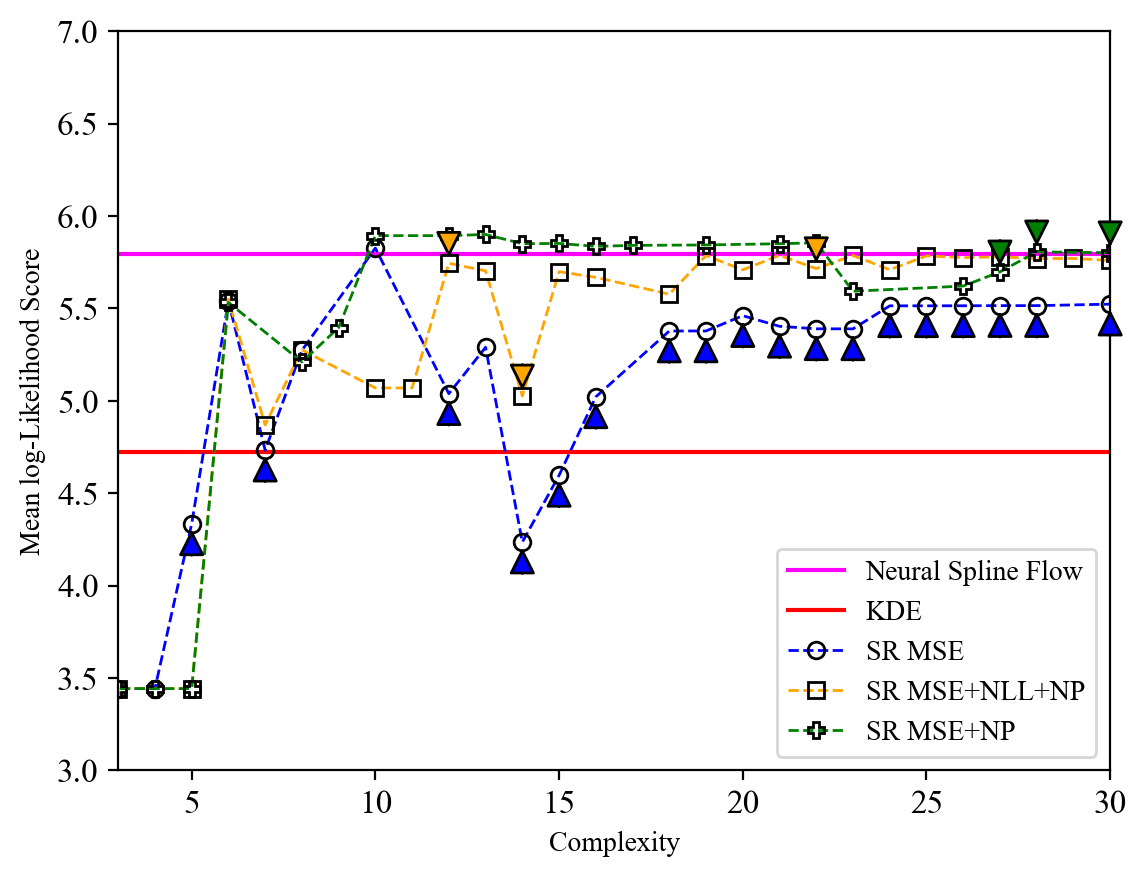

In [60]:
# HARD HYBRID
# With normalization (integrals clipped, function clipped)

kde_eval_at_samples = interp_kde_at_samples(test_samples)
likelihood_score = np.sum(np.log(kde_eval_at_samples+1e-130))/np.shape(test_samples)[0]
print(f"Likelihood score of the corrected KDE: {likelihood_score:,}\n")

tolerance = 1e-18

print("size of test_samples", np.shape(test_samples))
log_likelihood_scores_hybrid = []
bad_idx_hybrid = []
for idx, func in enumerate(predicted_functions_hybrid):
    # Compute likelihood scores
    bad_evals_flag = any(func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])<=tolerance)
    if bad_evals_flag:
        bad_idx_hybrid.append(idx)

    prediction_eval_at_samples = (1/integrals[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_hybrid.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples hybrid: {num_bad_test_samples}")
    print(f"Function at complexity {complexity_hybrid[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_mse = []
bad_idx_mse = []
for idx, func in enumerate(predicted_functions_mse):
    # Compute likelihood scores
    bad_evals_flag = any(func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])<=tolerance)
    if bad_evals_flag:
        bad_idx_mse.append(idx)
    prediction_eval_at_samples = (1/integrals_mse[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_mse.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples mse: {num_bad_test_samples}")
    # print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_hybridhard = []
bad_idx_hybridhard = []
for idx, func in enumerate(predicted_functions_hybridhard):
    # Compute likelihood scores
    bad_evals_flag = any(func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])<=tolerance)
    if bad_evals_flag:
        bad_idx_hybridhard.append(idx)
    prediction_eval_at_samples = (1/integrals_hybridhard[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_hybridhard.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples hh: {num_bad_test_samples}")
    # print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_nphybrid = []
bad_idx_nphybrid = []
for idx, func in enumerate(predicted_functions_nphybrid):
    # Compute likelihood scores
    bad_evals_flag = any(func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])<=tolerance)
    if bad_evals_flag:
        bad_idx_nphybrid.append(idx)
    prediction_eval_at_samples = (1/integrals_nphybrid[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_nphybrid.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples nphybrid: {num_bad_test_samples}")
    # print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_pure = []
bad_idx_pure = []
for idx, func in enumerate(predicted_functions_pure):
    # Compute likelihood scores
    bad_evals_flag = any(func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])<=tolerance)
    if bad_evals_flag:
        bad_idx_pure.append(idx)
    prediction_eval_at_samples = (1/integrals_pure[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_pure.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples pure: {num_bad_test_samples}")
    # print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")
plt.plot([0, max(complexity_mse)], [likelihood_score_neural, likelihood_score_neural], label="Neural Spline Flow", color="magenta")
plt.plot([0, max(complexity_mse)], [likelihood_score, likelihood_score], label="KDE", color="red")
plt.plot(complexity_mse, log_likelihood_scores_mse, marker="o", markeredgecolor="black", markerfacecolor='none', linestyle="--", color="blue", linewidth=1, label="SR MSE")
plt.plot(complexity_hybridhard, log_likelihood_scores_hybridhard, marker="s", markeredgecolor="black", markerfacecolor='none', linestyle="--", color="orange", linewidth=1, label="SR MSE+NLL+NP")
plt.plot(complexity_nphybrid, log_likelihood_scores_nphybrid, marker="P", markeredgecolor="black", markerfacecolor='none', linestyle="--", color="green", linewidth=1, label="SR MSE+NP")
# plt.plot(complexity_hybrid, log_likelihood_scores_hybrid, marker="x", markeredgecolor="black", linestyle="--", linewidth=1, label="SR MSE+NLL+NP")
# plt.plot(complexity_pure, log_likelihood_scores_pure, marker="D", markeredgecolor="black", markerfacecolor='none', linestyle="--", linewidth=1, label="SR Pure")


plt.xlabel("Complexity", fontname='Times New Roman')
plt.ylabel("Mean log-Likelihood Score", fontname='Times New Roman')
# plt.title("Mean log-Likelihood Score vs. Complexity")
plt.ylim([3, 7])
plt.xlim([3, 30])
plt.grid(False)
plt.legend()
plt.legend(prop={'family': 'Times New Roman'})  # size optional
plt.xticks(fontname='Times New Roman', fontsize=12)
plt.yticks(fontname='Times New Roman', fontsize=12)

for idx in bad_idx_hybridhard:
    plt.annotate(
        '',              # The annotation text
        xy=(complexity_hybridhard[idx], log_likelihood_scores_hybridhard[idx]),                 # The data point to annotate
        xytext=(complexity_hybridhard[idx], log_likelihood_scores_hybridhard[idx]+0.2),             # The position for the text
        arrowprops=dict(
            edgecolor='black',     # Arrow color
            facecolor='orange',     # Arrow color
            arrowstyle='-|>',       # Arrow style (e.g., simple arrow)
            mutation_scale=20,
            lw=1,
            # connectionstyle="arc3,rad=0.2" # Optional: add a slight curve to the arrow
        ),
        ha='center'                # Horizontal alignment of the text
    )

for idx in bad_idx_mse:
    plt.annotate(
        '',              # The annotation text
        xy=(complexity_mse[idx], log_likelihood_scores_mse[idx]),                 # The data point to annotate
        xytext=(complexity_mse[idx], log_likelihood_scores_mse[idx]-0.2),             # The position for the text
        arrowprops=dict(
            edgecolor='black',     # Arrow color
            facecolor='blue',     # Arrow color
            arrowstyle='-|>',       # Arrow style (e.g., simple arrow)
            mutation_scale=20,
            lw=1,
            # connectionstyle="arc3,rad=0.2" # Optional: add a slight curve to the arrow
        ),
        ha='center'                # Horizontal alignment of the text
    )

for idx in bad_idx_nphybrid:
    plt.annotate(
        '',              # The annotation text
        xy=(complexity_nphybrid[idx], log_likelihood_scores_nphybrid[idx]),                 # The data point to annotate
        xytext=(complexity_nphybrid[idx], log_likelihood_scores_nphybrid[idx]+0.2),             # The position for the text
        arrowprops=dict(
            edgecolor='black',     # Arrow color
            facecolor='green',     # Arrow color
            arrowstyle='-|>',       # Arrow style (e.g., simple arrow)
            mutation_scale=20,
            lw=1,
            # connectionstyle="arc3,rad=0.2" # Optional: add a slight curve to the arrow
        ),
        ha='center'                # Horizontal alignment of the text
    )

plt.show()

Likelihood score of the corrected KDE: 4.722576214899293

size of test_samples (10000, 2)
Number of bad test samples hybrid: 0
Function at complexity 1: Likelihood score = -0.11721424532362049
Number of bad test samples hybrid: 0
Function at complexity 2: Likelihood score = -0.6750707579245574
Number of bad test samples hybrid: 0
Function at complexity 3: Likelihood score = 3.4427712046656582
Number of bad test samples hybrid: 0
Function at complexity 4: Likelihood score = 3.442771204664491
Number of bad test samples hybrid: 7
Function at complexity 5: Likelihood score = 4.338631618036736
Number of bad test samples hybrid: 0
Function at complexity 6: Likelihood score = 5.519429159330513
Number of bad test samples hybrid: 0
Function at complexity 8: Likelihood score = 5.263827579695394
Number of bad test samples hybrid: 0
Function at complexity 9: Likelihood score = 5.077270968050485
Number of bad test samples hybrid: 0
Function at complexity 10: Likelihood score = 5.056913741875431
Num

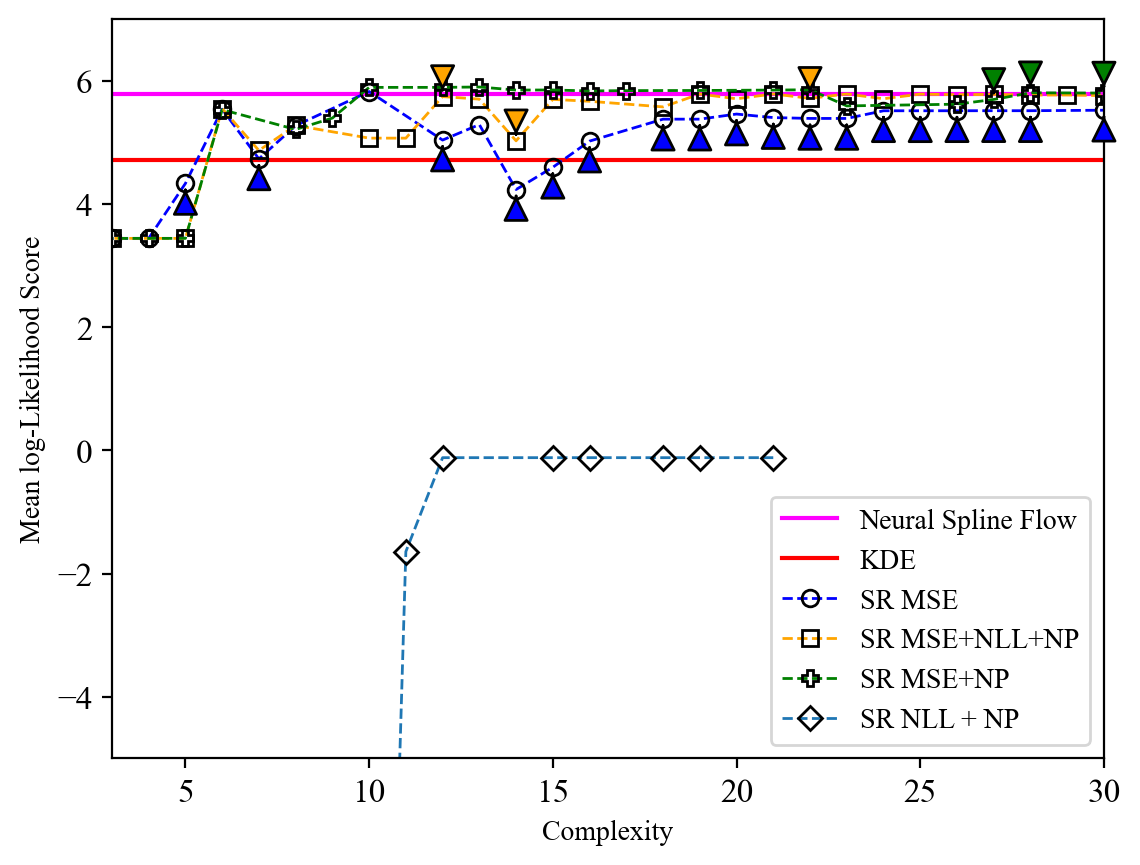

In [76]:
# PURE
# With normalization (integrals clipped, function clipped)

kde_eval_at_samples = interp_kde_at_samples(test_samples)
likelihood_score = np.sum(np.log(kde_eval_at_samples+1e-130))/np.shape(test_samples)[0]
print(f"Likelihood score of the corrected KDE: {likelihood_score:,}\n")

tolerance = 1e-18

print("size of test_samples", np.shape(test_samples))
log_likelihood_scores_hybrid = []
bad_idx_hybrid = []
for idx, func in enumerate(predicted_functions_hybrid):
    # Compute likelihood scores
    bad_evals_flag = any(func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])<=tolerance)
    if bad_evals_flag:
        bad_idx_hybrid.append(idx)

    prediction_eval_at_samples = (1/integrals[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_hybrid.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples hybrid: {num_bad_test_samples}")
    print(f"Function at complexity {complexity_hybrid[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_mse = []
bad_idx_mse = []
for idx, func in enumerate(predicted_functions_mse):
    # Compute likelihood scores
    bad_evals_flag = any(func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])<=tolerance)
    if bad_evals_flag:
        bad_idx_mse.append(idx)
    prediction_eval_at_samples = (1/integrals_mse[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_mse.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples mse: {num_bad_test_samples}")
    # print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_hybridhard = []
bad_idx_hybridhard = []
for idx, func in enumerate(predicted_functions_hybridhard):
    # Compute likelihood scores
    bad_evals_flag = any(func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])<=tolerance)
    if bad_evals_flag:
        bad_idx_hybridhard.append(idx)
    prediction_eval_at_samples = (1/integrals_hybridhard[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_hybridhard.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples hh: {num_bad_test_samples}")
    # print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_nphybrid = []
bad_idx_nphybrid = []
for idx, func in enumerate(predicted_functions_nphybrid):
    # Compute likelihood scores
    bad_evals_flag = any(func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])<=tolerance)
    if bad_evals_flag:
        bad_idx_nphybrid.append(idx)
    prediction_eval_at_samples = (1/integrals_nphybrid[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_nphybrid.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples nphybrid: {num_bad_test_samples}")
    # print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_pure = []
bad_idx_pure = []
for idx, func in enumerate(predicted_functions_pure):
    # Compute likelihood scores
    bad_evals_flag = any(func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])<=tolerance)
    if bad_evals_flag:
        bad_idx_pure.append(idx)
    prediction_eval_at_samples = (1/integrals_pure[idx])*np.max([tolerance*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_pure.append(likelihood_score_pred)
    num_bad_test_samples = np.sum(prediction_eval_at_samples <= tolerance)
    print(f"Number of bad test samples pure: {num_bad_test_samples}")
    # print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")
plt.plot([0, max(complexity_mse)], [likelihood_score_neural, likelihood_score_neural], label="Neural Spline Flow", color="magenta")
plt.plot([0, max(complexity_mse)], [likelihood_score, likelihood_score], label="KDE", color="red")
plt.plot(complexity_mse, log_likelihood_scores_mse, marker="o", markeredgecolor="black", markerfacecolor='none', linestyle="--", color="blue", linewidth=1, label="SR MSE")
plt.plot(complexity_hybridhard, log_likelihood_scores_hybridhard, marker="s", markeredgecolor="black", markerfacecolor='none', linestyle="--", color="orange", linewidth=1, label="SR MSE+NLL+NP")
plt.plot(complexity_nphybrid, log_likelihood_scores_nphybrid, marker="P", markeredgecolor="black", markerfacecolor='none', linestyle="--", color="green", linewidth=1, label="SR MSE+NP")
# plt.plot(complexity_hybrid, log_likelihood_scores_hybrid, marker="x", markeredgecolor="black", linestyle="--", linewidth=1, label="SR MSE+NLL+NP")
plt.plot(complexity_pure, log_likelihood_scores_pure, marker="D", markeredgecolor="black", markerfacecolor='none', linestyle="--", linewidth=1, label="SR NLL + NP")


plt.xlabel("Complexity", fontname='Times New Roman')
plt.ylabel("Mean log-Likelihood Score", fontname='Times New Roman')
# plt.title("Mean log-Likelihood Score vs. Complexity")
plt.ylim([-5, 7])
plt.xlim([3, 30])
plt.grid(False)
plt.legend(loc="lower right")
plt.legend(prop={'family': 'Times New Roman'})  # size optional
plt.xticks(fontname='Times New Roman', fontsize=12)
plt.yticks(fontname='Times New Roman', fontsize=12)

for idx in bad_idx_hybridhard:
    plt.annotate(
        '',              # The annotation text
        xy=(complexity_hybridhard[idx], log_likelihood_scores_hybridhard[idx]),                 # The data point to annotate
        xytext=(complexity_hybridhard[idx], log_likelihood_scores_hybridhard[idx]+0.2),             # The position for the text
        arrowprops=dict(
            edgecolor='black',     # Arrow color
            facecolor='orange',     # Arrow color
            arrowstyle='-|>',       # Arrow style (e.g., simple arrow)
            mutation_scale=20,
            lw=1,
            # connectionstyle="arc3,rad=0.2" # Optional: add a slight curve to the arrow
        ),
        ha='center'                # Horizontal alignment of the text
    )

for idx in bad_idx_mse:
    plt.annotate(
        '',              # The annotation text
        xy=(complexity_mse[idx], log_likelihood_scores_mse[idx]),                 # The data point to annotate
        xytext=(complexity_mse[idx], log_likelihood_scores_mse[idx]-0.2),             # The position for the text
        arrowprops=dict(
            edgecolor='black',     # Arrow color
            facecolor='blue',     # Arrow color
            arrowstyle='-|>',       # Arrow style (e.g., simple arrow)
            mutation_scale=20,
            lw=1,
            # connectionstyle="arc3,rad=0.2" # Optional: add a slight curve to the arrow
        ),
        ha='center'                # Horizontal alignment of the text
    )

for idx in bad_idx_nphybrid:
    plt.annotate(
        '',              # The annotation text
        xy=(complexity_nphybrid[idx], log_likelihood_scores_nphybrid[idx]),                 # The data point to annotate
        xytext=(complexity_nphybrid[idx], log_likelihood_scores_nphybrid[idx]+0.2),             # The position for the text
        arrowprops=dict(
            edgecolor='black',     # Arrow color
            facecolor='green',     # Arrow color
            arrowstyle='-|>',       # Arrow style (e.g., simple arrow)
            mutation_scale=20,
            lw=1,
            # connectionstyle="arc3,rad=0.2" # Optional: add a slight curve to the arrow
        ),
        ha='center'                # Horizontal alignment of the text
    )

plt.show()

In [69]:
log_likelihood_scores_pure

[-4.206479025436635,
 -0.6750707579245574,
 -38.2651946616113,
 -43.93591075124658,
 -22.30084733547767,
 -41.59187046607876,
 -41.9201700700858,
 -1.6422699195330424,
 -0.11721424334634661,
 -0.11721424334634661,
 -0.11721424334634661,
 -0.11721424334634661,
 -0.11721424334634661,
 -0.11721424334634661]

Likelihood score of the corrected KDE: 4.722576214899293

Function at complexity 1: Likelihood score = -0.11721424156554021
Function at complexity 2: Likelihood score = -0.6750707560841326
Function at complexity 3: Likelihood score = 3.442771205119673
Function at complexity 5: Likelihood score = 3.4428311041041053
Function at complexity 6: Likelihood score = 5.549758221456925
Function at complexity 7: Likelihood score = 4.869752215189368
Function at complexity 8: Likelihood score = 5.275767737278568
Function at complexity 10: Likelihood score = 5.0699828904417155
Function at complexity 11: Likelihood score = 5.0699828904417155
Function at complexity 12: Likelihood score = 5.970710124577811
Function at complexity 13: Likelihood score = 5.70328343201022
Function at complexity 14: Likelihood score = 5.328206681497014
Function at complexity 15: Likelihood score = 5.699087055292361
Function at complexity 16: Likelihood score = 5.668372900257115
Function at complexity 18: Likelihood score = 

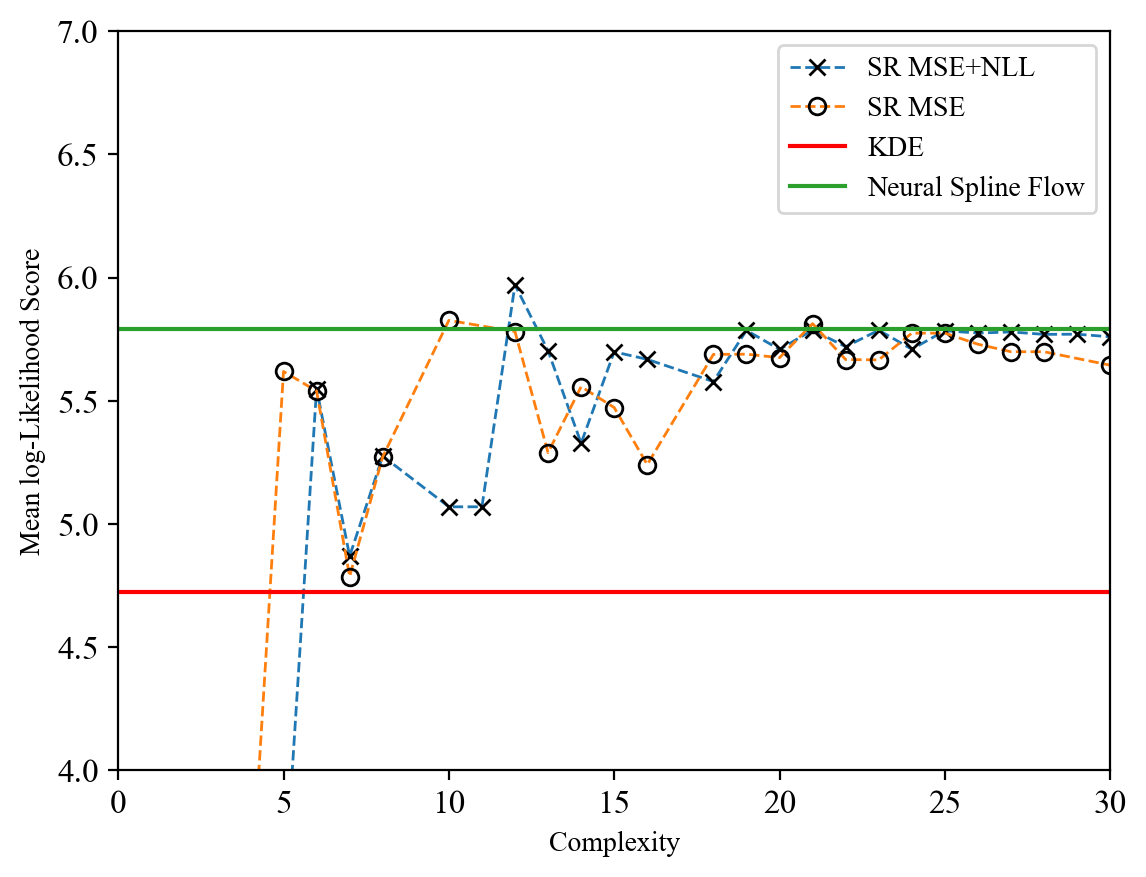

In [ ]:
# With normalization using (integrals not clipped, function clipped)

kde_eval_at_samples = interp_kde_at_samples(test_samples)
likelihood_score = np.sum(np.log(kde_eval_at_samples+1e-130))/np.shape(test_samples)[0]
print(f"Likelihood score of the corrected KDE: {likelihood_score:,}\n")

log_likelihood_scores_hybrid = []
for idx, func in enumerate(predicted_functions):
    # Compute likelihood scores
    prediction_eval_at_samples = (1/integrals_unclipped[idx])*np.max([1e-12*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples[prediction_eval_at_samples>1e-12]/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_hybrid.append(likelihood_score_pred)
    print(f"Function at complexity {complexity_hybrid[idx]}: Likelihood score = {likelihood_score_pred:,}")

log_likelihood_scores_mse = []
for idx, func in enumerate(predicted_functions_mse):
    # Compute likelihood scores
    prediction_eval_at_samples = (1/integrals_unclipped_mse[idx])*np.max([1e-12*np.ones_like(test_samples[:, 0]), func(test_samples[:, 0], test_samples[:, 1])*np.ones_like(test_samples[:, 0])], axis=0)
    if np.shape(prediction_eval_at_samples)==():
        prediction_eval_at_samples = prediction_eval_at_samples*np.ones_like(test_samples[:, 0])
    likelihood_score_pred = np.sum(np.log(prediction_eval_at_samples[prediction_eval_at_samples>1e-12]/density_scale_factor))/np.shape(test_samples)[0]
    log_likelihood_scores_mse.append(likelihood_score_pred)
    print(f"Function at complexity {complexity_mse[idx]}: Likelihood score = {likelihood_score_pred:,}")

plt.plot(complexity_hybrid, log_likelihood_scores_hybrid, marker="x", markeredgecolor="black", linestyle="--", linewidth=1, label="SR MSE+NLL")
plt.plot(complexity_mse, log_likelihood_scores_mse, marker="o", markeredgecolor="black", markerfacecolor='none', linestyle="--", linewidth=1, label="SR MSE")
plt.plot([0, max(complexity)], [likelihood_score, likelihood_score], label="KDE", color="red")
plt.plot([0, max(complexity)], [likelihood_score_neural, likelihood_score_neural], label="Neural Spline Flow")
plt.xlabel("Complexity", fontname='Times New Roman')
plt.ylabel("Mean log-Likelihood Score", fontname='Times New Roman')
# plt.title("Mean log-Likelihood Score vs. Complexity")
plt.ylim([4, 7])
plt.xlim([0, 30])
plt.grid(False)
plt.legend()
plt.legend(prop={'family': 'Times New Roman'})  # size optional
plt.xticks(fontname='Times New Roman', fontsize=12)
plt.yticks(fontname='Times New Roman', fontsize=12)
plt.show()